# Joint Headline HICP BVAR

Dense BVAR(12) for Energy, Food, NEIG and Services in monthly Δlog HICP, with 11 monthly dummies (December reference), stochastic volatility and outliers.

`hicp_food` is pulled directly from the official Eurostat HICP API using the published `FOOD` special aggregate (`prc_hicp_minr`, `M.I25.FOOD.EA`). It is not reconstructed from processed and unprocessed food.


This version also contains a notebook-local validation of Eurostat Core HICP (`TOT_X_NRG_FOOD`) reconstructed from NEIG + Services before any production refactor.


## 1. Imports and configuration

In [2]:
1+1


2

In [3]:
from __future__ import annotations

import os
import sys
from io import StringIO
from dataclasses import asdict
from pathlib import Path
from typing import Mapping, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import requests
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/ and src/.")


env_root = os.environ.get("BVAR_PROJECT_ROOT")
PROJECT_ROOT = (
    Path(env_root).expanduser().resolve()
    if env_root
    else find_project_root(Path.cwd())
)

MODEL_DIR = PROJECT_ROOT / "src" / "model"
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

from headline_joint_bvar import (
    BASELINE_P,
    SENSITIVITY_P,
    MODEL_ID,
    NATIVE_VARIABLES,
    STATE_VARIABLES,
    STATE_VARIABLE_MAP,
    BVARSVOPriorConfig,
    SamplerConfig,
    aggregate_headline_draws,
    headline_component_forecast_table,
    headline_forecast_table,
    headline_joint_panel_audit,
    headline_joint_spec,
    headline_reconstruction_diagnostics,
    lag_comparison_table,
    load_headline_joint_panel,
    load_headline_joint_weights,
    load_official_headline_total,
    native_to_state_levels,
    state_paths_to_native,
    resolve_headline_reconstruction_start_year,
    reconstruct_headline_history,
    resolve_headline_joint_dataset,
    resolve_headline_joint_weights,
    resolve_headline_official_indices,
)

from headline_joint_plot import (
    plot_headline_aggregate_forecast,
    plot_headline_historical_reconstruction,
    plot_joint_component_forecast_fans,
    plot_joint_model_changes,
    plot_joint_native_levels,
)

from energy_bvar_model import (
    coefficient_posterior_table,
    forecast_bvar_sv_outlier,
    forecast_error_variance_decomposition,
    historical_decomposition,
    impulse_responses,
    mcmc_diagnostics,
    monthly_seasonal_dummies,
    posterior_predictive_statistics,
    residual_diagnostic_table,
    run_energy_bvar,
    stability_diagnostics,
    stationarity_tests,
)

from energy_bvar_plot import (
    plot_chain_acf_grid,
    plot_coefficient_heatmap,
    plot_outlier_probabilities,
    plot_phi_and_outlier_priors,
    plot_posterior_predictive_check,
    plot_posterior_volatility,
    plot_spectral_radius,
    plot_standardized_residuals,
    plot_trace_grid,
    style_numeric_table,
)

try:
    from energy_bvar_io import save_energy_bvar_result
except ImportError:
    save_energy_bvar_result = None


SPEC = headline_joint_spec()

DATA_ROOT = None
VINTAGE = None

# Direct official Eurostat source for the Food special aggregate.
EUROSTAT_SDMX_API = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data"
EUROSTAT_FOOD_DATASET = "prc_hicp_minr"
EUROSTAT_FOOD_KEY = "M.I25.FOOD.EA"
EUROSTAT_FOOD_CODE = "FOOD"
EUROSTAT_FOOD_UNIT = "I25"
EUROSTAT_FOOD_GEO = "EA"

# Official Core HICP validation series.
# Use the Statistics API here rather than a positional SDMX key: filters are
# named, so the request does not depend on an assumed dimension order.
EUROSTAT_STATS_API = "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data"
EUROSTAT_CORE_DATASET = "prc_hicp_minr"
EUROSTAT_CORE_CODE = "TOT_X_NRG_FOOD"
EUROSTAT_CORE_UNIT = "I25"
EUROSTAT_CORE_GEO = "EA"
CORE_COMPONENTS = ("hicp_neig", "hicp_services")

QUICK_TEST = False
FORECAST_HORIZON = 18
FORECAST_DRAWS = 250 if QUICK_TEST else 1_000
SAVE_RESULTS = False

# Canonical deterministic seasonality contract.
SEASONAL_REFERENCE_MONTH = 12
SEASONAL_PREFIX = "month"
SEASONAL_EXOG_PRIOR_SCALE = 10.0

# Structural analysis is recursive/Cholesky and therefore ordering-dependent.
RUN_STRUCTURAL_ANALYSIS = True
STRUCTURAL_HORIZON = 24
STRUCTURAL_DRAWS = 150 if QUICK_TEST else 1_000
HD_LAST_OBS = 120

# The only lag sensitivity allowed in the current methodology is BVAR(6) vs BVAR(12).
RUN_BVAR6_SENSITIVITY = False

# Diagnostic-only checks; they do not alter the canonical BVAR.
SEASONAL_ROOT_DIAGNOSTIC_DRAWS = 300 if QUICK_TEST else 1_000
SEASONAL_ROOT_ANGLE_TOLERANCE = np.pi / 24.0
SEASONAL_ROOT_MODULUS_THRESHOLDS = (0.90, 0.95, 0.97)
SEASONAL_BREAK_DATES = (pd.Timestamp("2015-01-01"), pd.Timestamp("2020-01-01"))

PRIOR_CONFIG = BVARSVOPriorConfig(
    lambda1=0.20,
    lambda2=0.50,
    lambda3=1.00,
    lambda4=10.0,
    a_prior_var=10.0,
    phi_prior_mean=0.02,
    phi_prior_df=10.0,
    h0_var=4.0,
    outlier_mean_frequency=1.0 / 48.0,
    outlier_prior_observations=120.0,
    outlier_grid_min=2.0,
    outlier_grid_max=20.0,
    outlier_grid_step=1.0,
    ksc_offset_scale=1e-6,
)

SAMPLER_CONFIG = SamplerConfig(
    reps=300 if QUICK_TEST else 6_000,
    burn=150 if QUICK_TEST else 3_000,
    thin=1,
    seed=42,
    max_stability_tries=1_000,
    progress_every=0 if QUICK_TEST else 500,
)


def make_joint_seasonals(index: Sequence[pd.Timestamp]) -> pd.DataFrame:
    """Eleven monthly dummies; December is the omitted reference category."""
    return monthly_seasonal_dummies(
        index,
        reference_month=SEASONAL_REFERENCE_MONTH,
        prefix=SEASONAL_PREFIX,
    )


def _native_conditions_to_state(
    conditions: Mapping[str, float | Sequence[float]] | None,
) -> dict[str, float | np.ndarray] | None:
    if conditions is None:
        return None
    output: dict[str, float | np.ndarray] = {}
    for native_name, values in conditions.items():
        if native_name not in STATE_VARIABLE_MAP:
            raise KeyError(
                f"Unknown native condition variable {native_name!r}; choose from {NATIVE_VARIABLES}."
            )
        arr = np.asarray(values, dtype=float)
        if not np.all(np.isfinite(arr)):
            raise ValueError(f"{native_name}: native conditions must be finite.")
        if np.any(arr <= 0):
            raise ValueError(f"{native_name}: HICP level conditions must be positive.")
        transformed = np.log(arr)
        output[STATE_VARIABLE_MAP[native_name]] = (
            float(transformed) if transformed.ndim == 0 else transformed
        )
    return output


def _component_yoy_paths(
    native_paths: np.ndarray,
    path_dates: pd.DatetimeIndex,
    native_history: pd.DataFrame,
) -> np.ndarray:
    """Compute component YoY paths draw-by-draw using observed pre-path history."""
    draws, _, _ = native_paths.shape
    output = np.full_like(native_paths, np.nan, dtype=float)
    pos = {pd.Timestamp(date): i for i, date in enumerate(path_dates)}
    history = native_history[NATIVE_VARIABLES].copy().sort_index()
    history.index = pd.DatetimeIndex(history.index).to_period("M").to_timestamp(how="start")

    for t, date in enumerate(path_dates):
        lag_date = pd.Timestamp(date) - pd.DateOffset(months=12)
        for j, name in enumerate(NATIVE_VARIABLES):
            if lag_date in pos:
                denominator = native_paths[:, pos[lag_date], j]
            else:
                if lag_date not in history.index or pd.isna(history.loc[lag_date, name]):
                    continue
                denominator = np.full(draws, float(history.loc[lag_date, name]), dtype=float)
            output[:, t, j] = 100.0 * (native_paths[:, t, j] / denominator - 1.0)
    return output


def run_headline_joint_bvar(
    native_levels: pd.DataFrame,
    *,
    vintage: str,
    p: int = BASELINE_P,
    prior_config: BVARSVOPriorConfig | None = None,
    sampler_config: SamplerConfig | None = None,
    code_version: str = "headline-joint-seasonal-eurostat-food-v1",
) -> dict:
    """Notebook production wrapper: dense joint BVAR + 11 monthly dummies."""
    if int(p) not in (SENSITIVITY_P, BASELINE_P):
        raise ValueError(f"Headline joint policy allows only p={SENSITIVITY_P} or p={BASELINE_P}.")
    state = native_to_state_levels(native_levels)
    seasonals = make_joint_seasonals(state.index)
    prior_config = BVARSVOPriorConfig() if prior_config is None else prior_config
    sampler_config = SamplerConfig() if sampler_config is None else sampler_config

    result = run_energy_bvar(
        levels=state,
        model_id=MODEL_ID,
        vintage=str(vintage),
        p=int(p),
        variables=STATE_VARIABLES,
        frequency="monthly",
        exog=seasonals,
        exog_prior_scale=SEASONAL_EXOG_PRIOR_SCALE,
        prior_config=prior_config,
        sampler_config=sampler_config,
        code_version=code_version,
    )
    result["headline_joint_context"] = {
        "native_variables": list(NATIVE_VARIABLES),
        "state_variables": list(STATE_VARIABLES),
        "state_variable_map": dict(STATE_VARIABLE_MAP),
        "native_levels": native_levels[NATIVE_VARIABLES].copy(),
        "seasonal_reference_month": SEASONAL_REFERENCE_MONTH,
    }
    result["metadata"].update(
        {
            "suite": "headline",
            "component": "headline_joint",
            "model_class": f"dense BVAR({int(p)}) + monthly seasonal dummies",
            "native_variables": list(NATIVE_VARIABLES),
            "state_variables": list(STATE_VARIABLES),
            "state_variable_map": dict(STATE_VARIABLE_MAP),
            "transform_map": {name: "logdiff" for name in NATIVE_VARIABLES},
            "active_lags": None,
            "seasonal_dummies": True,
            "seasonal_reference_month": int(SEASONAL_REFERENCE_MONTH),
            "seasonal_exog_names": list(seasonals.columns),
            "lag_policy": "canonical dense BVAR(12); only sensitivity is dense BVAR(6)",
            "headline_joint_notebook_version": "2026-08-12-eurostat-food-v1",
        }
    )
    return result


def forecast_headline_joint_bvar(
    result: Mapping,
    *,
    native_levels: pd.DataFrame | None = None,
    H: int = 18,
    native_level_conditions: Mapping[str, float | Sequence[float]] | None = None,
    n_draws: int | None = None,
    simulate_future_outliers: bool = True,
    seed: int = 123,
) -> dict[str, object]:
    """Forecast wrapper that extends the fitted monthly dummy design into the future."""
    if native_levels is None:
        native_levels = result.get("headline_joint_context", {}).get("native_levels")
    if not isinstance(native_levels, pd.DataFrame):
        raise ValueError("native_levels is required for the Headline forecast wrapper.")

    last_date = pd.Timestamp(result["prep"]["last_calendar_date"])
    future_dates = pd.date_range(
        last_date + pd.offsets.MonthBegin(1),
        periods=int(H),
        freq="MS",
        name="date",
    )
    future_exog = make_joint_seasonals(future_dates)
    fitted_names = list(result["prep"].get("exog_names", []))
    if list(future_exog.columns) != fitted_names:
        raise ValueError(
            "Future monthly-dummy columns do not match the fitted exogenous contract: "
            f"future={list(future_exog.columns)}, fitted={fitted_names}."
        )

    state_forecast = forecast_bvar_sv_outlier(
        result,
        H=int(H),
        level_conditions=_native_conditions_to_state(native_level_conditions),
        future_exog=future_exog,
        n_draws=n_draws,
        simulate_future_outliers=bool(simulate_future_outliers),
        seed=int(seed),
    )
    if list(state_forecast["variables"]) != STATE_VARIABLES:
        raise ValueError(
            f"State-variable ordering changed: expected {STATE_VARIABLES}, "
            f"found {state_forecast['variables']}."
        )

    native_paths = state_paths_to_native(state_forecast["level_paths"])
    path_dates = pd.DatetimeIndex(state_forecast["path_dates"], name="date")
    component_yoy = _component_yoy_paths(native_paths, path_dates, native_levels)
    tail = int(state_forecast["tail_length"])

    output = dict(state_forecast)
    output.update(
        {
            "component": MODEL_ID,
            "component_label": "Headline components joint BVAR",
            "native_variables": list(NATIVE_VARIABLES),
            "state_variables": list(STATE_VARIABLES),
            "native_level_paths": native_paths,
            "future_native_level_paths": native_paths[:, tail:],
            "component_yoy_paths": component_yoy,
            "future_component_yoy_paths": component_yoy[:, tail:],
            "native_level_conditions": (
                None if native_level_conditions is None else dict(native_level_conditions)
            ),
            "future_seasonal_exog": future_exog,
            "forecast_contract_version": "headline_joint_seasonal_v1",
        }
    )
    return output


def posterior_draw_subset(result: Mapping, n_draws: int | None) -> dict:
    """Deterministically thin posterior arrays for expensive structural diagnostics only."""
    total = int(result["n_draws"])
    if n_draws is None or int(n_draws) >= total:
        return dict(result)
    keep = int(n_draws)
    if keep < 1:
        raise ValueError("n_draws must be positive.")
    idx = np.linspace(0, total - 1, keep, dtype=int)
    out = dict(result)
    draw_keys = [
        "B", "A", "log_variance", "phi", "outlier_scales",
        "outlier_indicators", "outlier_probabilities",
        "posterior_outlier_probability_draws", "spectral_radius",
        "log_likelihood", "completed_differences_draws",
        "missing_level_draws", "last_companion_state_draws",
    ]
    for key in draw_keys:
        if key in result:
            arr = np.asarray(result[key])
            if arr.ndim >= 1 and arr.shape[0] == total:
                out[key] = arr[idx]
    out["n_draws"] = len(idx)
    out["structural_draw_indices_from_full_posterior"] = idx
    return out


SPEC.update(
    {
        "seasonal_dummies": True,
        "seasonal_reference_month": SEASONAL_REFERENCE_MONTH,
        "seasonal_exog_prior_scale": SEASONAL_EXOG_PRIOR_SCALE,
        "hicp_food_source": {
            "provider": "Eurostat",
            "dataset": EUROSTAT_FOOD_DATASET,
            "key": EUROSTAT_FOOD_KEY,
            "code": EUROSTAT_FOOD_CODE,
            "unit": EUROSTAT_FOOD_UNIT,
            "geo": EUROSTAT_FOOD_GEO,
        },
        "hicp_core_validation_source": {
            "provider": "Eurostat",
            "api": "statistics/1.0",
            "dataset": EUROSTAT_CORE_DATASET,
            "code": EUROSTAT_CORE_CODE,
            "unit": EUROSTAT_CORE_UNIT,
            "geo": EUROSTAT_CORE_GEO,
            "components": list(CORE_COMPONENTS),
        },
    }
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Canonical model:", f"dense BVAR({BASELINE_P}) + 11 monthly dummies")
print("Only lag sensitivity:", f"dense BVAR({SENSITIVITY_P}) + same dummies")
print("Seasonal reference month:", SEASONAL_REFERENCE_MONTH, "(December)")
print("Variable ordering:", NATIVE_VARIABLES)


PROJECT_ROOT: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy
Canonical model: dense BVAR(12) + 11 monthly dummies
Only lag sensitivity: dense BVAR(6) + same dummies
Seasonal reference month: 12 (December)
Variable ordering: ['hicp_energy', 'hicp_food', 'hicp_neig', 'hicp_services']


### Variable ordering

Energy → Food → NEIG → Services. This order is also used by the recursive structural analysis.


## 2. Resolve the official processed vintage

In [4]:
DATASET_PATH = resolve_headline_joint_dataset(
    PROJECT_ROOT,
    vintage=VINTAGE,
    data_root=DATA_ROOT,
)
VINTAGE_USED = DATASET_PATH.parent.name

WEIGHTS_PATH = resolve_headline_joint_weights(
    PROJECT_ROOT,
    vintage=VINTAGE_USED,
    data_root=DATA_ROOT,
)
OFFICIAL_INDICES_PATH = resolve_headline_official_indices(
    PROJECT_ROOT,
    vintage=VINTAGE_USED,
    data_root=DATA_ROOT,
)

print("Vintage:", VINTAGE_USED)
print("Joint dataset:", DATASET_PATH)
print("Annual weights:", WEIGHTS_PATH)
print("Official total/reference indices:", OFFICIAL_INDICES_PATH)

Vintage: 20260812
Joint dataset: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260812\headline_joint_monthly.csv
Annual weights: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260812\headline_joint_weights_annual.csv
Official total/reference indices: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260812\headline_hicp_indices_monthly.csv


## 3. Load HICP inputs and replace Food with the Eurostat API

Energy, NEIG and Services remain those of the processed vintage. `hicp_food` is overwritten with Eurostat's published **Food, alcohol and tobacco** special aggregate (`FOOD`, 2025=100, euro area).

The model therefore uses the official aggregate directly; there is no `FOOD_NP + FOOD_P` index reconstruction. Annual Food weights remain the official Eurostat weights already stored in the processed vintage.


In [5]:
def load_eurostat_food_index(start_period: str) -> tuple[pd.Series, dict[str, object]]:
    """Download the official euro-area HICP Food special aggregate from Eurostat."""
    url = f"{EUROSTAT_SDMX_API}/{EUROSTAT_FOOD_DATASET}/{EUROSTAT_FOOD_KEY}"
    response = requests.get(
        url,
        params={
            "format": "SDMX-CSV",
            "startPeriod": str(start_period),
        },
        timeout=90,
    )
    response.raise_for_status()

    raw = pd.read_csv(StringIO(response.text))
    raw.columns = [str(column).strip().lower() for column in raw.columns]

    required = {"time_period", "obs_value"}
    missing = required.difference(raw.columns)
    if missing:
        raise RuntimeError(
            f"Eurostat Food response is missing columns {sorted(missing)}; "
            f"found {list(raw.columns)}."
        )

    expected_dimensions = {
        "freq": "M",
        "unit": EUROSTAT_FOOD_UNIT,
        "coicop18": EUROSTAT_FOOD_CODE,
        "geo": EUROSTAT_FOOD_GEO,
    }
    for column, expected in expected_dimensions.items():
        if column not in raw.columns:
            continue
        observed = set(raw[column].dropna().astype(str).str.strip())
        if observed != {expected}:
            raise RuntimeError(
                f"Eurostat Food response: expected {column}={expected!r}, "
                f"found {sorted(observed)}."
            )

    raw["date"] = (
        pd.PeriodIndex(raw["time_period"].astype(str), freq="M")
        .to_timestamp(how="start")
    )
    raw["obs_value"] = pd.to_numeric(raw["obs_value"], errors="coerce")

    data = (
        raw[["date", "obs_value"]]
        .dropna(subset=["date", "obs_value"])
        .sort_values("date")
    )

    if data["date"].duplicated().any():
        duplicates = data.loc[data["date"].duplicated(keep=False), "date"]
        raise RuntimeError(
            "Eurostat Food response contains duplicate months: "
            + ", ".join(pd.DatetimeIndex(duplicates).strftime("%Y-%m"))
        )

    food = (
        data.set_index("date")["obs_value"]
        .astype(float)
        .rename("hicp_food")
    )
    food.index = pd.DatetimeIndex(food.index, name="date")

    if food.empty:
        raise RuntimeError("Eurostat Food API returned no usable observations.")
    if (food <= 0).any():
        first_bad = food.index[(food <= 0)][0]
        raise RuntimeError(
            f"Eurostat Food index must be positive; first invalid month is "
            f"{pd.Timestamp(first_bad).date()}."
        )

    metadata = {
        "provider": "Eurostat",
        "dataset": EUROSTAT_FOOD_DATASET,
        "key": EUROSTAT_FOOD_KEY,
        "code": EUROSTAT_FOOD_CODE,
        "label": "Food, alcohol and tobacco",
        "unit": EUROSTAT_FOOD_UNIT,
        "geo": EUROSTAT_FOOD_GEO,
        "request_url": response.url,
        "retrieved_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
        "first_date": food.index.min().date().isoformat(),
        "last_date": food.index.max().date().isoformat(),
        "n_observations": int(food.notna().sum()),
    }
    return food, metadata


# Load the processed vintage first: this fixes the model calendar and the
# non-Food component inputs.
native_levels_processed = load_headline_joint_panel(DATASET_PATH)
native_levels = native_levels_processed.copy()

api_start = (
    pd.Timestamp(native_levels.index.min()) - pd.DateOffset(months=1)
).strftime("%Y-%m")

eurostat_food, FOOD_SOURCE_METADATA = load_eurostat_food_index(api_start)

# Eurostat FOOD starts in 1996 whereas the legacy processed panel starts in 1995.
# Because Food is now required to come exclusively from Eurostat, the joint model
# sample is trimmed to the first common month rather than backfilled with Haver.
food_first = pd.Timestamp(eurostat_food.first_valid_index())
model_start = max(pd.Timestamp(native_levels_processed.index.min()), food_first)

native_levels = native_levels_processed.loc[model_start:].copy()
food_on_model_calendar = eurostat_food.reindex(native_levels.index)
observed_food = food_on_model_calendar.dropna()

if observed_food.empty:
    raise RuntimeError("Eurostat Food has no overlap with the model calendar.")

if observed_food.index.min() != native_levels.index.min():
    raise RuntimeError(
        "Unexpected leading gap after common-sample trimming: "
        f"model starts {native_levels.index.min().date()}, "
        f"Food starts {observed_food.index.min().date()}."
    )

food_interior = food_on_model_calendar.loc[
    observed_food.index.min():observed_food.index.max()
]
if food_interior.isna().any():
    first_missing = food_interior.index[food_interior.isna()][0]
    raise RuntimeError(
        f"Eurostat Food has an interior missing observation at "
        f"{pd.Timestamp(first_missing).date()}."
    )

native_levels["hicp_food"] = food_on_model_calendar

weights = load_headline_joint_weights(WEIGHTS_PATH)
official_total = load_official_headline_total(OFFICIAL_INDICES_PATH)

print(
    "Food source:",
    f"Eurostat {EUROSTAT_FOOD_DATASET} / {EUROSTAT_FOOD_KEY}",
)
print(
    "Joint model sample starts:",
    native_levels.index.min().date(),
    "(trimmed to first Eurostat Food observation)",
)
print(
    "Eurostat Food coverage:",
    FOOD_SOURCE_METADATA["first_date"],
    "->",
    FOOD_SOURCE_METADATA["last_date"],
)
print(
    "Trailing Food NaNs on model calendar:",
    int(
        food_on_model_calendar.loc[
            observed_food.index.max():
        ].isna().sum()
    ),
)

display(headline_joint_panel_audit(native_levels))

complete_weights = weights.dropna(how="any")
weight_check = pd.DataFrame(
    {
        "component_sum": complete_weights.sum(axis=1),
        "sum_minus_1000": complete_weights.sum(axis=1) - 1000.0,
    }
)
display(weight_check.tail(10))

food_source_check = pd.concat(
    [
        native_levels_processed["hicp_food"].rename("previous_processed_food"),
        native_levels["hicp_food"].rename("eurostat_food"),
    ],
    axis=1,
)
display(food_source_check.tail(18))


Food source: Eurostat prc_hicp_minr / M.I25.FOOD.EA
Joint model sample starts: 1999-12-01 (trimmed to first Eurostat Food observation)
Eurostat Food coverage: 1999-11-01 -> 2026-07-01
Trailing Food NaNs on model calendar: 0


,first_observed,last_observed,observations,leading_missing,interior_missing,trailing_missing,min,max
series,,,,,,,,
hicp_energy,1999-12-01,2026-07-01,320,0,0,0,39.75,117.62
hicp_food,1999-12-01,2026-07-01,320,0,0,0,48.61,102.12
hicp_neig,1999-12-01,2026-07-01,320,0,0,0,78.22,101.78
hicp_services,1999-12-01,2026-07-01,320,0,0,0,57.68,104.81


,component_sum,sum_minus_1000
year,,
2017,1000.00,0.00
2018,1000.00,0.00
2019,1000.01,0.01
2020,999.99,-0.01
2021,1000.00,0.00
2022,1000.00,0.00
2023,1000.00,0.00
2024,1000.01,0.01
2025,1000.00,0.00


,previous_processed_food,eurostat_food
date,,
2025-02-01,99.09,99.09
2025-03-01,99.38,99.38
2025-04-01,99.71,99.71
2025-05-01,100.12,100.12
2025-06-01,100.18,100.18
2025-07-01,100.38,100.38
2025-08-01,100.41,100.41
2025-09-01,100.35,100.35
2025-10-01,100.51,100.51


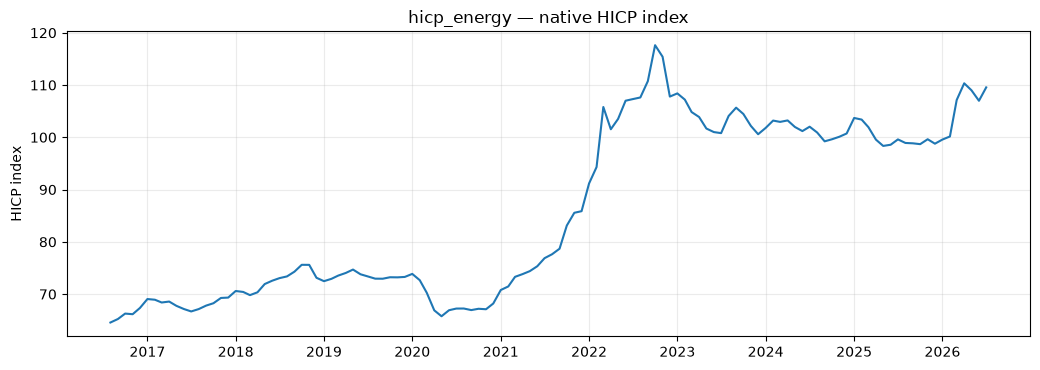

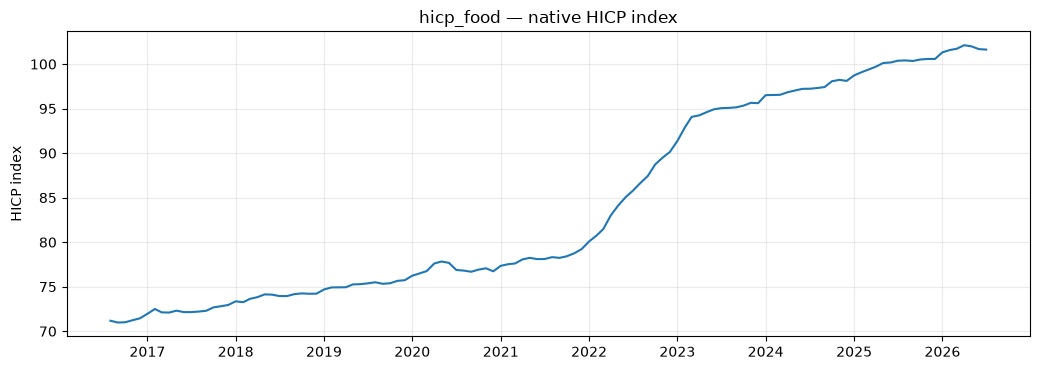

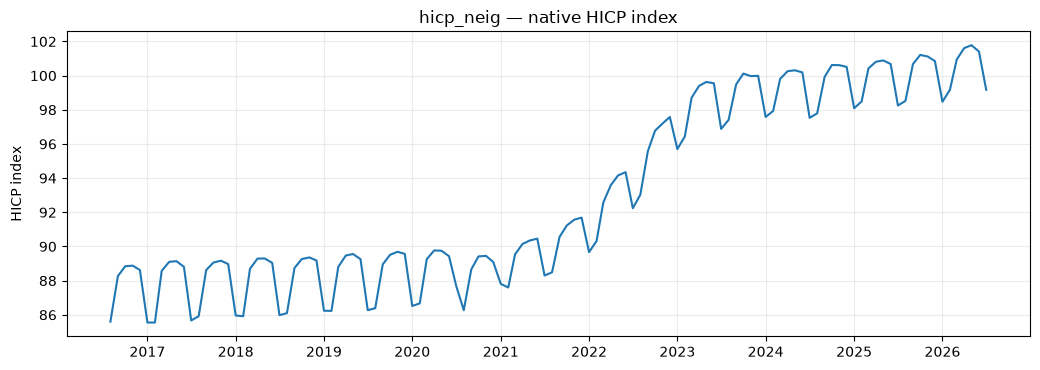

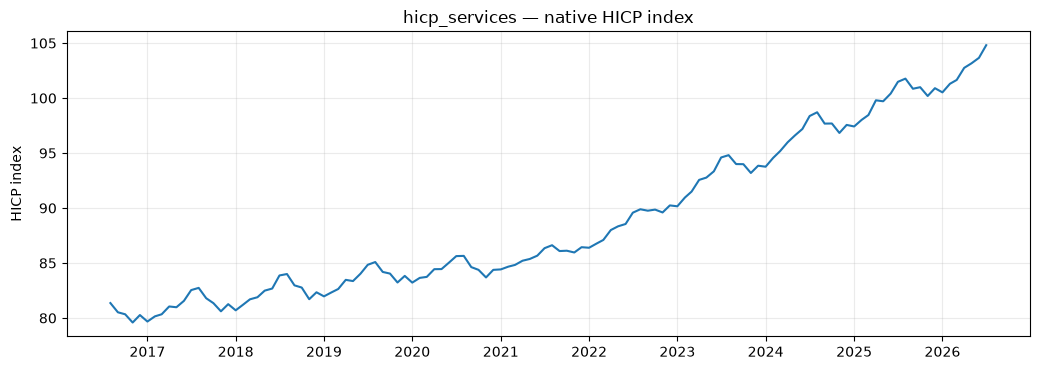

In [6]:
figures = plot_joint_native_levels(native_levels, last_obs=120)
for fig in figures.values():
    display(fig)
    plt.close(fig)

## 4. Common model-space transformation and deterministic seasonality


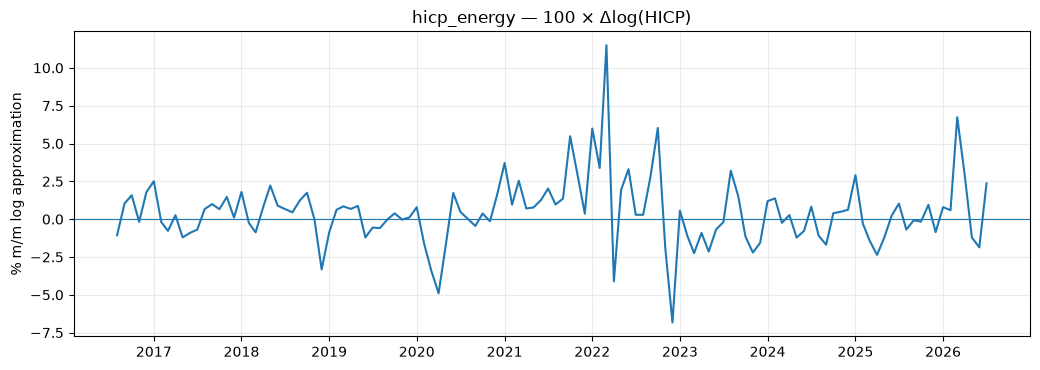

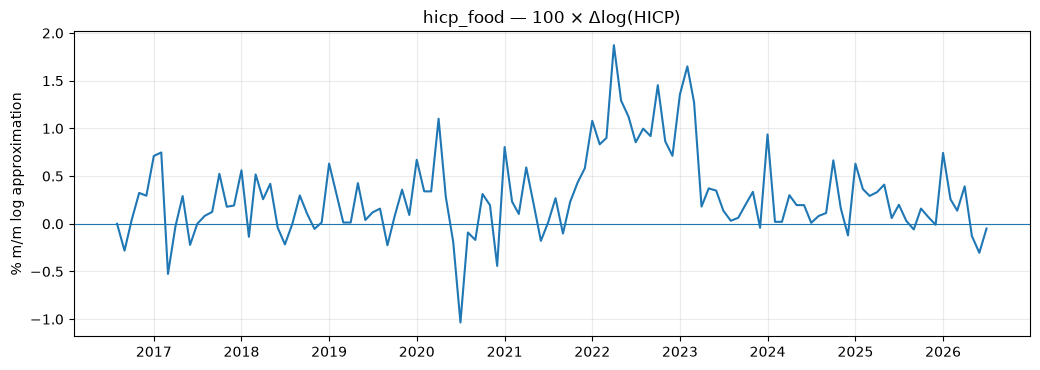

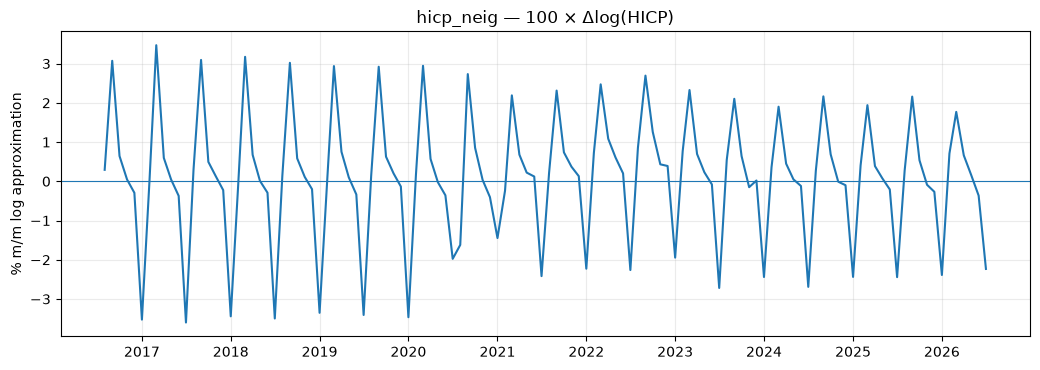

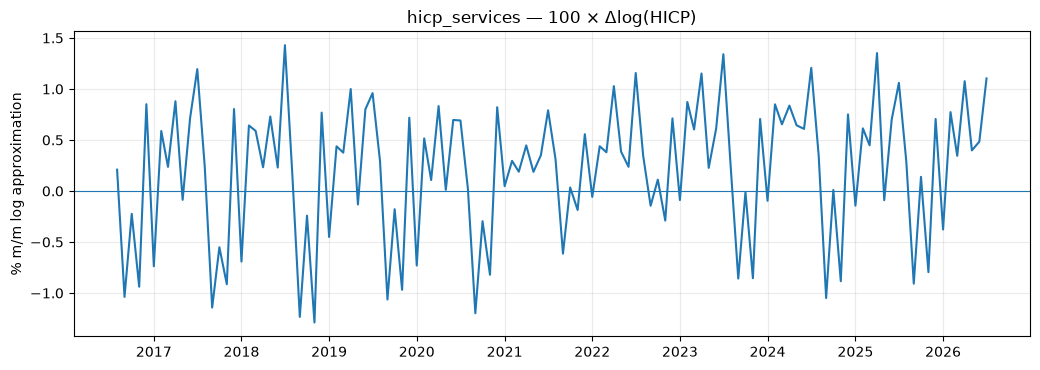

State variables: ['state__hicp_energy', 'state__hicp_food', 'state__hicp_neig', 'state__hicp_services']
Seasonal regressors: ['month_01', 'month_02', 'month_03', 'month_04', 'month_05', 'month_06', 'month_07', 'month_08', 'month_09', 'month_10', 'month_11']
Reference month: December
Dummy matrix shape: (320, 11)


,month_01,month_02,month_03,month_04,month_05,month_06,month_07,month_08,month_09,month_10,month_11
date,,,,,,,,,,,
2025-06-01,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2025-07-01,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2025-08-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2025-09-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2025-10-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2025-11-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2025-12-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-01-01,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-01,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
state_levels = native_to_state_levels(native_levels)
model_changes = 100.0 * state_levels.diff()
seasonal_exog = make_joint_seasonals(state_levels.index)

figures = plot_joint_model_changes(native_levels, last_obs=120)
for fig in figures.values():
    display(fig)
    plt.close(fig)

print("State variables:", list(state_levels.columns))
print("Seasonal regressors:", list(seasonal_exog.columns))
print("Reference month: December")
print("Dummy matrix shape:", seasonal_exog.shape)
display(seasonal_exog.tail(14))

assert seasonal_exog.shape[1] == 11
assert not seasonal_exog.isna().any().any()
assert seasonal_exog.loc[seasonal_exog.index.month == 12].sum(axis=1).eq(0.0).all()


Each equation is estimated on monthly log changes, with 11 month dummies and December omitted:

\[
\Delta\log HICP_t = \log(HICP_t)-\log(HICP_{t-1}).
\]


## 5. Historical bottom-up Headline reconstruction

Historical Headline reconstruction uses annual weights fixed within each calendar year and updated each January:

\[
H_t=H_{Dec(y-1)}\sum_i\frac{w_{i,y}}{1000}\frac{I_{i,t}}{I_{i,Dec(y-1)}}.
\]

The first year is anchored to official Headline HICP; later years chain from the reconstructed December level.


First admissible historical reconstruction year: 2001


,value
n_level_months,307.000000
level_mae,0.004786
level_rmse,0.005690
level_max_abs_error,0.015514
n_yoy_months,295.000000
yoy_mae_pp,0.006395
yoy_rmse_pp,0.008621
yoy_max_abs_error_pp,0.033428


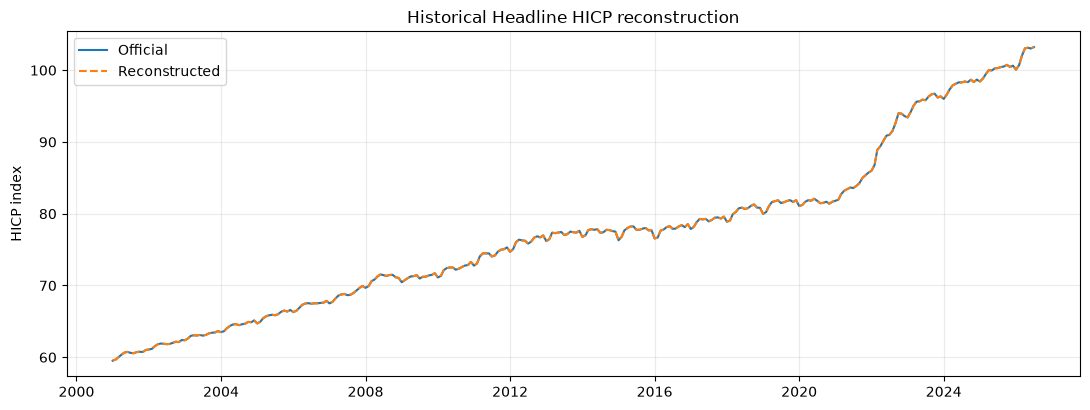

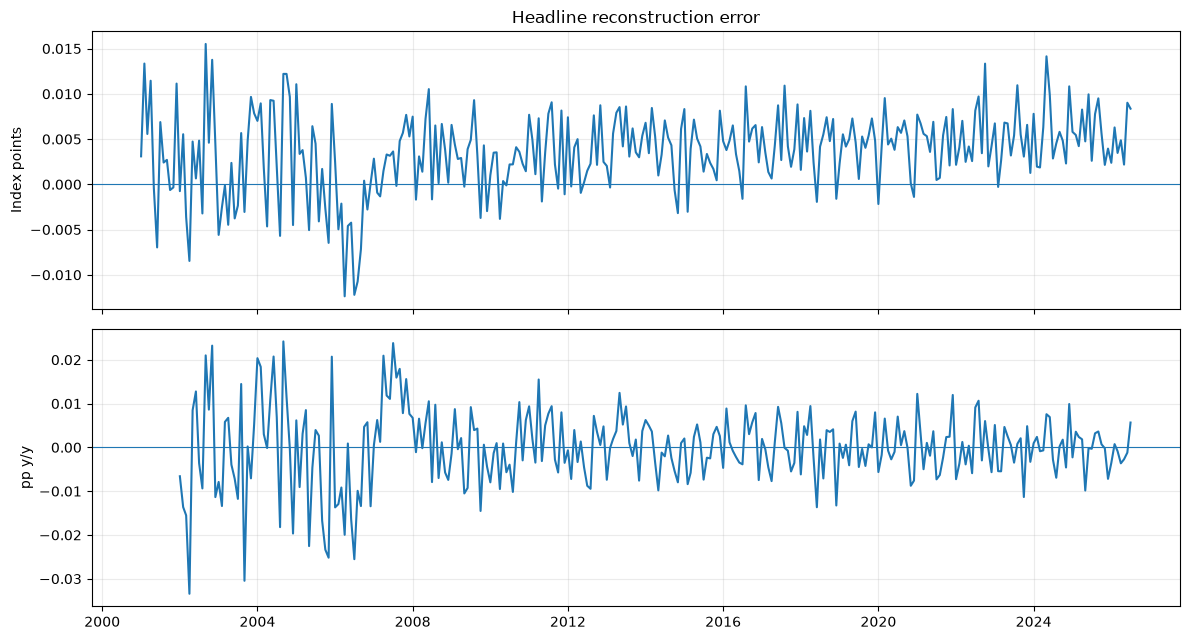

,official_yoy,reconstructed_yoy,yoy_error_pp,january
date,,,,
2002-04-01,2.368726,2.335299,-0.033428,False
2003-09-01,2.128689,2.098226,-0.030463,False
2006-07-01,2.444951,2.419421,-0.025530,False
2005-11-01,2.296547,2.271355,-0.025192,False
2004-09-01,2.115901,2.140093,0.024193,False
2007-07-01,1.764008,1.787815,0.023807,False
2005-10-01,2.449168,2.425809,-0.023359,False
2002-11-01,2.272353,2.295579,0.023226,False
2005-05-01,1.982345,1.959808,-0.022537,False


,n,mean_error_pp,mean_abs_error_pp,rmse_pp,max_abs_error_pp,top10_count
January,25,-0.000113,0.005908,0.007448,0.020364,0
Other months,270,-0.000045,0.006441,0.008721,0.033428,10


In [8]:
RECONSTRUCTION_START_YEAR = resolve_headline_reconstruction_start_year(
    native_levels,
    weights,
    official_total,
)
print("First admissible historical reconstruction year:", RECONSTRUCTION_START_YEAR)

reconstructed_total = reconstruct_headline_history(
    native_levels,
    weights,
    official_total,
    start_year=RECONSTRUCTION_START_YEAR,
)

reconstruction_diag = headline_reconstruction_diagnostics(
    reconstructed_total,
    official_total,
)
display(reconstruction_diag.to_frame())

fig = plot_headline_historical_reconstruction(
    reconstructed_total,
    official_total,
)
display(fig)
plt.close(fig)

aggregation_error_series = pd.concat(
    [
        official_total.rename("official"),
        reconstructed_total.rename("reconstructed"),
    ],
    axis=1,
).dropna()
aggregation_error_series["level_error"] = (
    aggregation_error_series["reconstructed"] - aggregation_error_series["official"]
)
aggregation_error_series["official_yoy"] = 100.0 * (
    aggregation_error_series["official"] / aggregation_error_series["official"].shift(12) - 1.0
)
aggregation_error_series["reconstructed_yoy"] = 100.0 * (
    aggregation_error_series["reconstructed"]
    / aggregation_error_series["reconstructed"].shift(12)
    - 1.0
)
aggregation_error_series["yoy_error_pp"] = (
    aggregation_error_series["reconstructed_yoy"]
    - aggregation_error_series["official_yoy"]
)

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True)
axes[0].plot(aggregation_error_series.index, aggregation_error_series["level_error"])
axes[0].axhline(0.0, linewidth=0.8)
axes[0].set_ylabel("Index points")
axes[0].set_title("Headline reconstruction error")
axes[0].grid(alpha=0.25)

axes[1].plot(aggregation_error_series.index, aggregation_error_series["yoy_error_pp"])
axes[1].axhline(0.0, linewidth=0.8)
axes[1].set_ylabel("pp y/y")
axes[1].grid(alpha=0.25)
fig.tight_layout()
display(fig)
plt.close(fig)

yoy_errors = aggregation_error_series.dropna(subset=["yoy_error_pp"]).copy()
top_idx = yoy_errors["yoy_error_pp"].abs().nlargest(10).index
top_aggregation_errors = yoy_errors.loc[top_idx, [
    "official_yoy", "reconstructed_yoy", "yoy_error_pp"
]].copy()
top_aggregation_errors["january"] = top_aggregation_errors.index.month == 1
display(top_aggregation_errors)

january = yoy_errors.index.month == 1
def _error_row(mask):
    e = yoy_errors.loc[mask, "yoy_error_pp"]
    return {
        "n": int(e.size),
        "mean_error_pp": float(e.mean()),
        "mean_abs_error_pp": float(e.abs().mean()),
        "rmse_pp": float(np.sqrt(np.mean(np.square(e)))),
        "max_abs_error_pp": float(e.abs().max()),
        "top10_count": int(yoy_errors.loc[mask].index.isin(top_idx).sum()),
    }

january_diagnostic = pd.DataFrame(
    [_error_row(january), _error_row(~january)],
    index=["January", "Other months"],
)
display(january_diagnostic)


,n,mean,mae,rmse,max_abs
level_cumulative,307.0,0.003626,0.004786,0.005690,0.015514
level_annual_reanchor,307.0,-0.000056,0.004869,0.006203,0.021354
yoy_cumulative_pp,295.0,-0.000051,0.006395,0.008621,0.033428
yoy_annual_reanchor_pp,295.0,-0.000360,0.010383,0.013862,0.052103


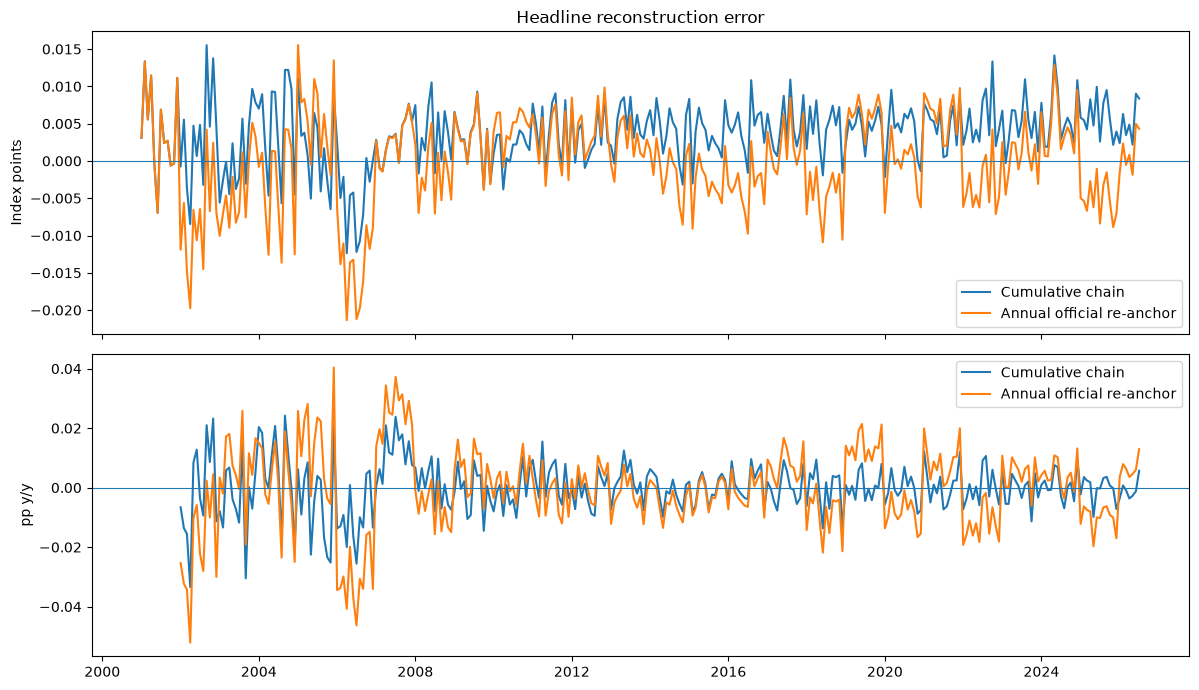

,official_yoy,annual_reanchored_yoy,yoy_error_reanchored,abs_error
date,,,,
2002-04-01,2.368726,2.316623,-0.052103,0.052103
2006-07-01,2.444951,2.398681,-0.046270,0.046270
2006-04-01,2.434941,2.394239,-0.040702,0.040702
2005-12-01,2.241671,2.282046,0.040375,0.040375
2007-07-01,1.764008,1.801244,0.037236,0.037236
2006-06-01,2.457524,2.420371,-0.037153,0.037153
2006-01-01,2.441663,2.407218,-0.034445,0.034445
2007-04-01,1.901649,1.936030,0.034381,0.034381
2002-03-01,2.516247,2.482018,-0.034229,0.034229


In [9]:
# Diagnostic: cumulative chain-linking vs annual official re-anchoring

component_names = [
    "hicp_energy",
    "hicp_food",
    "hicp_neig",
    "hicp_services",
]

native_diag = native_levels[component_names].copy()
native_diag.index = pd.DatetimeIndex(native_diag.index).to_period("M").to_timestamp()

official_diag = official_total.copy()
official_diag.index = pd.DatetimeIndex(official_diag.index).to_period("M").to_timestamp()

weights_diag = weights[component_names].copy()
weights_diag.index = weights_diag.index.astype(int)

# Same historical dates as the existing reconstruction
annual_reanchored = pd.Series(
    index=reconstructed_total.index,
    dtype=float,
    name="annual_reanchored",
)

for date in annual_reanchored.index:
    date = pd.Timestamp(date)
    year = date.year
    dec_prev = pd.Timestamp(year=year - 1, month=12, day=1)

    if year not in weights_diag.index:
        continue
    if dec_prev not in native_diag.index or dec_prev not in official_diag.index:
        continue
    if date not in native_diag.index:
        continue

    w = weights_diag.loc[year]
    base_components = native_diag.loc[dec_prev]
    current_components = native_diag.loc[date]

    if (
        w.isna().any()
        or base_components.isna().any()
        or current_components.isna().any()
        or pd.isna(official_diag.loc[dec_prev])
    ):
        continue

    annual_reanchored.loc[date] = (
        float(official_diag.loc[dec_prev])
        * np.sum(
            (w.to_numpy(dtype=float) / 1000.0)
            * (
                current_components.to_numpy(dtype=float)
                / base_components.to_numpy(dtype=float)
            )
        )
    )


# ------------------------------------------------------------------
# Compare both reconstruction methods
# ------------------------------------------------------------------

comparison = pd.concat(
    [
        official_diag.rename("official"),
        reconstructed_total.rename("cumulative_chain"),
        annual_reanchored,
    ],
    axis=1,
).dropna()

for col in ["official", "cumulative_chain", "annual_reanchored"]:
    comparison[f"{col}_yoy"] = 100.0 * (
        comparison[col] / comparison[col].shift(12) - 1.0
    )

comparison["level_error_cumulative"] = (
    comparison["cumulative_chain"] - comparison["official"]
)
comparison["level_error_reanchored"] = (
    comparison["annual_reanchored"] - comparison["official"]
)

comparison["yoy_error_cumulative"] = (
    comparison["cumulative_chain_yoy"] - comparison["official_yoy"]
)
comparison["yoy_error_reanchored"] = (
    comparison["annual_reanchored_yoy"] - comparison["official_yoy"]
)


def error_summary(x):
    x = x.dropna()
    return pd.Series(
        {
            "n": len(x),
            "mean": x.mean(),
            "mae": x.abs().mean(),
            "rmse": np.sqrt(np.mean(x**2)),
            "max_abs": x.abs().max(),
        }
    )


summary = pd.DataFrame(
    {
        "level_cumulative": error_summary(
            comparison["level_error_cumulative"]
        ),
        "level_annual_reanchor": error_summary(
            comparison["level_error_reanchored"]
        ),
        "yoy_cumulative_pp": error_summary(
            comparison["yoy_error_cumulative"]
        ),
        "yoy_annual_reanchor_pp": error_summary(
            comparison["yoy_error_reanchored"]
        ),
    }
).T

display(summary.round(6))


# ------------------------------------------------------------------
# Error paths
# ------------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(
    comparison.index,
    comparison["level_error_cumulative"],
    label="Cumulative chain",
)
axes[0].plot(
    comparison.index,
    comparison["level_error_reanchored"],
    label="Annual official re-anchor",
)
axes[0].axhline(0.0, linewidth=0.8)
axes[0].set_ylabel("Index points")
axes[0].set_title("Headline reconstruction error")
axes[0].legend()

axes[1].plot(
    comparison.index,
    comparison["yoy_error_cumulative"],
    label="Cumulative chain",
)
axes[1].plot(
    comparison.index,
    comparison["yoy_error_reanchored"],
    label="Annual official re-anchor",
)
axes[1].axhline(0.0, linewidth=0.8)
axes[1].set_ylabel("pp y/y")
axes[1].legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------
# Largest YoY errors after annual re-anchoring
# ------------------------------------------------------------------

top10_reanchored = (
    comparison[
        [
            "official_yoy",
            "annual_reanchored_yoy",
            "yoy_error_reanchored",
        ]
    ]
    .dropna()
    .assign(abs_error=lambda x: x["yoy_error_reanchored"].abs())
    .sort_values("abs_error", ascending=False)
    .head(10)
)

display(top10_reanchored.round(6))

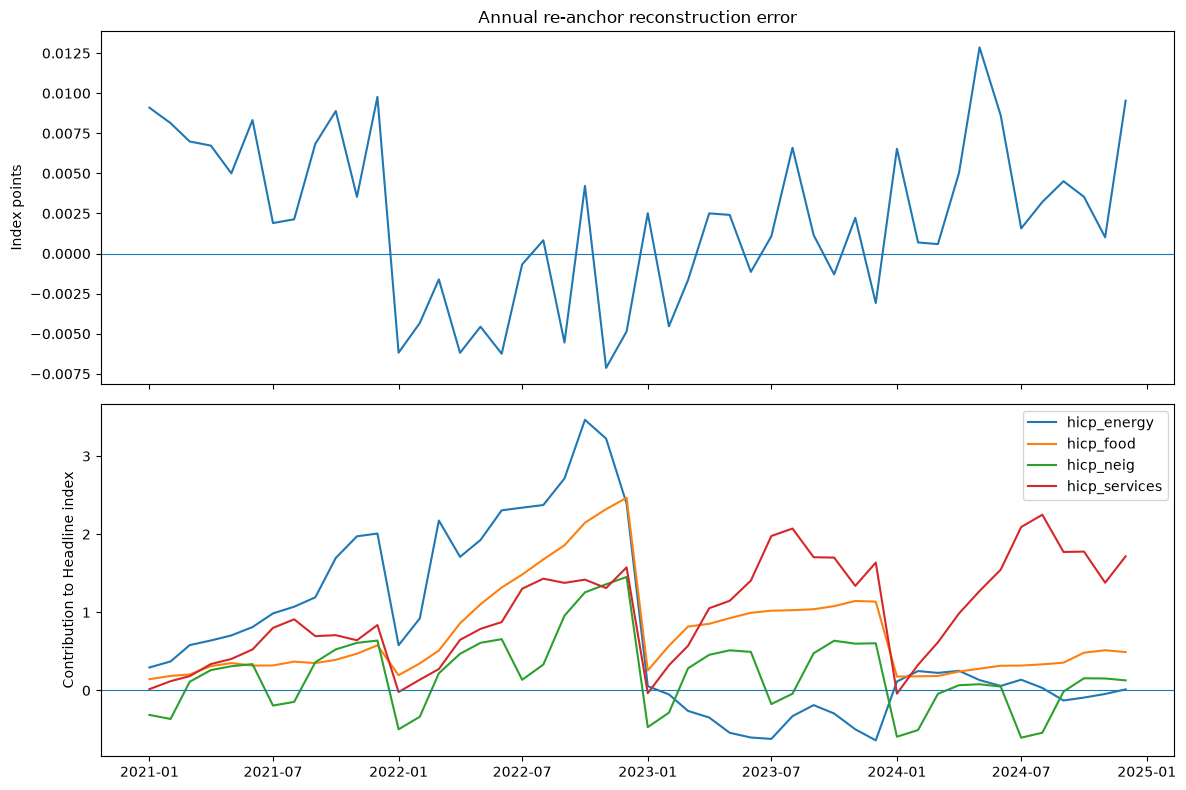

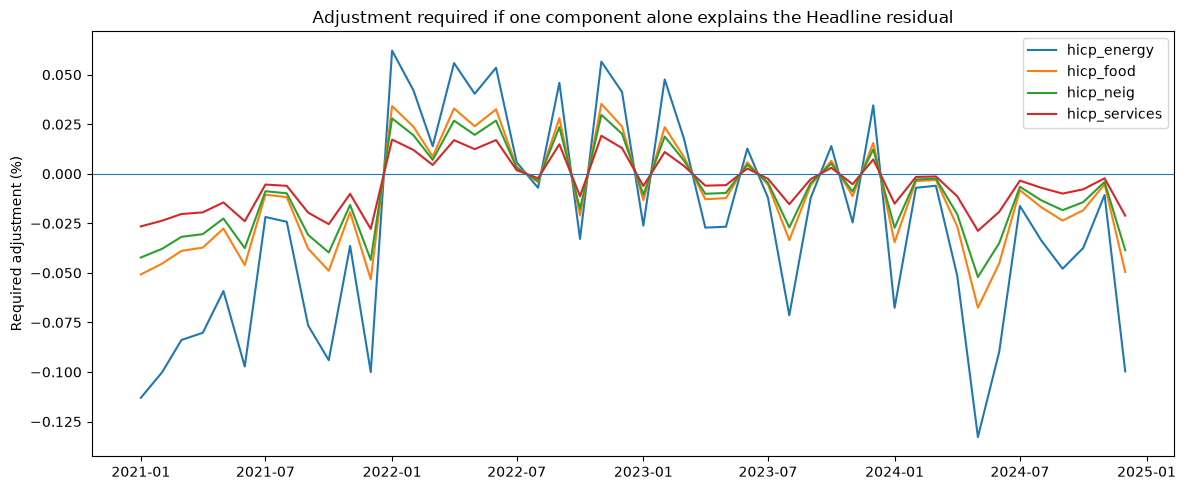

Largest absolute annual-reanchored error:
Date: 2024-05-01
Error: 0.01286 index points



,weight,actual_index,required_index,required_adjustment_index,required_adjustment_pct,contribution_since_december
component,,,,,,
hicp_services,0.45075,96.60,96.572209,-0.027791,-0.028769,1.272582
hicp_neig,0.25547,100.31,100.257758,-0.052242,-0.052081,0.078774
hicp_food,0.19467,97.03,96.964445,-0.065555,-0.067562,0.278571
hicp_energy,0.09912,101.98,101.844544,-0.135456,-0.132826,0.131969


,official,reconstructed,error,abs_error
date,,,,
2024-05-01,98.10,98.112860,0.012860,0.012860
2021-12-01,85.72,85.729772,0.009772,0.009772
2024-12-01,98.69,98.699535,0.009535,0.009535
2021-01-01,81.80,81.809098,0.009098,0.009098
2021-10-01,84.98,84.988888,0.008888,0.008888
2024-06-01,98.31,98.318616,0.008616,0.008616
2021-06-01,83.65,83.658330,0.008330,0.008330
2021-02-01,81.97,81.978134,0.008134,0.008134
2022-11-01,93.94,93.932870,-0.007130,0.007130


In [10]:
# Component audit of annual-reanchored Headline reconstruction

components = [
    "hicp_energy",
    "hicp_food",
    "hicp_neig",
    "hicp_services",
]

audit_rows = []

for date in annual_reanchored.dropna().index:
    date = pd.Timestamp(date)
    year = date.year
    dec_prev = pd.Timestamp(year=year - 1, month=12, day=1)

    if (
        year not in weights_diag.index
        or date not in native_diag.index
        or dec_prev not in native_diag.index
        or date not in official_diag.index
        or dec_prev not in official_diag.index
    ):
        continue

    w = weights_diag.loc[year, components].astype(float) / 1000.0
    base = native_diag.loc[dec_prev, components].astype(float)
    current = native_diag.loc[date, components].astype(float)

    if (
        w.isna().any()
        or base.isna().any()
        or current.isna().any()
        or pd.isna(official_diag.loc[date])
        or pd.isna(official_diag.loc[dec_prev])
    ):
        continue

    anchor = float(official_diag.loc[dec_prev])
    official = float(official_diag.loc[date])

    ratio = current / base

    # Contribution of each component to the change in Headline
    # relative to the previous December anchor.
    contribution = anchor * w * (ratio - 1.0)

    reconstructed = anchor * np.sum(w * ratio)
    error = reconstructed - official

    row = {
        "date": date,
        "official": official,
        "reconstructed": reconstructed,
        "error": error,
    }

    for comp in components:
        row[f"{comp}_contribution"] = contribution[comp]

        # Component ratio that would be required if this component alone
        # were responsible for the entire reconstruction residual.
        others = [c for c in components if c != comp]

        required_ratio = (
            official / anchor
            - np.sum(w[others] * ratio[others])
        ) / w[comp]

        required_index = base[comp] * required_ratio

        row[f"{comp}_actual"] = current[comp]
        row[f"{comp}_required"] = required_index
        row[f"{comp}_required_adjustment"] = (
            required_index - current[comp]
        )

        row[f"{comp}_required_adjustment_pct"] = (
            100.0 * (required_index / current[comp] - 1.0)
        )

    audit_rows.append(row)

component_audit = (
    pd.DataFrame(audit_rows)
    .set_index("date")
    .sort_index()
)

# Focus on the problematic period
window = component_audit.loc["2021-01-01":"2024-12-01"].copy()


# ------------------------------------------------------------
# 1. Reconstruction error and component contributions
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(window.index, window["error"])
axes[0].axhline(0.0, linewidth=0.8)
axes[0].set_ylabel("Index points")
axes[0].set_title("Annual re-anchor reconstruction error")

for comp in components:
    axes[1].plot(
        window.index,
        window[f"{comp}_contribution"],
        label=comp,
    )

axes[1].axhline(0.0, linewidth=0.8)
axes[1].set_ylabel("Contribution to Headline index")
axes[1].legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Required component adjustment to eliminate the residual
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

for comp in components:
    ax.plot(
        window.index,
        window[f"{comp}_required_adjustment_pct"],
        label=comp,
    )

ax.axhline(0.0, linewidth=0.8)
ax.set_ylabel("Required adjustment (%)")
ax.set_title(
    "Adjustment required if one component alone explains the Headline residual"
)
ax.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Date of maximum error
# ------------------------------------------------------------

peak_date = window["error"].abs().idxmax()

print("Largest absolute annual-reanchored error:")
print("Date:", peak_date.date())
print("Error:", round(window.loc[peak_date, "error"], 6), "index points")
print()

peak_rows = []

for comp in components:
    peak_rows.append(
        {
            "component": comp,
            "weight": float(
                weights_diag.loc[peak_date.year, comp] / 1000.0
            ),
            "actual_index": window.loc[
                peak_date, f"{comp}_actual"
            ],
            "required_index": window.loc[
                peak_date, f"{comp}_required"
            ],
            "required_adjustment_index": window.loc[
                peak_date, f"{comp}_required_adjustment"
            ],
            "required_adjustment_pct": window.loc[
                peak_date, f"{comp}_required_adjustment_pct"
            ],
            "contribution_since_december": window.loc[
                peak_date, f"{comp}_contribution"
            ],
        }
    )

peak_table = (
    pd.DataFrame(peak_rows)
    .set_index("component")
    .sort_values("required_adjustment_pct", key=np.abs)
)

display(peak_table.round(6))


# ------------------------------------------------------------
# 4. Top 10 residual dates
# ------------------------------------------------------------

top_dates = (
    window[["official", "reconstructed", "error"]]
    .assign(abs_error=lambda x: x["error"].abs())
    .sort_values("abs_error", ascending=False)
    .head(10)
)

display(top_dates.round(6))

## 6. Core inflation — ex energy, food, alcohol and tobacco

The Core validation target is Eurostat special aggregate **`TOT_X_NRG_FOOD`**:
all-items HICP excluding energy, food, alcohol and tobacco. Under the locked
four-way Headline decomposition this basket is exactly **NEIG + Services**.

The reconstruction is deliberately basket-aware. The annual NEIG and Services
weights are first renormalised inside the Core basket,

\[
\tilde w_{i,y}=\frac{w_{i,y}}{w_{\mathrm{NEIG},y}+w_{\mathrm{Services},y}},
\]

then the same December chain-link used for Headline is applied:

\[
C_t=C_{\mathrm{Dec}(y-1)}
\sum_{i\in\{\mathrm{NEIG,Services}\}}
\tilde w_{i,y}
\frac{I_{i,t}}{I_{i,\mathrm{Dec}(y-1)}}.
\]

The official Eurostat series is used as a **validation gate**, not as a hidden
third component. A second reconstruction anchored to 100 checks that YoY growth
is invariant to the arbitrary first level anchor.

For the API call this section uses Eurostat's **Statistics API with named
dimension filters** (`freq`, `unit`, `coicop18`, `geo`). No positional SDMX key
or dimension order is assumed.


In [11]:
def _jsonstat_ordered_codes(dimension: Mapping) -> list[str]:
    """Return JSON-stat category codes in their declared order."""
    category = dict(dimension.get("category", {}) or {})
    index = category.get("index", {})
    if isinstance(index, Mapping):
        return [
            str(code)
            for code, _ in sorted(index.items(), key=lambda item: int(item[1]))
        ]
    if isinstance(index, Sequence) and not isinstance(index, (str, bytes)):
        return [str(code) for code in index]
    raise RuntimeError("Unsupported JSON-stat category.index representation.")


def _jsonstat_dense_values(payload: Mapping) -> np.ndarray:
    """Expand JSON-stat dense or sparse values to the declared cube shape."""
    size = [int(x) for x in payload.get("size", [])]
    if not size:
        raise RuntimeError("Eurostat JSON-stat response has no dimension sizes.")
    n = int(np.prod(size))
    raw = payload.get("value", [])

    dense = np.full(n, np.nan, dtype=float)
    if isinstance(raw, Mapping):
        for key, value in raw.items():
            pos = int(key)
            if pos < 0 or pos >= n:
                raise RuntimeError(f"JSON-stat sparse value position {pos} is out of bounds.")
            if value is not None:
                dense[pos] = float(value)
    elif isinstance(raw, Sequence) and not isinstance(raw, (str, bytes)):
        if len(raw) != n:
            raise RuntimeError(
                f"Eurostat JSON-stat value length {len(raw)} does not match cube size {n}."
            )
        dense = np.asarray(
            [np.nan if value is None else float(value) for value in raw],
            dtype=float,
        )
    else:
        raise RuntimeError("Unsupported JSON-stat value representation.")

    return dense.reshape(tuple(size))


def _jsonstat_single_monthly_series(
    payload: Mapping,
    *,
    expected_dimensions: Mapping[str, str],
    name: str,
) -> tuple[pd.Series, str]:
    """Extract one monthly series without assuming any dimension order."""
    ids = [str(x).lower() for x in payload.get("id", [])]
    dimensions = dict(payload.get("dimension", {}) or {})
    dimensions_lower = {str(k).lower(): v for k, v in dimensions.items()}

    if not ids:
        raise RuntimeError("Eurostat JSON-stat response has no dimension ids.")

    for dim, expected in expected_dimensions.items():
        dim = str(dim).lower()
        if dim not in ids or dim not in dimensions_lower:
            raise RuntimeError(
                f"Eurostat Core response is missing dimension {dim!r}; found {ids}."
            )
        observed = _jsonstat_ordered_codes(dimensions_lower[dim])
        if observed != [str(expected)]:
            raise RuntimeError(
                f"Eurostat Core response: expected {dim}={expected!r}, found {observed}."
            )

    time_dim = next(
        (dim for dim in ids if dim in {"time", "time_period"}),
        None,
    )
    if time_dim is None:
        raise RuntimeError(f"Eurostat Core response has no time dimension; found {ids}.")

    time_codes = _jsonstat_ordered_codes(dimensions_lower[time_dim])
    cube = _jsonstat_dense_values(payload)

    # Every named non-time filter must leave one category. Slice those axes
    # explicitly; preserve whichever axis Eurostat uses for time.
    slicer = []
    for axis, dim in enumerate(ids):
        if dim == time_dim:
            slicer.append(slice(None))
        else:
            if cube.shape[axis] != 1:
                raise RuntimeError(
                    f"Expected one selected category for dimension {dim!r}, "
                    f"found size={cube.shape[axis]}."
                )
            slicer.append(0)

    values = np.asarray(cube[tuple(slicer)], dtype=float).reshape(-1)
    if len(values) != len(time_codes):
        raise RuntimeError(
            f"Eurostat Core time/value length mismatch: {len(time_codes)} vs {len(values)}."
        )

    dates = pd.PeriodIndex(time_codes, freq="M").to_timestamp(how="start")
    series = pd.Series(values, index=dates, name=name).dropna()
    series.index = pd.DatetimeIndex(series.index, name="date")
    if series.index.has_duplicates:
        duplicates = series.index[series.index.duplicated(keep=False)]
        raise RuntimeError(
            "Eurostat Core response contains duplicate months: "
            + ", ".join(pd.DatetimeIndex(duplicates).strftime("%Y-%m"))
        )
    if series.empty:
        raise RuntimeError("Eurostat Core API returned no usable observations.")
    if (series <= 0).any():
        first_bad = series.index[(series <= 0)][0]
        raise RuntimeError(
            f"Eurostat Core index must be positive; first invalid month is "
            f"{pd.Timestamp(first_bad).date()}."
        )

    coicop_dim = dimensions_lower.get("coicop18", {})
    labels = dict((coicop_dim.get("category", {}) or {}).get("label", {}) or {})
    label = str(labels.get(EUROSTAT_CORE_CODE, EUROSTAT_CORE_CODE))
    return series.astype(float), label


def load_eurostat_core_index(start_period: str) -> tuple[pd.Series, dict[str, object]]:
    """Download Eurostat official Core HICP with named, order-independent filters."""
    url = f"{EUROSTAT_STATS_API}/{EUROSTAT_CORE_DATASET}"
    params = {
        "format": "JSON",
        "lang": "EN",
        "freq": "M",
        "unit": EUROSTAT_CORE_UNIT,
        "coicop18": EUROSTAT_CORE_CODE,
        "geo": EUROSTAT_CORE_GEO,
        "sinceTimePeriod": str(start_period),
    }
    response = requests.get(url, params=params, timeout=90)
    response.raise_for_status()
    payload = response.json()

    if isinstance(payload, Mapping) and payload.get("error"):
        raise RuntimeError(f"Eurostat Core API error: {payload['error']}")

    core, label = _jsonstat_single_monthly_series(
        payload,
        expected_dimensions={
            "freq": "M",
            "unit": EUROSTAT_CORE_UNIT,
            "coicop18": EUROSTAT_CORE_CODE,
            "geo": EUROSTAT_CORE_GEO,
        },
        name="hicp_core",
    )

    metadata = {
        "provider": "Eurostat",
        "api": "statistics/1.0",
        "dataset": EUROSTAT_CORE_DATASET,
        "code": EUROSTAT_CORE_CODE,
        "label": label,
        "unit": EUROSTAT_CORE_UNIT,
        "geo": EUROSTAT_CORE_GEO,
        "request_url": response.url,
        "retrieved_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
        "first_date": core.index.min().date().isoformat(),
        "last_date": core.index.max().date().isoformat(),
        "n_observations": int(core.notna().sum()),
        "dimension_order_returned": list(payload.get("id", [])),
    }
    return core, metadata


# Core uses only NEIG + Services, so do NOT inherit the Food-trimmed joint-model
# start date. This is the basket-aware historical input.
core_native_levels = native_levels_processed.loc[:, list(CORE_COMPONENTS)].copy()
core_native_levels.index = (
    pd.DatetimeIndex(core_native_levels.index)
    .to_period("M")
    .to_timestamp(how="start")
)

core_api_start = (
    pd.Timestamp(core_native_levels.index.min()) - pd.DateOffset(months=1)
).strftime("%Y-%m")

official_core, CORE_SOURCE_METADATA = load_eurostat_core_index(core_api_start)

print("Official Core source:", CORE_SOURCE_METADATA["label"])
print(
    "Eurostat:",
    CORE_SOURCE_METADATA["dataset"],
    "/",
    CORE_SOURCE_METADATA["code"],
    "/",
    CORE_SOURCE_METADATA["unit"],
    "/",
    CORE_SOURCE_METADATA["geo"],
)
print(
    "Official Core coverage:",
    CORE_SOURCE_METADATA["first_date"],
    "->",
    CORE_SOURCE_METADATA["last_date"],
)
print("Returned dimension order:", CORE_SOURCE_METADATA["dimension_order_returned"])
print("Request:", CORE_SOURCE_METADATA["request_url"])


Official Core source: Overall index excluding energy, food, alcohol and tobacco
Eurostat: prc_hicp_minr / TOT_X_NRG_FOOD / I25 / EA
Official Core coverage: 1999-12-01 -> 2026-07-01
Returned dimension order: ['freq', 'unit', 'coicop18', 'geo', 'time']
Request: https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/prc_hicp_minr?format=JSON&lang=EN&freq=M&unit=I25&coicop18=TOT_X_NRG_FOOD&geo=EA&sinceTimePeriod=1999-11


In [12]:
def core_weight_table(annual_weights: pd.DataFrame) -> pd.DataFrame:
    """Renormalise published NEIG/Services weights inside the Core basket."""
    missing = [name for name in CORE_COMPONENTS if name not in annual_weights.columns]
    if missing:
        raise KeyError(f"Core weights are missing columns: {missing}.")

    raw = annual_weights.loc[:, list(CORE_COMPONENTS)].copy().sort_index()
    raw.index = raw.index.astype(int)
    denominator = raw.sum(axis=1, min_count=len(CORE_COMPONENTS))

    out = raw.div(denominator, axis=0)
    invalid = denominator.isna() | (denominator <= 0)
    out.loc[invalid, :] = np.nan

    complete = out.notna().all(axis=1)
    if complete.any():
        max_sum_error = float((out.loc[complete].sum(axis=1) - 1.0).abs().max())
        if max_sum_error > 1e-12:
            raise AssertionError(
                f"Core renormalised weights do not sum to one: max error={max_sum_error:.3e}."
            )
    return out


def resolve_core_reconstruction_start_year(
    core_levels: pd.DataFrame,
    annual_weights: pd.DataFrame,
    anchor_series: pd.Series | None = None,
) -> int:
    """First year admissible for the NEIG+Services basket.

    Unlike the Headline resolver, this checks only Core components. If
    anchor_series is None, no official aggregate is required.
    """
    native = core_levels.loc[:, list(CORE_COMPONENTS)].copy().sort_index()
    native.index = (
        pd.DatetimeIndex(native.index)
        .to_period("M")
        .to_timestamp(how="start")
    )
    core_weights = core_weight_table(annual_weights)

    anchor = None
    if anchor_series is not None:
        anchor = anchor_series.copy().sort_index()
        anchor.index = (
            pd.DatetimeIndex(anchor.index)
            .to_period("M")
            .to_timestamp(how="start")
        )

    complete_years = [
        int(year)
        for year, row in core_weights.iterrows()
        if row.notna().all()
    ]
    if not complete_years:
        raise ValueError("No complete NEIG/Services annual Core weight vector exists.")

    rejected = []
    for year in sorted(complete_years):
        dec_prev = pd.Timestamp(year=year - 1, month=12, day=1)

        if dec_prev not in native.index:
            rejected.append(f"{year}: component December outside Core panel")
            continue

        base = native.loc[dec_prev, list(CORE_COMPONENTS)]
        if base.isna().any():
            rejected.append(f"{year}: missing Core component December")
            continue

        if anchor is not None and (
            dec_prev not in anchor.index or pd.isna(anchor.loc[dec_prev])
        ):
            rejected.append(f"{year}: official Core anchor missing")
            continue

        return int(year)

    detail = "; ".join(rejected[:6])
    if len(rejected) > 6:
        detail += "; ..."
    raise ValueError(
        "No admissible Core reconstruction start year. "
        f"Checked basket-aware requirements. {detail}"
    )


def reconstruct_core_history(
    core_levels: pd.DataFrame,
    annual_weights: pd.DataFrame,
    *,
    start_year: int | None = None,
    end_date: str | pd.Timestamp | None = None,
    anchor_series: pd.Series | None = None,
    anchor_value: float = 100.0,
) -> pd.Series:
    """December-chain NEIG + Services into a Core HICP level index."""
    native = core_levels.loc[:, list(CORE_COMPONENTS)].copy().sort_index()
    native.index = (
        pd.DatetimeIndex(native.index)
        .to_period("M")
        .to_timestamp(how="start")
    )
    core_weights = core_weight_table(annual_weights)

    anchor = None
    if anchor_series is not None:
        anchor = anchor_series.copy().sort_index()
        anchor.index = (
            pd.DatetimeIndex(anchor.index)
            .to_period("M")
            .to_timestamp(how="start")
        )

    if start_year is None:
        start_year = resolve_core_reconstruction_start_year(
            native,
            annual_weights,
            anchor_series=anchor,
        )
    start_year = int(start_year)

    last_date = pd.Timestamp(native.index.max())
    if end_date is not None:
        last_date = min(
            last_date,
            pd.Timestamp(end_date).to_period("M").to_timestamp(how="start"),
        )

    if anchor is not None:
        last_date = min(last_date, pd.Timestamp(anchor.index.max()))

    reconstructed = pd.Series(
        index=native.index[
            (native.index.year >= start_year) & (native.index <= last_date)
        ],
        dtype=float,
        name="hicp_core_reconstructed",
    )

    previous_december_aggregate = None

    for year in range(start_year, int(last_date.year) + 1):
        if year not in core_weights.index:
            raise ValueError(f"Core reconstruction is missing annual weights for {year}.")

        weight_row = core_weights.loc[year, list(CORE_COMPONENTS)]
        if weight_row.isna().any():
            raise ValueError(f"Core reconstruction has incomplete annual weights for {year}.")

        dec_prev = pd.Timestamp(year=year - 1, month=12, day=1)
        if dec_prev not in native.index:
            raise ValueError(
                f"Core reconstruction needs component December {dec_prev.date()}."
            )

        base_components = native.loc[dec_prev, list(CORE_COMPONENTS)]
        if base_components.isna().any():
            raise ValueError(
                f"Core reconstruction has missing component level at {dec_prev.date()}."
            )

        if previous_december_aggregate is None:
            if anchor is not None:
                if dec_prev not in anchor.index or pd.isna(anchor.loc[dec_prev]):
                    raise ValueError(
                        f"Official Core anchor missing at {dec_prev.date()}."
                    )
                year_anchor = float(anchor.loc[dec_prev])
            else:
                year_anchor = float(anchor_value)
                if not np.isfinite(year_anchor) or year_anchor <= 0:
                    raise ValueError("Synthetic Core anchor_value must be positive and finite.")
        else:
            year_anchor = float(previous_december_aggregate)

        year_dates = native.index[
            (native.index.year == year) & (native.index <= last_date)
        ]
        for date in year_dates:
            current = native.loc[date, list(CORE_COMPONENTS)]
            if current.isna().any():
                continue
            ratio = current / base_components
            reconstructed.loc[date] = float(
                year_anchor * np.sum(weight_row.to_numpy(dtype=float) * ratio.to_numpy(dtype=float))
            )

        december = pd.Timestamp(year=year, month=12, day=1)
        if december in reconstructed.index and pd.notna(reconstructed.loc[december]):
            previous_december_aggregate = float(reconstructed.loc[december])
        elif year < last_date.year:
            raise ValueError(
                f"Cannot chain Core into {year + 1}: reconstructed December {year} is missing."
            )

    reconstructed.index = pd.DatetimeIndex(reconstructed.index, name="date")
    return reconstructed.sort_index()


def annual_reanchored_core_history(
    core_levels: pd.DataFrame,
    annual_weights: pd.DataFrame,
    official_core: pd.Series,
    *,
    start_year: int,
    end_date: str | pd.Timestamp | None = None,
) -> pd.Series:
    """Diagnostic only: re-anchor every year to official Core December."""
    native = core_levels.loc[:, list(CORE_COMPONENTS)].copy().sort_index()
    native.index = (
        pd.DatetimeIndex(native.index)
        .to_period("M")
        .to_timestamp(how="start")
    )
    official = official_core.copy().sort_index()
    official.index = (
        pd.DatetimeIndex(official.index)
        .to_period("M")
        .to_timestamp(how="start")
    )
    core_weights = core_weight_table(annual_weights)

    last_date = min(pd.Timestamp(native.index.max()), pd.Timestamp(official.index.max()))
    if end_date is not None:
        last_date = min(
            last_date,
            pd.Timestamp(end_date).to_period("M").to_timestamp(how="start"),
        )

    out = pd.Series(
        index=native.index[
            (native.index.year >= int(start_year)) & (native.index <= last_date)
        ],
        dtype=float,
        name="hicp_core_annual_reanchored",
    )

    for date in out.index:
        year = int(pd.Timestamp(date).year)
        dec_prev = pd.Timestamp(year=year - 1, month=12, day=1)

        if year not in core_weights.index:
            continue
        if dec_prev not in native.index or dec_prev not in official.index:
            continue
        if date not in native.index:
            continue

        weight_row = core_weights.loc[year, list(CORE_COMPONENTS)]
        base = native.loc[dec_prev, list(CORE_COMPONENTS)]
        current = native.loc[date, list(CORE_COMPONENTS)]

        if (
            weight_row.isna().any()
            or base.isna().any()
            or current.isna().any()
            or pd.isna(official.loc[dec_prev])
        ):
            continue

        ratio = current / base
        out.loc[date] = float(
            float(official.loc[dec_prev])
            * np.sum(weight_row.to_numpy(dtype=float) * ratio.to_numpy(dtype=float))
        )

    return out


def core_reconstruction_diagnostics(
    reconstructed: pd.Series,
    official_core: pd.Series,
) -> pd.Series:
    """Level and YoY errors of a Core reconstruction against Eurostat."""
    joined = pd.concat(
        [
            reconstructed.rename("reconstructed"),
            official_core.rename("official"),
        ],
        axis=1,
    ).dropna()
    if joined.empty:
        raise ValueError("No overlap between reconstructed and official Core HICP.")

    level_error = joined["reconstructed"] - joined["official"]
    reconstructed_yoy = 100.0 * (
        joined["reconstructed"] / joined["reconstructed"].shift(12) - 1.0
    )
    official_yoy = 100.0 * (
        joined["official"] / joined["official"].shift(12) - 1.0
    )
    yoy_error = (reconstructed_yoy - official_yoy).dropna()

    return pd.Series(
        {
            "n_level_months": int(level_error.size),
            "level_mae": float(level_error.abs().mean()),
            "level_rmse": float(np.sqrt(np.mean(np.square(level_error)))),
            "level_max_abs_error": float(level_error.abs().max()),
            "n_yoy_months": int(yoy_error.size),
            "yoy_mae_pp": float(yoy_error.abs().mean()) if len(yoy_error) else np.nan,
            "yoy_rmse_pp": (
                float(np.sqrt(np.mean(np.square(yoy_error))))
                if len(yoy_error)
                else np.nan
            ),
            "yoy_max_abs_error_pp": (
                float(yoy_error.abs().max()) if len(yoy_error) else np.nan
            ),
        },
        name="value",
    )


core_weights = core_weight_table(weights)
complete_core_weights = core_weights.dropna(how="any")
core_weight_check = pd.DataFrame(
    {
        "raw_neig_plus_services_per_1000": weights.loc[
            complete_core_weights.index, list(CORE_COMPONENTS)
        ].sum(axis=1),
        "renormalised_sum": complete_core_weights.sum(axis=1),
        "renormalised_error": complete_core_weights.sum(axis=1) - 1.0,
    }
)
display(core_weight_check.tail(12))

CORE_START_SYNTHETIC = resolve_core_reconstruction_start_year(
    core_native_levels,
    weights,
    anchor_series=None,
)
CORE_START_OFFICIAL = resolve_core_reconstruction_start_year(
    core_native_levels,
    weights,
    anchor_series=official_core,
)
print("First basket-admissible Core year:", CORE_START_SYNTHETIC)
print("First Core year also testable against Eurostat:", CORE_START_OFFICIAL)

reconstructed_core = reconstruct_core_history(
    core_native_levels,
    weights,
    start_year=CORE_START_OFFICIAL,
    anchor_series=official_core,
)
reconstructed_core_100 = reconstruct_core_history(
    core_native_levels,
    weights,
    start_year=CORE_START_OFFICIAL,
    anchor_series=None,
    anchor_value=100.0,
    end_date=official_core.index.max(),
)
annual_reanchored_core = annual_reanchored_core_history(
    core_native_levels,
    weights,
    official_core,
    start_year=CORE_START_OFFICIAL,
)

# Exact invariants.
max_core_weight_error = float(
    (complete_core_weights.sum(axis=1) - 1.0).abs().max()
)
if max_core_weight_error > 1e-12:
    raise AssertionError(
        f"Core weight renormalisation failed: {max_core_weight_error:.3e}."
    )

anchored_yoy = 100.0 * (
    reconstructed_core / reconstructed_core.shift(12) - 1.0
)
synthetic_yoy = 100.0 * (
    reconstructed_core_100 / reconstructed_core_100.shift(12) - 1.0
)
anchor_yoy_comparison = pd.concat(
    [anchored_yoy.rename("official_anchor"), synthetic_yoy.rename("anchor_100")],
    axis=1,
).dropna()
anchor_invariance_error = float(
    (anchor_yoy_comparison["official_anchor"] - anchor_yoy_comparison["anchor_100"])
    .abs()
    .max()
)
print("Max Core weight-sum error:", max_core_weight_error)
print("Max YoY difference: official first anchor vs anchor=100:", anchor_invariance_error)
if anchor_invariance_error > 1e-10:
    raise AssertionError(
        f"Core YoY is not anchor-invariant within tolerance: {anchor_invariance_error:.3e}."
    )


,raw_neig_plus_services_per_1000,renormalised_sum,renormalised_error
year,,,
2015,697.33,1.0,0.000000e+00
2016,707.28,1.0,0.000000e+00
2017,709.57,1.0,0.000000e+00
2018,708.08,1.0,0.000000e+00
2019,708.54,1.0,0.000000e+00
2020,710.78,1.0,0.000000e+00
2021,687.42,1.0,0.000000e+00
2022,681.84,1.0,0.000000e+00
2023,697.98,1.0,-1.110223e-16


First basket-admissible Core year: 2001
First Core year also testable against Eurostat: 2001
Max Core weight-sum error: 1.1102230246251565e-16
Max YoY difference: official first anchor vs anchor=100: 4.440892098500626e-14


C:\Users\kelyan.gane\AppData\Local\Temp\ipykernel_75008\4177219454.py:278: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  joined = pd.concat(
C:\Users\kelyan.gane\AppData\Local\Temp\ipykernel_75008\4177219454.py:278: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  joined = pd.concat(


,n_level_months,level_mae,level_rmse,level_max_abs_error,n_yoy_months,yoy_mae_pp,yoy_rmse_pp,yoy_max_abs_error_pp
cumulative_chain,307.0,0.003473,0.004176,0.010893,295.0,0.005569,0.006790,0.018971
annual_official_reanchor,307.0,0.004063,0.004912,0.014499,295.0,0.007388,0.009102,0.027201


,n,mean,mae,rmse,max_abs
level_cumulative,307.0,0.001873,0.003473,0.004176,0.010893
level_annual_reanchor,307.0,0.000903,0.004063,0.004912,0.014499
yoy_cumulative_pp,295.0,-0.000081,0.005569,0.006790,0.018971
yoy_annual_reanchor_pp,295.0,-0.000275,0.007388,0.009102,0.027201


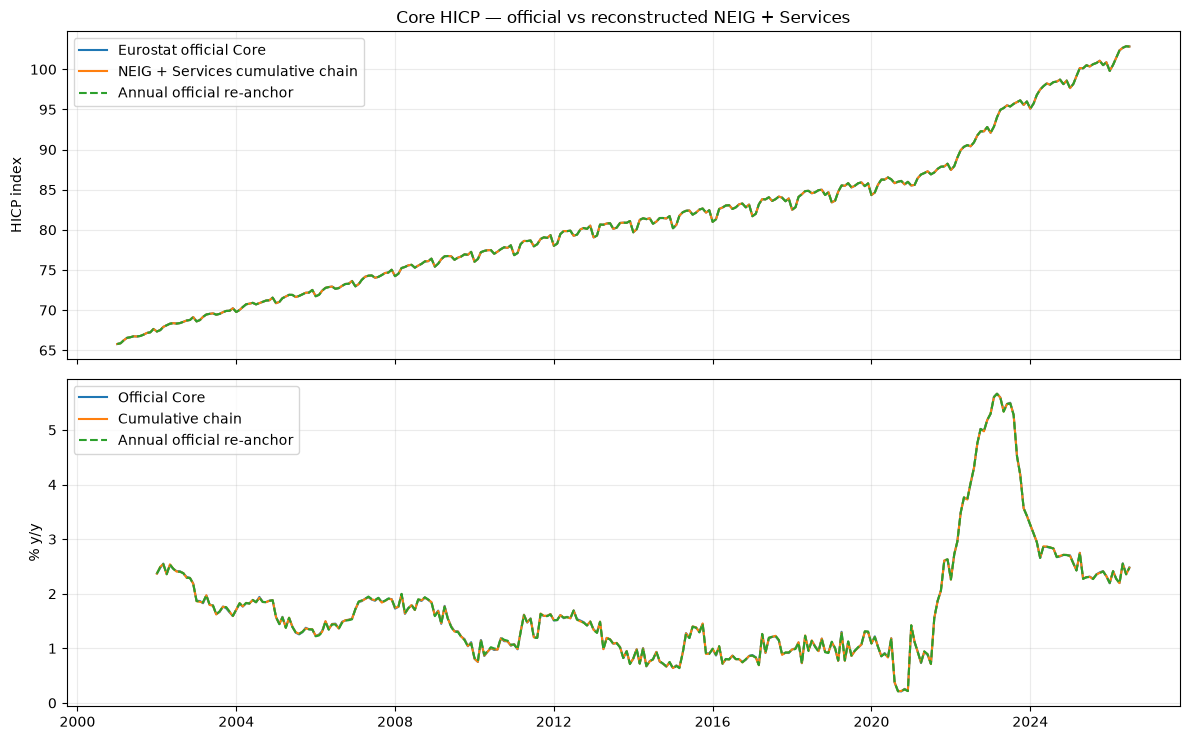

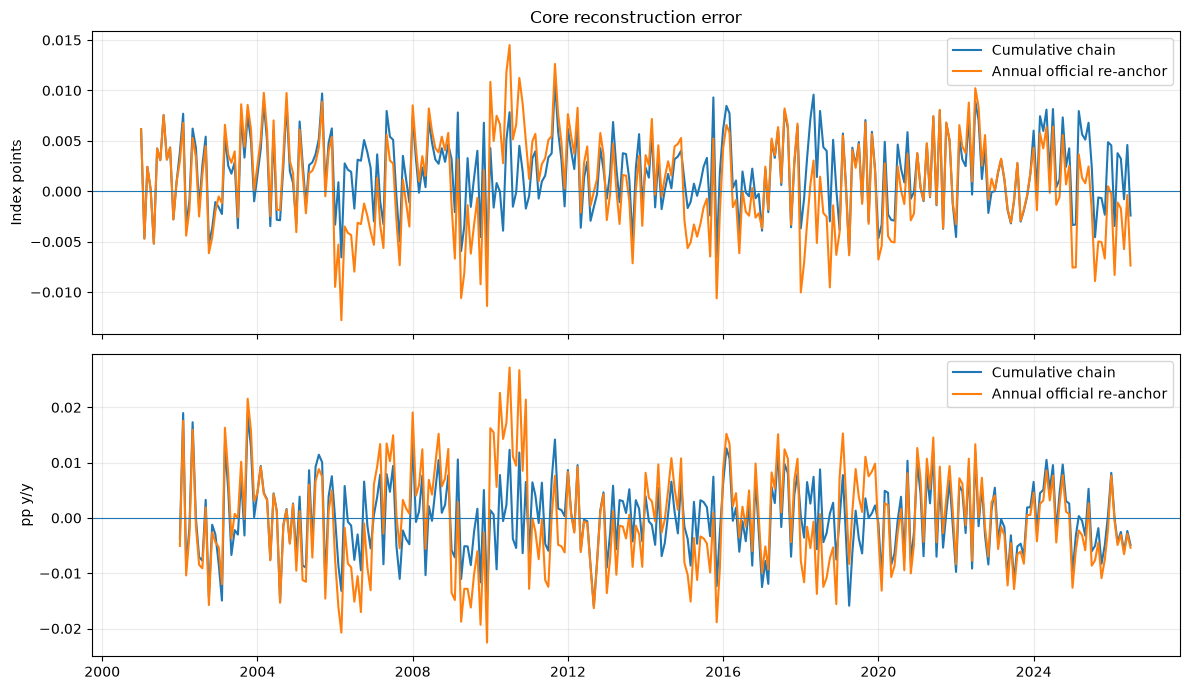

,official_yoy,annual_reanchored_yoy,yoy_error_reanchored,january
date,,,,
2010-07-01,0.970237,0.997439,0.027201,False
2010-10-01,1.130604,1.157331,0.026727,False
2010-04-01,0.860383,0.883006,0.022623,False
2009-12-01,1.112420,1.089867,-0.022552,False
2003-10-01,1.732169,1.753728,0.021559,False
2010-12-01,1.048408,1.069806,0.021398,False
2006-03-01,1.315053,1.294311,-0.020742,False
2009-10-01,1.170129,1.150805,-0.019324,False
2008-01-01,1.726974,1.746054,0.019080,True


,n,mean_error_pp,mean_abs_error_pp,rmse_pp,max_abs_error_pp,top10_count
January,25,-0.000388,0.008996,0.009812,0.019080,1
Other months,270,-0.000264,0.007239,0.009034,0.027201,9


In [13]:
core_diag_cumulative = core_reconstruction_diagnostics(
    reconstructed_core,
    official_core,
)
core_diag_annual = core_reconstruction_diagnostics(
    annual_reanchored_core,
    official_core,
)

core_diag_table = pd.concat(
    [
        core_diag_cumulative.rename("cumulative_chain"),
        core_diag_annual.rename("annual_official_reanchor"),
    ],
    axis=1,
).T
display(core_diag_table.round(6))

core_comparison = pd.concat(
    [
        official_core.rename("official"),
        reconstructed_core.rename("cumulative_chain"),
        annual_reanchored_core.rename("annual_reanchored"),
    ],
    axis=1,
).dropna()

for col in ("official", "cumulative_chain", "annual_reanchored"):
    core_comparison[f"{col}_yoy"] = 100.0 * (
        core_comparison[col] / core_comparison[col].shift(12) - 1.0
    )

core_comparison["level_error_cumulative"] = (
    core_comparison["cumulative_chain"] - core_comparison["official"]
)
core_comparison["level_error_reanchored"] = (
    core_comparison["annual_reanchored"] - core_comparison["official"]
)
core_comparison["yoy_error_cumulative"] = (
    core_comparison["cumulative_chain_yoy"] - core_comparison["official_yoy"]
)
core_comparison["yoy_error_reanchored"] = (
    core_comparison["annual_reanchored_yoy"] - core_comparison["official_yoy"]
)


def _core_error_summary(series: pd.Series) -> pd.Series:
    x = series.dropna()
    return pd.Series(
        {
            "n": int(len(x)),
            "mean": float(x.mean()),
            "mae": float(x.abs().mean()),
            "rmse": float(np.sqrt(np.mean(np.square(x)))),
            "max_abs": float(x.abs().max()),
        }
    )


core_error_summary = pd.DataFrame(
    {
        "level_cumulative": _core_error_summary(
            core_comparison["level_error_cumulative"]
        ),
        "level_annual_reanchor": _core_error_summary(
            core_comparison["level_error_reanchored"]
        ),
        "yoy_cumulative_pp": _core_error_summary(
            core_comparison["yoy_error_cumulative"]
        ),
        "yoy_annual_reanchor_pp": _core_error_summary(
            core_comparison["yoy_error_reanchored"]
        ),
    }
).T
display(core_error_summary.round(6))

# Official vs reconstructed paths.
fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)

axes[0].plot(core_comparison.index, core_comparison["official"], label="Eurostat official Core")
axes[0].plot(
    core_comparison.index,
    core_comparison["cumulative_chain"],
    label="NEIG + Services cumulative chain",
)
axes[0].plot(
    core_comparison.index,
    core_comparison["annual_reanchored"],
    linestyle="--",
    label="Annual official re-anchor",
)
axes[0].set_ylabel("HICP index")
axes[0].set_title("Core HICP — official vs reconstructed NEIG + Services")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(core_comparison.index, core_comparison["official_yoy"], label="Official Core")
axes[1].plot(
    core_comparison.index,
    core_comparison["cumulative_chain_yoy"],
    label="Cumulative chain",
)
axes[1].plot(
    core_comparison.index,
    core_comparison["annual_reanchored_yoy"],
    linestyle="--",
    label="Annual official re-anchor",
)
axes[1].set_ylabel("% y/y")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
display(fig)
plt.close(fig)

# Error paths, same diagnostic split used above for Headline.
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(
    core_comparison.index,
    core_comparison["level_error_cumulative"],
    label="Cumulative chain",
)
axes[0].plot(
    core_comparison.index,
    core_comparison["level_error_reanchored"],
    label="Annual official re-anchor",
)
axes[0].axhline(0.0, linewidth=0.8)
axes[0].set_ylabel("Index points")
axes[0].set_title("Core reconstruction error")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    core_comparison.index,
    core_comparison["yoy_error_cumulative"],
    label="Cumulative chain",
)
axes[1].plot(
    core_comparison.index,
    core_comparison["yoy_error_reanchored"],
    label="Annual official re-anchor",
)
axes[1].axhline(0.0, linewidth=0.8)
axes[1].set_ylabel("pp y/y")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
display(fig)
plt.close(fig)

core_yoy_errors = core_comparison.dropna(
    subset=["yoy_error_reanchored"]
).copy()
core_top_idx = core_yoy_errors["yoy_error_reanchored"].abs().nlargest(10).index
core_top_errors = core_yoy_errors.loc[
    core_top_idx,
    ["official_yoy", "annual_reanchored_yoy", "yoy_error_reanchored"],
].copy()
core_top_errors["january"] = core_top_errors.index.month == 1
display(core_top_errors.round(6))

core_january = core_yoy_errors.index.month == 1


def _core_error_row(mask) -> dict[str, float | int]:
    e = core_yoy_errors.loc[mask, "yoy_error_reanchored"]
    return {
        "n": int(e.size),
        "mean_error_pp": float(e.mean()),
        "mean_abs_error_pp": float(e.abs().mean()),
        "rmse_pp": float(np.sqrt(np.mean(np.square(e)))),
        "max_abs_error_pp": float(e.abs().max()),
        "top10_count": int(core_yoy_errors.loc[mask].index.isin(core_top_idx).sum()),
    }


core_january_diagnostic = pd.DataFrame(
    [_core_error_row(core_january), _core_error_row(~core_january)],
    index=["January", "Other months"],
)
display(core_january_diagnostic.round(6))


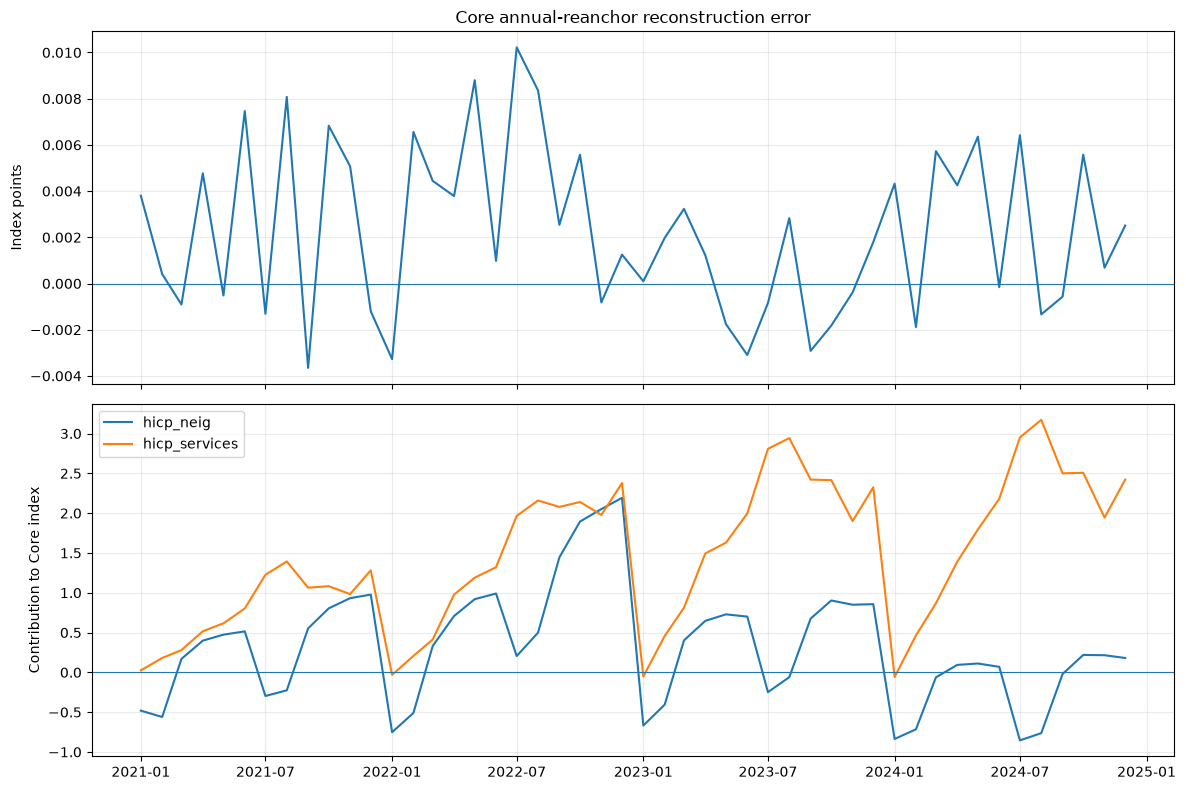

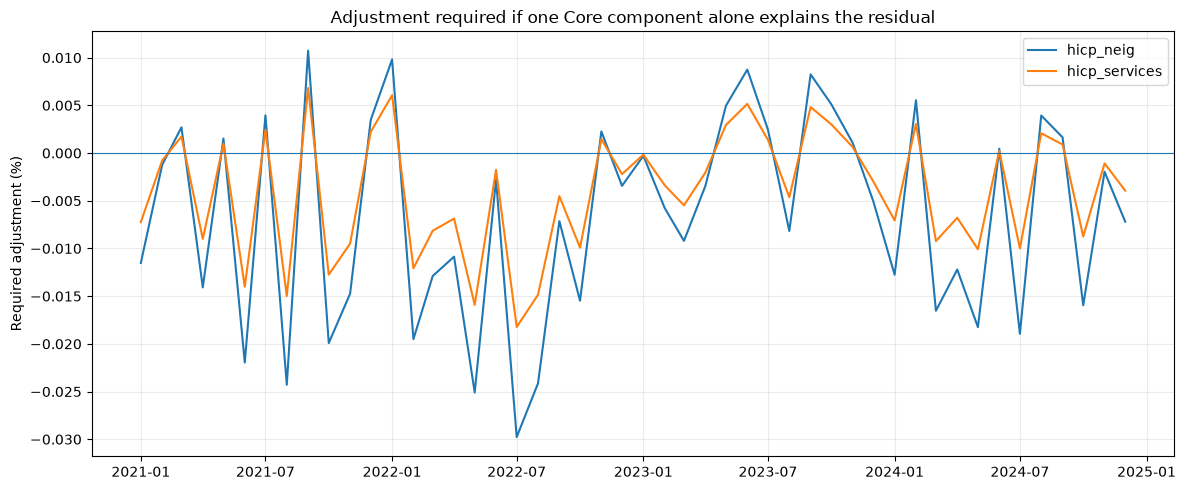

Largest absolute Core annual-reanchored error:
Date: 2022-07-01
Error: 0.010222 index points


,renormalised_weight,actual_index,required_index,required_adjustment_index,required_adjustment_pct,contribution_since_december
component,,,,,,
hicp_neig,0.386821,92.24,92.212541,-0.027459,-0.029769,0.204746
hicp_services,0.613179,89.58,89.563669,-0.016331,-0.018230,1.965476


,official,reconstructed,error,abs_error
date,,,,
2022-07-01,90.40,90.410222,0.010222,0.010222
2022-05-01,90.34,90.348798,0.008798,0.008798
2022-08-01,90.89,90.898356,0.008356,0.008356
2021-08-01,87.14,87.148076,0.008076,0.008076
2021-06-01,87.29,87.297465,0.007465,0.007465
2021-10-01,87.86,87.866828,0.006828,0.006828
2022-02-01,87.93,87.936558,0.006558,0.006558
2024-07-01,98.08,98.086417,0.006417,0.006417
2024-05-01,97.89,97.896357,0.006357,0.006357


In [14]:
# Component audit of the annual-reanchored Core reconstruction.
core_audit_rows = []
core_weights_norm = core_weight_table(weights)

for date in annual_reanchored_core.dropna().index:
    date = pd.Timestamp(date)
    year = int(date.year)
    dec_prev = pd.Timestamp(year=year - 1, month=12, day=1)

    if (
        year not in core_weights_norm.index
        or date not in core_native_levels.index
        or dec_prev not in core_native_levels.index
        or date not in official_core.index
        or dec_prev not in official_core.index
    ):
        continue

    w = core_weights_norm.loc[year, list(CORE_COMPONENTS)].astype(float)
    base = core_native_levels.loc[dec_prev, list(CORE_COMPONENTS)].astype(float)
    current = core_native_levels.loc[date, list(CORE_COMPONENTS)].astype(float)

    if (
        w.isna().any()
        or base.isna().any()
        or current.isna().any()
        or pd.isna(official_core.loc[date])
        or pd.isna(official_core.loc[dec_prev])
    ):
        continue

    anchor = float(official_core.loc[dec_prev])
    official = float(official_core.loc[date])
    ratio = current / base

    contribution = anchor * w * (ratio - 1.0)
    reconstructed = anchor * np.sum(w * ratio)
    residual = reconstructed - official

    row = {
        "date": date,
        "official": official,
        "reconstructed": reconstructed,
        "error": residual,
    }

    for comp in CORE_COMPONENTS:
        row[f"{comp}_contribution"] = float(contribution[comp])
        other = [name for name in CORE_COMPONENTS if name != comp]

        required_ratio = (
            official / anchor
            - np.sum(w[other] * ratio[other])
        ) / w[comp]
        required_index = float(base[comp] * required_ratio)

        row[f"{comp}_actual"] = float(current[comp])
        row[f"{comp}_required"] = required_index
        row[f"{comp}_required_adjustment"] = required_index - float(current[comp])
        row[f"{comp}_required_adjustment_pct"] = (
            100.0 * (required_index / float(current[comp]) - 1.0)
        )

    core_audit_rows.append(row)

core_component_audit = (
    pd.DataFrame(core_audit_rows)
    .set_index("date")
    .sort_index()
)

# Use the same stress window as the Headline component audit where available.
core_window = core_component_audit.loc["2021-01-01":"2024-12-01"].copy()
if core_window.empty:
    core_window = core_component_audit.copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(core_window.index, core_window["error"])
axes[0].axhline(0.0, linewidth=0.8)
axes[0].set_ylabel("Index points")
axes[0].set_title("Core annual-reanchor reconstruction error")
axes[0].grid(alpha=0.25)

for comp in CORE_COMPONENTS:
    axes[1].plot(
        core_window.index,
        core_window[f"{comp}_contribution"],
        label=comp,
    )
axes[1].axhline(0.0, linewidth=0.8)
axes[1].set_ylabel("Contribution to Core index")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 5))
for comp in CORE_COMPONENTS:
    ax.plot(
        core_window.index,
        core_window[f"{comp}_required_adjustment_pct"],
        label=comp,
    )
ax.axhline(0.0, linewidth=0.8)
ax.set_ylabel("Required adjustment (%)")
ax.set_title(
    "Adjustment required if one Core component alone explains the residual"
)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
display(fig)
plt.close(fig)

core_peak_date = core_window["error"].abs().idxmax()
print("Largest absolute Core annual-reanchored error:")
print("Date:", core_peak_date.date())
print("Error:", round(float(core_window.loc[core_peak_date, "error"]), 6), "index points")

core_peak_rows = []
for comp in CORE_COMPONENTS:
    core_peak_rows.append(
        {
            "component": comp,
            "renormalised_weight": float(
                core_weights_norm.loc[core_peak_date.year, comp]
            ),
            "actual_index": core_window.loc[
                core_peak_date, f"{comp}_actual"
            ],
            "required_index": core_window.loc[
                core_peak_date, f"{comp}_required"
            ],
            "required_adjustment_index": core_window.loc[
                core_peak_date, f"{comp}_required_adjustment"
            ],
            "required_adjustment_pct": core_window.loc[
                core_peak_date, f"{comp}_required_adjustment_pct"
            ],
            "contribution_since_december": core_window.loc[
                core_peak_date, f"{comp}_contribution"
            ],
        }
    )

display(
    pd.DataFrame(core_peak_rows)
    .set_index("component")
    .round(6)
)

display(
    core_window[["official", "reconstructed", "error"]]
    .assign(abs_error=lambda frame: frame["error"].abs())
    .sort_values("abs_error", ascending=False)
    .head(10)
    .round(6)
)


## 7. Bayesian prior and sampler configuration

In [15]:
display(pd.Series(asdict(PRIOR_CONFIG), name="value").to_frame())
display(pd.Series(asdict(SAMPLER_CONFIG), name="value").to_frame())

,value
lambda1,2.000000e-01
lambda2,5.000000e-01
lambda3,1.000000e+00
lambda4,1.000000e+01
a_prior_var,1.000000e+01
phi_prior_mean,2.000000e-02
phi_prior_df,1.000000e+01
h0_var,4.000000e+00
outlier_mean_frequency,2.083333e-02
outlier_prior_observations,1.200000e+02


,value
reps,6000
burn,3000
thin,1
seed,42
max_stability_tries,1000
progress_every,500
sv_sampler,centered_ksc
dk_projection_mode,strict
dk_level_relative_gate,0.000001
dk_difference_relative_gate,0.000001


## 8. Estimate the canonical dense BVAR(12) with monthly seasonal dummies

In [16]:
result_12 = run_headline_joint_bvar(
    native_levels,
    vintage=VINTAGE_USED,
    p=BASELINE_P,
    prior_config=PRIOR_CONFIG,
    sampler_config=SAMPLER_CONFIG,
    code_version="headline-joint-bvar12-seasonal-eurostat-food-v1",
)

result_12["headline_joint_context"]["hicp_food_source"] = dict(FOOD_SOURCE_METADATA)
result_12["metadata"]["hicp_food_source"] = dict(FOOD_SOURCE_METADATA)

print("Run ID:", result_12["metadata"]["run_id"])
print("Posterior draws:", result_12["n_draws"])
print("p:", result_12["p"])
print("active_lags:", result_12.get("active_lags"))
print("Balanced end:", result_12["prep"]["balanced_end"])
print("Last calendar date:", result_12["prep"]["last_calendar_date"])
print("Exogenous regressors:", result_12["prep"].get("exog_names"))

assert result_12["p"] == 12
assert result_12.get("active_lags") is None
assert len(result_12["prep"].get("exog_names", [])) == 11
assert result_12["metadata"]["seasonal_dummies"] is True


iteration 500/6,000 | B instability rejection 0.00% | radius 0.9722
iteration 1,000/6,000 | B instability rejection 0.00% | radius 0.9808
iteration 1,500/6,000 | B instability rejection 0.00% | radius 0.9809
iteration 2,000/6,000 | B instability rejection 0.00% | radius 0.9734
iteration 2,500/6,000 | B instability rejection 0.00% | radius 0.9766
iteration 3,000/6,000 | B instability rejection 0.00% | radius 0.9800
iteration 3,500/6,000 | B instability rejection 0.00% | radius 0.9724
iteration 4,000/6,000 | B instability rejection 0.00% | radius 0.9764
iteration 4,500/6,000 | B instability rejection 0.00% | radius 0.9847
iteration 5,000/6,000 | B instability rejection 0.00% | radius 0.9746
iteration 5,500/6,000 | B instability rejection 0.00% | radius 0.9807
iteration 6,000/6,000 | B instability rejection 0.00% | radius 0.9854
Run ID: 1988e62a5efe01098e1106e4cfb44d82d68183c9e8756debbaf5c2b99d691029
Posterior draws: 3000
p: 12
active_lags: None
Balanced end: 2026-07-01 00:00:00
Last cale

## 9. Posterior coefficients

,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
state__hicp_energy: const,0.00,0.17,-3.97 × 10⁻³,-3.93 × 10⁻³,3.42 × 10⁻³,-9.74 × 10⁻³,-7.33 × 10⁻³,-5.60 × 10⁻⁴,1.54 × 10⁻³,1411.78
state__hicp_energy: state__hicp_energy L1,0.00,0.20,0.37,0.37,0.06,0.28,0.32,0.43,0.47,2017.42
state__hicp_energy: state__hicp_food L1,0.00,0.52,0.18,0.19,0.26,-0.25,-0.07,0.43,0.60,1761.56
state__hicp_energy: state__hicp_neig L1,0.00,0.11,-5.12 × 10⁻³,-5.35 × 10⁻³,0.09,-0.15,-0.09,0.08,0.14,1917.66
state__hicp_energy: state__hicp_services L1,0.00,0.32,-0.09,-0.09,0.23,-0.49,-0.33,0.14,0.30,1488.53
state__hicp_energy: state__hicp_energy L2,0.00,0.10,-0.12,-0.12,0.05,-0.21,-0.17,-0.06,-0.03,1464.17
state__hicp_energy: state__hicp_food L2,0.00,0.26,0.12,0.12,0.20,-0.20,-0.07,0.32,0.44,2674.53
state__hicp_energy: state__hicp_neig L2,0.00,0.06,2.35 × 10⁻³,2.56 × 10⁻³,0.05,-0.09,-0.05,0.05,0.09,2368.25
state__hicp_energy: state__hicp_services L2,0.00,0.16,-5.44 × 10⁻³,-6.66 × 10⁻³,0.14,-0.24,-0.15,0.14,0.23,1968.48
state__hicp_energy: state__hicp_energy L3,0.00,0.07,8.55 × 10⁻⁵,3.95 × 10⁻⁴,0.04,-0.07,-0.04,0.04,0.07,2459.05


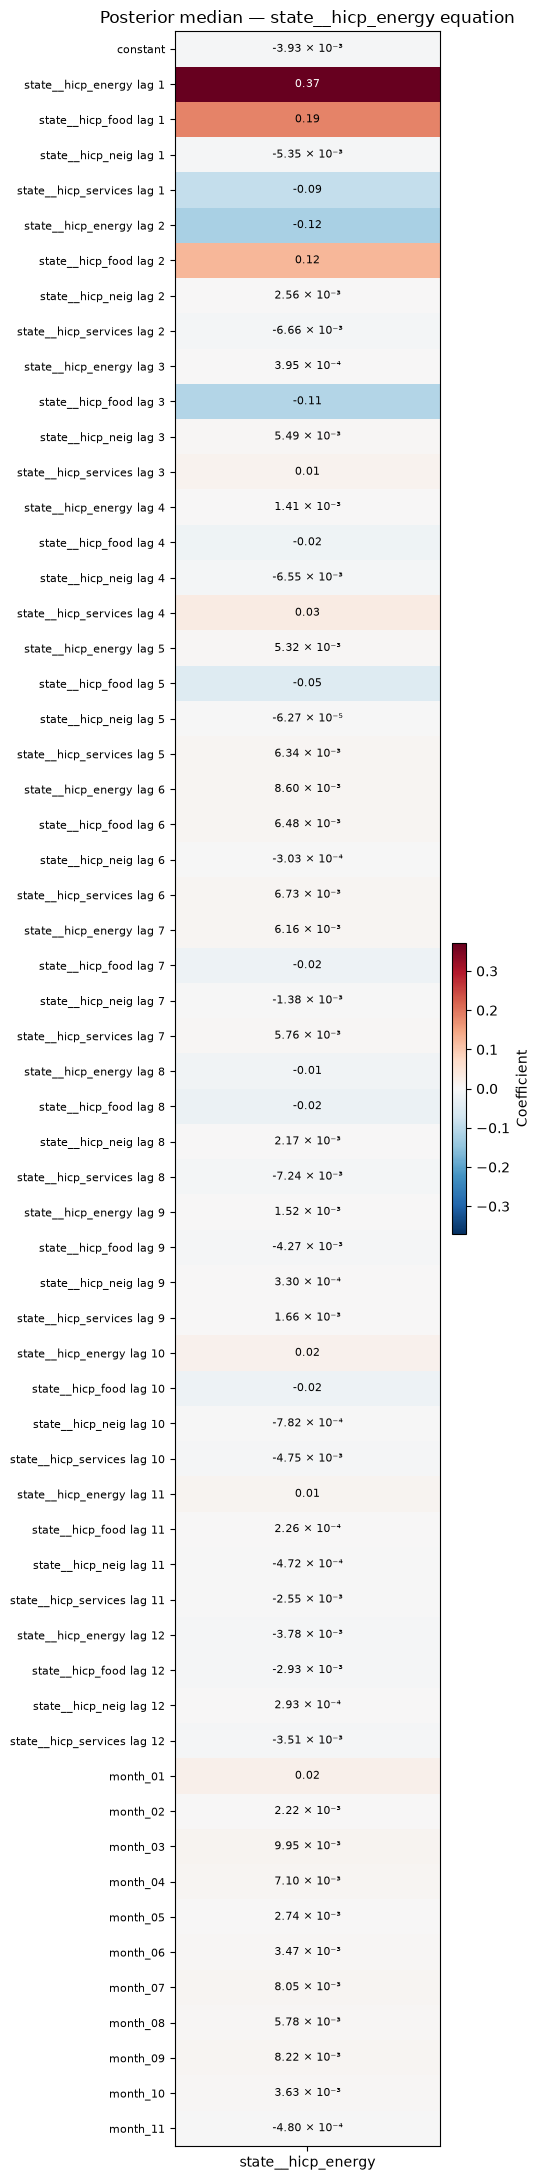

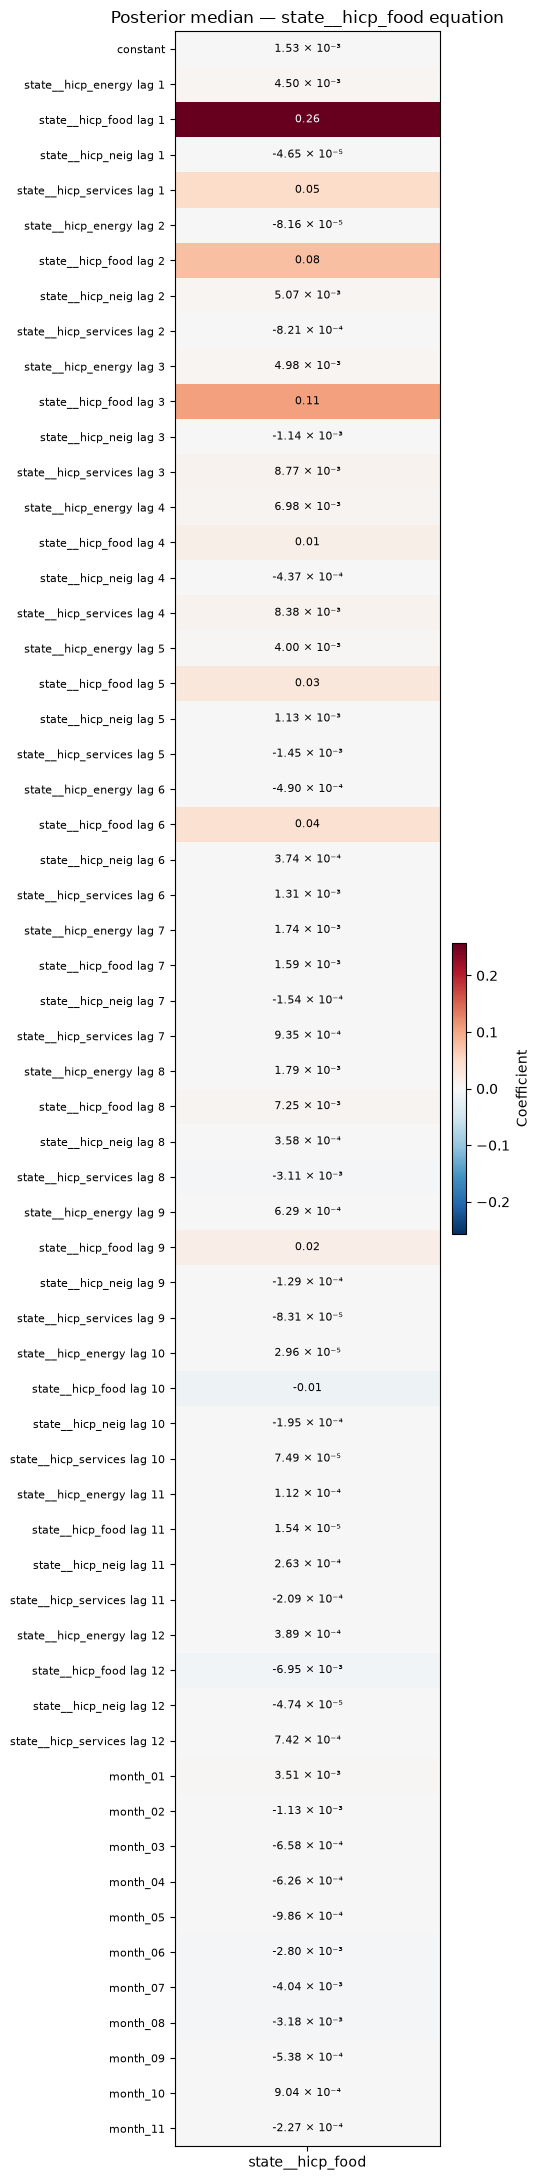

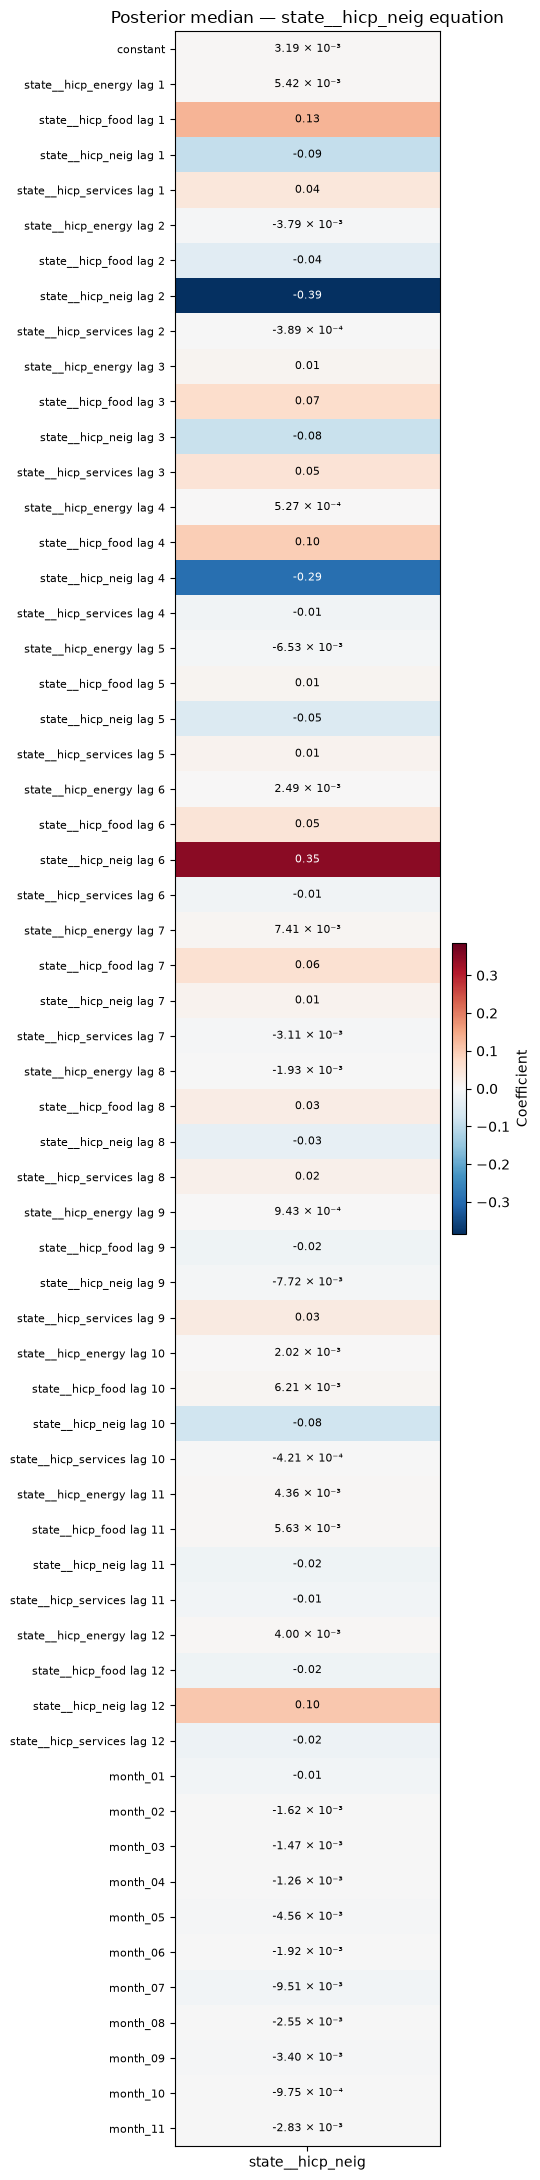

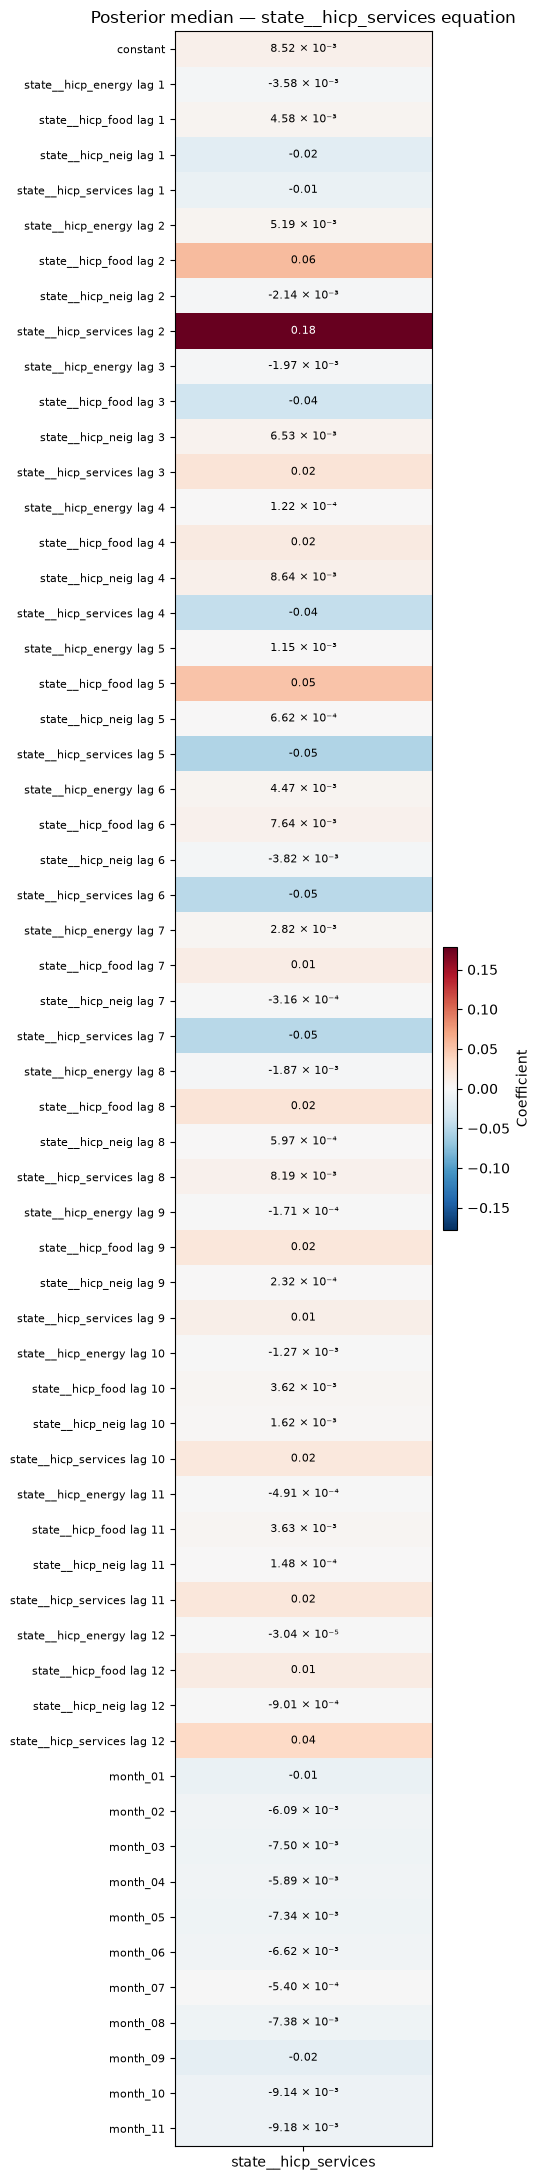

In [17]:
coef = coefficient_posterior_table(result_12)
display(style_numeric_table(coef, caption="Headline joint BVAR(12) posterior coefficients"))

for equation in result_12["variables"]:
    fig = plot_coefficient_heatmap(result_12, equation=equation)
    display(fig)
    plt.close(fig)

## 10. Stochastic volatility, outliers and residual diagnostics

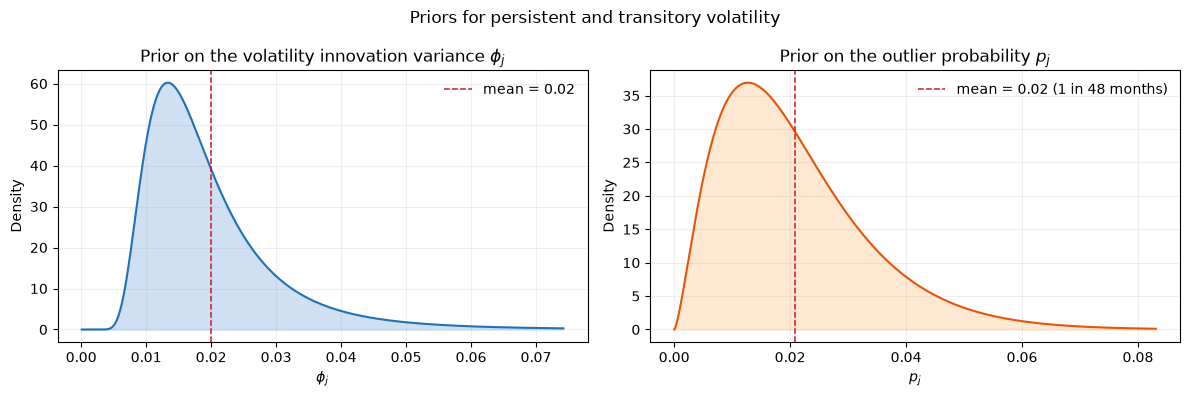

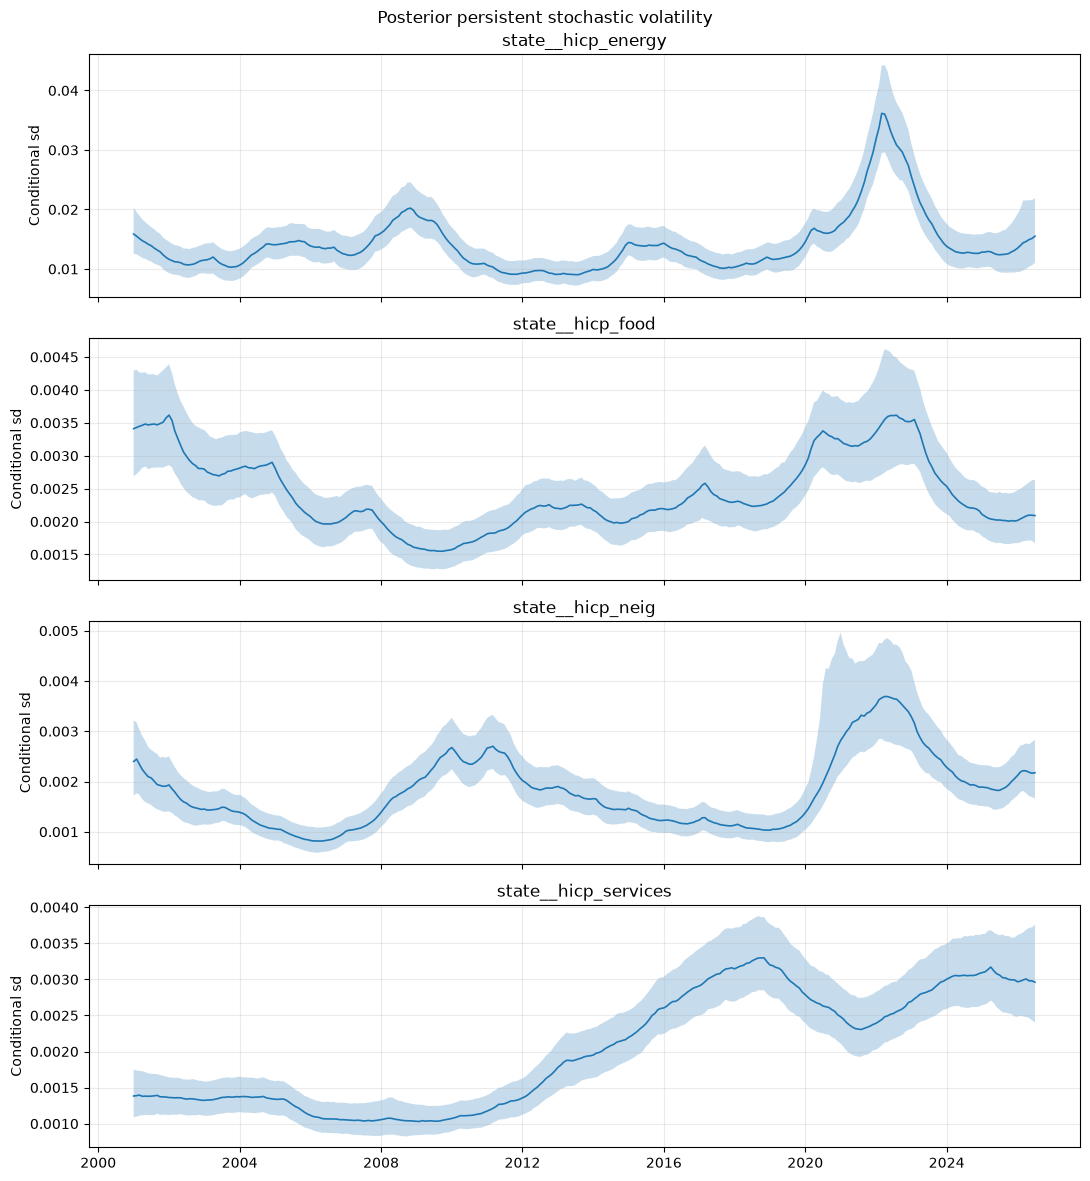

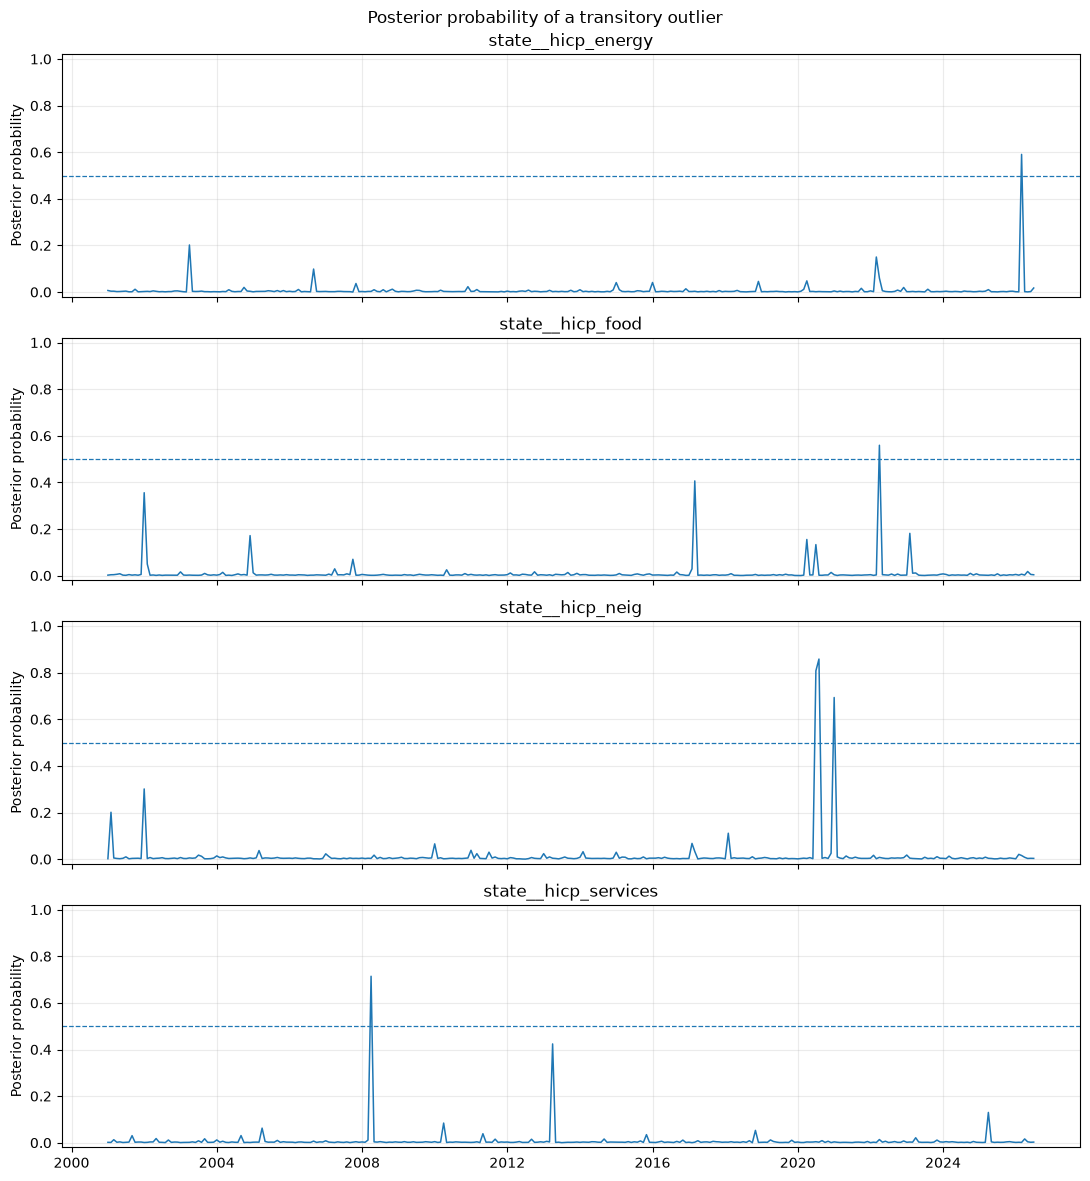

,mean,sd,skewness,excess_kurtosis,acf_1,maximum_absolute
variable,,,,,,
state__hicp_energy,-5.70 × 10⁻³,0.95,-0.18,0.21,0.04,2.83
state__hicp_food,0.02,0.97,0.14,0.59,-0.03,3.39
state__hicp_neig,0.06,0.91,-0.19,0.03,-0.07,2.97
state__hicp_services,-0.02,0.95,-0.28,0.43,-0.04,3.53


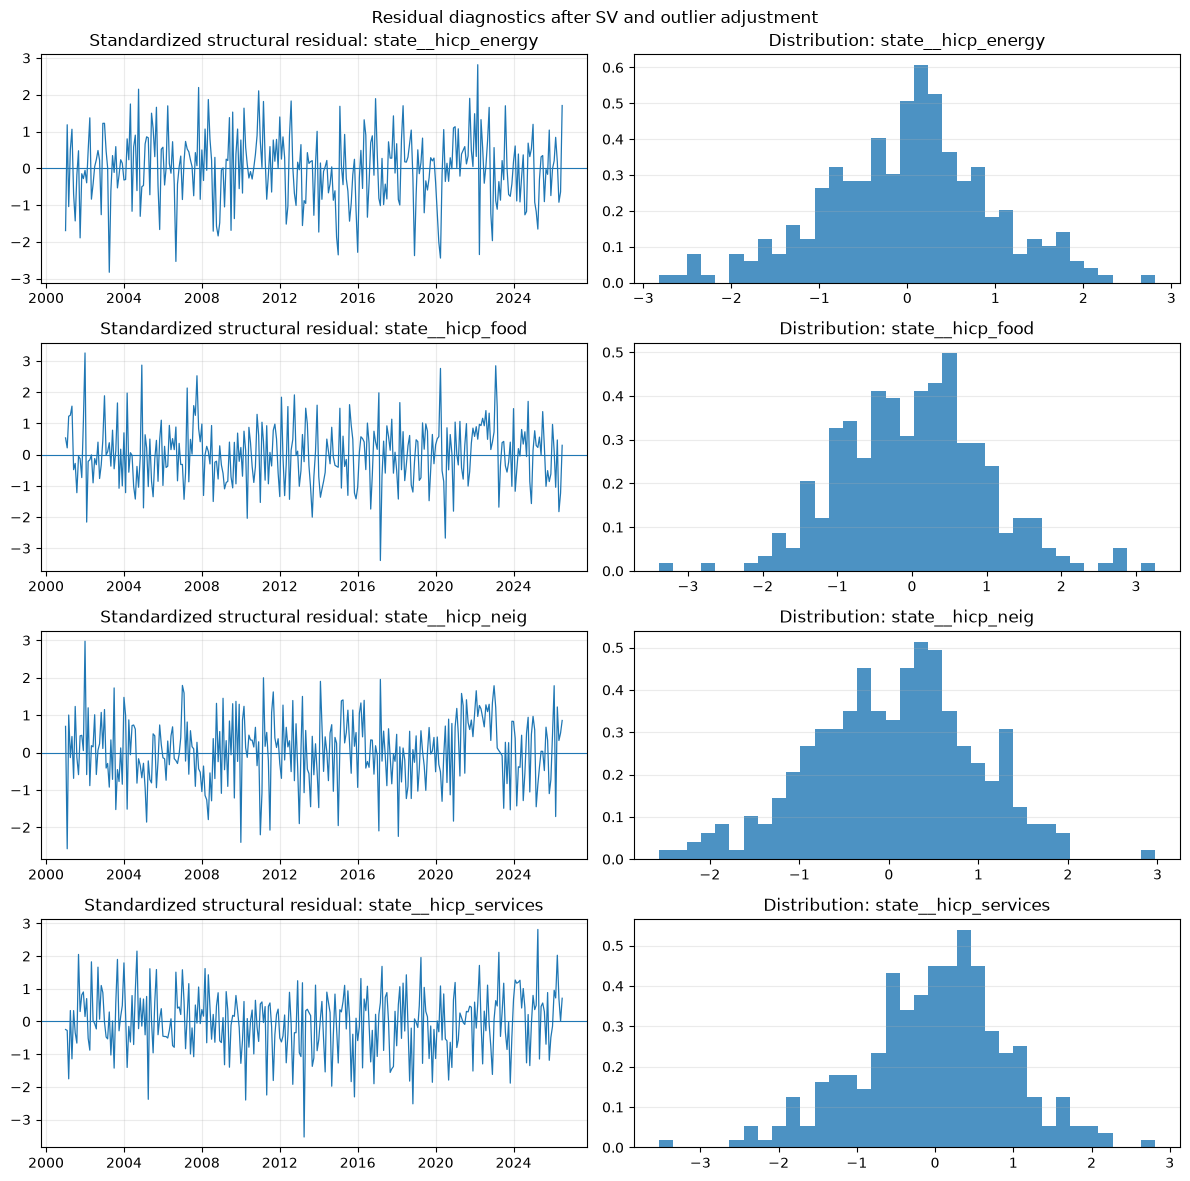

In [18]:
fig = plot_phi_and_outlier_priors(result_12["prior"])
display(fig)
plt.close(fig)

fig = plot_posterior_volatility(result_12, include_outliers=False)
display(fig)
plt.close(fig)

fig = plot_outlier_probabilities(result_12)
display(fig)
plt.close(fig)

residual_diag = residual_diagnostic_table(result_12)
display(style_numeric_table(residual_diag, caption="Standardised residual diagnostics"))

fig = plot_standardized_residuals(result_12)
display(fig)
plt.close(fig)

## 11. Joint component forecast

In [19]:
component_forecast = forecast_headline_joint_bvar(
    result_12,
    native_levels=native_levels,
    H=FORECAST_HORIZON,
    n_draws=min(FORECAST_DRAWS, result_12["n_draws"]),
    simulate_future_outliers=True,
    seed=2026,
)

print("Tail length:", component_forecast["tail_length"])
print("Future dates:", component_forecast["future_dates"][0], "→", component_forecast["future_dates"][-1])

print("Component HICP levels")
display(headline_component_forecast_table(component_forecast, kind="level"))

print("Component YoY inflation")
display(headline_component_forecast_table(component_forecast, kind="yoy"))

Tail length: 0
Future dates: 2026-08-01 00:00:00 → 2028-01-01 00:00:00
Component HICP levels


target_date         q05         q16         q50  \
months_ahead variable                                                        
1            hicp_energy    2026-08-01  107.720581  109.087420  110.879460   
             hicp_food      2026-08-01  101.144738  101.309784  101.551351   
             hicp_neig      2026-08-01   99.154203   99.348083   99.571294   
             hicp_services  2026-08-01  104.428681  104.670867  105.008015   
3            hicp_energy    2026-10-01  104.893269  108.141784  111.995907   
             hicp_food      2026-10-01  101.036667  101.383763  101.863909   
             hicp_neig      2026-10-01  101.261762  101.587639  101.958044   
             hicp_services  2026-10-01  103.227931  103.612547  104.241511   
6            hicp_energy    2027-01-01  101.636300  106.299055  112.463869   
             hicp_food      2027-01-01  101.465283  102.102934  102.963601   
             hicp_neig      2027-01-01   98.526301   98.971601   99.426256   
             hicp_services  2027-01-01  102.619056  103.412278  104.333938   
12           hicp_energy    2027-07-01   97.197047  104.920678  114.663557   
             hicp_food      2027-07-01  101.037375  102.174620  103.911730   
             hicp_neig      2027-07-01   98.223354   98.999004   99.771796   
             hicp_services  2027-07-01  104.288579  105.507936  106.962411   
18           hicp_energy    2028-01-01   91.428110  103.617091  116.267539   
             hicp_food      2028-01-01  100.749597  102.876304  105.323165   
             hicp_neig      2028-01-01   97.864839   98.938849  100.035393   
             hicp_services  2028-01-01  102.824884  104.807786  106.762880   

                                   q84         q95  
months_ahead variable                               
1            hicp_energy    112.526505  114.024870  
             hicp_food      101.781938  101.973732  
             hicp_neig       99.806443   99.976607  
             hicp_services  105.345253  105.589875  
3            hicp_energy    116.256163  120.089486  
             hicp_food      102.383057  102.793680  
             hicp_neig      102.353197  102.686367  
             hicp_services  104.849927  105.395235  
6            hicp_energy    119.387709  127.046290  
             hicp_food      103.968542  104.856837  
             hicp_neig       99.897253  100.434870  
             hicp_services  105.382684  106.169899  
12           hicp_energy    125.494765  138.080613  
             hicp_food      105.799421  107.372062  
             hicp_neig      100.605744  101.450288  
             hicp_services  108.508716  109.847342  
18           hicp_energy    131.070390  148.758589  
             hicp_food      108.097292  111.076999  
             hicp_neig      101.250592  102.540319  
             hicp_services  108.764467  110.931583

Component YoY inflation


target_date        q05        q16        q50  \
months_ahead variable                                                     
1            hicp_energy    2026-08-01   8.896665  10.278427  12.090032   
             hicp_food      2026-08-01   0.731738   0.896110   1.136690   
             hicp_neig      2026-08-01   0.643730   0.840523   1.067086   
             hicp_services  2026-08-01   2.612441   2.850414   3.181699   
3            hicp_energy    2026-10-01   6.285610   9.577246  13.482528   
             hicp_food      2026-10-01   0.523994   0.869330   1.347039   
             hicp_neig      2026-10-01   0.051143   0.373124   0.739101   
             hicp_services  2026-10-01   2.215993   2.596838   3.219636   
6            hicp_energy    2027-01-01   2.075223   6.758115  12.949552   
             hicp_food      2027-01-01   0.143390   0.772734   1.622188   
             hicp_neig      2027-01-01   0.057176   0.509395   0.971114   
             hicp_services  2027-01-01   2.088197   2.877316   3.794208   
12           hicp_energy    2027-07-01 -11.276087  -4.225762   4.667783   
             hicp_food      2027-07-01  -0.583120   0.535885   2.245134   
             hicp_neig      2027-07-01  -0.954569  -0.172427   0.606833   
             hicp_services  2027-07-01  -0.497491   0.665906   2.053632   
18           hicp_energy    2028-01-01 -14.132756  -5.634508   3.393327   
             hicp_food      2028-01-01  -1.495216   0.324668   2.350613   
             hicp_neig      2028-01-01  -1.294486  -0.322300   0.631083   
             hicp_services  2028-01-01  -0.763390   0.868480   2.279642   

                                  q84        q95  
months_ahead variable                             
1            hicp_energy    13.755059  15.269783  
             hicp_food       1.366336   1.557346  
             hicp_neig       1.305768   1.478489  
             hicp_services   3.513072   3.753440  
3            hicp_energy    17.799334  21.683540  
             hicp_food       1.863553   2.272092  
             hicp_neig       1.129529   1.458717  
             hicp_services   3.822089   4.362051  
6            hicp_energy    19.903294  27.594949  
             hicp_food       2.614037   3.490759  
             hicp_neig       1.449429   1.995400  
             hicp_services   4.837529   5.620671  
12           hicp_energy    14.554783  26.043462  
             hicp_food       4.102549   5.649967  
             hicp_neig       1.447760   2.299372  
             hicp_services   3.528973   4.806166  
18           hicp_energy    12.608815  24.884481  
             hicp_food       4.366681   6.690575  
             hicp_neig       1.642262   2.554105  
             hicp_services   3.740111   5.222241

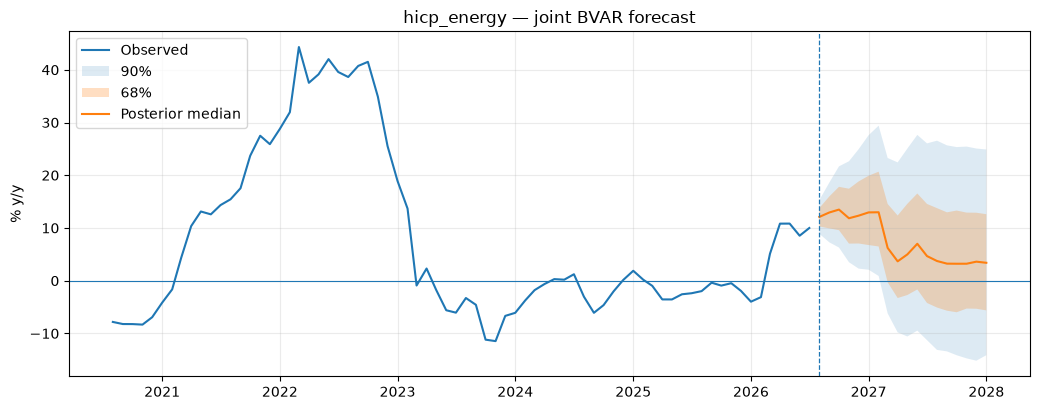

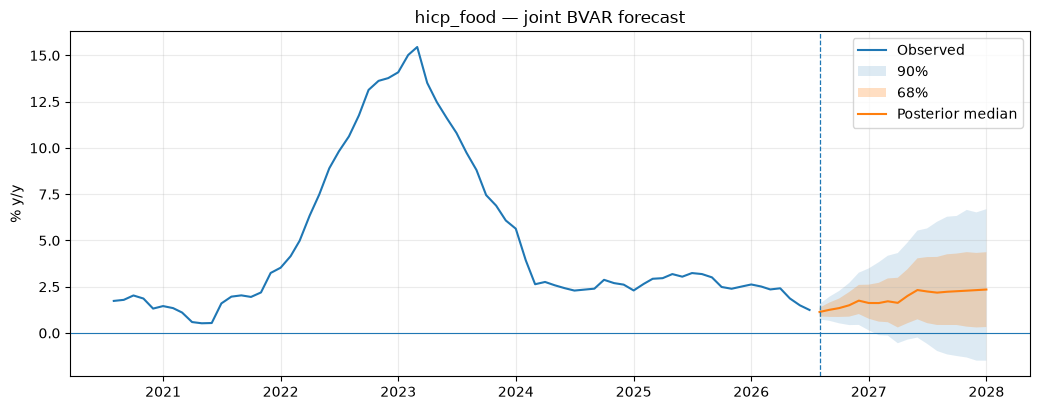

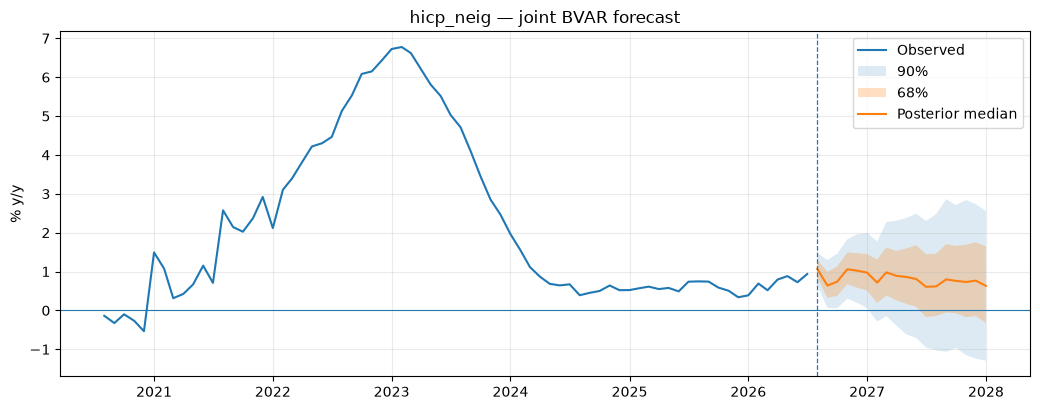

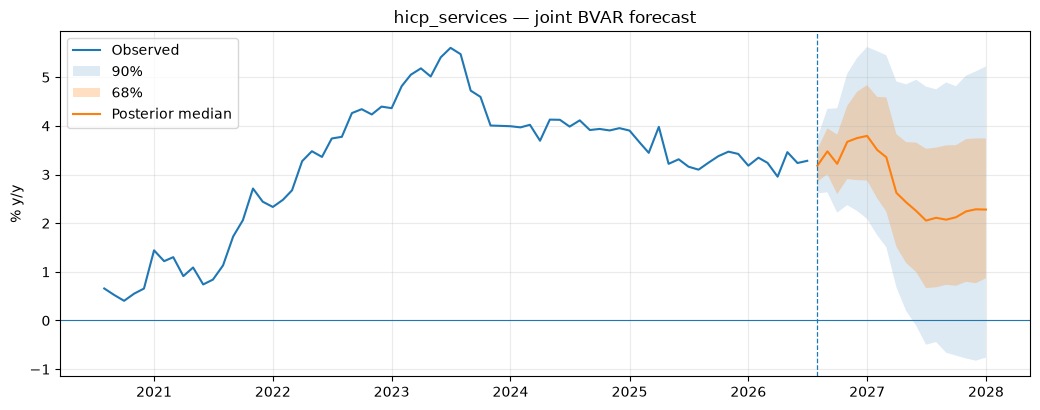

In [20]:
figures = plot_joint_component_forecast_fans(
    component_forecast,
    kind="yoy",
    history=native_levels,
    last_obs=72,
)
for fig in figures.values():
    display(fig)
    plt.close(fig)

## 12. Draw-by-draw Headline aggregation

In [21]:
headline_forecast = aggregate_headline_draws(
    component_forecast,
    native_levels=native_levels,
    weights=weights,
    official_total=official_total,
    future_weight_policy="carry_forward_latest",
)

print(
    "Max draw-wise contribution additivity error:",
    headline_forecast["headline_drawwise_additivity_max_abs_error"],
)

print("Headline HICP index")
display(headline_forecast_table(headline_forecast, kind="level"))

print("Headline YoY inflation")
display(headline_forecast_table(headline_forecast, kind="yoy"))

Max draw-wise contribution additivity error: 0.0
Headline HICP index


,target_date,q05,q16,q50,q84,q95
months_ahead,,,,,,
1,2026-08-01,103.085447,103.278863,103.523812,103.788555,103.983231
3,2026-10-01,102.985871,103.403319,103.913467,104.550253,105.044418
6,2027-01-01,101.992986,102.714429,103.607610,104.612365,105.563222
12,2027-07-01,102.560746,103.764314,105.350480,106.934246,108.730265
18,2028-01-01,101.768659,103.522366,105.711662,107.882610,110.360991


Headline YoY inflation


,target_date,q05,q16,q50,q84,q95
months_ahead,,,,,,
1,2026-08-01,2.644078,2.836665,3.080565,3.344175,3.538017
3,2026-10-01,2.229373,2.643755,3.150156,3.782264,4.272799
6,2027-01-01,1.921641,2.642579,3.535135,4.539188,5.489379
12,2027-07-01,-0.638688,0.527334,2.064019,3.598378,5.338370
18,2028-01-01,-1.193575,0.419431,2.002037,3.512342,5.145756


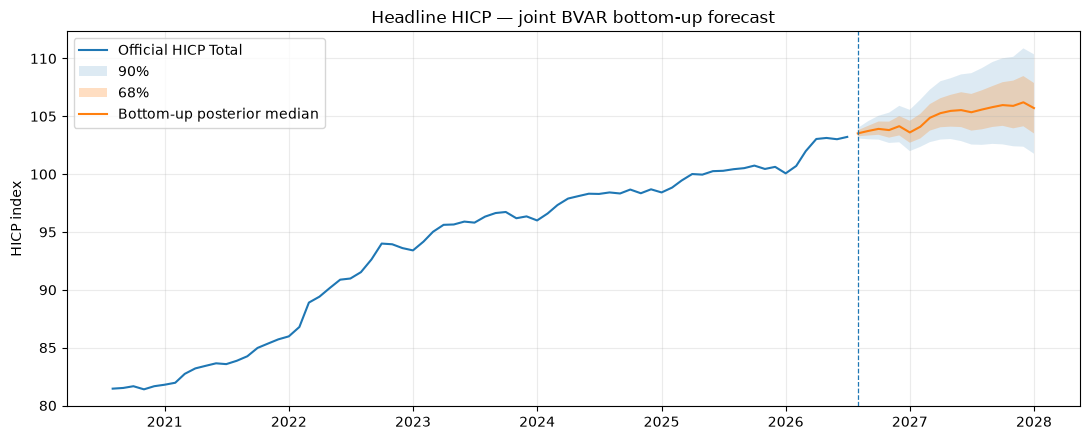

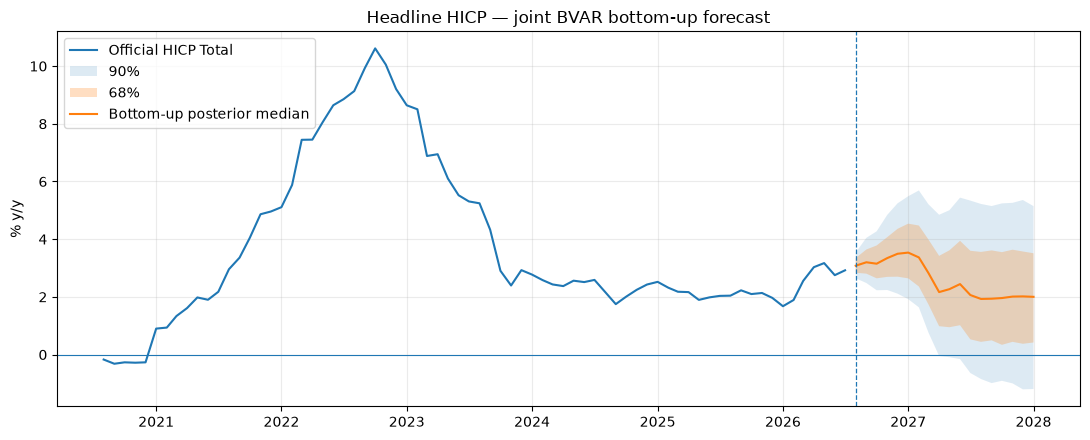

In [22]:
fig = plot_headline_aggregate_forecast(
    headline_forecast,
    official_total,
    kind="level",
)
display(fig)
plt.close(fig)

fig = plot_headline_aggregate_forecast(
    headline_forecast,
    official_total,
    kind="yoy",
)
display(fig)
plt.close(fig)

Forecast aggregation uses published annual weights; beyond the latest published year it carries forward the latest complete vector. Aggregation is done on component index paths.


## 13. MCMC and stability diagnostics

,posterior_mean,posterior_sd,ESS,MCSE_mean,MCSE_over_sd
log likelihood,5302.56,20.81,161.22,1.64,0.08
spectral radius,0.98,4.54 × 10⁻³,395.42,2.28 × 10⁻⁴,0.05
"A[state__hicp_food,state__hicp_energy]",-0.02,9.95 × 10⁻³,758.38,3.61 × 10⁻⁴,0.04
phi[state__hicp_energy],0.04,0.02,40.63,3.80 × 10⁻³,0.16
p_outlier[state__hicp_energy],0.01,6.48 × 10⁻³,511.11,2.86 × 10⁻⁴,0.04
own L1[state__hicp_energy],0.37,0.06,2017.42,1.27 × 10⁻³,0.02
phi[state__hicp_food],0.02,9.48 × 10⁻³,50.41,1.33 × 10⁻³,0.14
p_outlier[state__hicp_food],0.01,7.78 × 10⁻³,398.32,3.90 × 10⁻⁴,0.05
own L1[state__hicp_food],0.26,0.06,1044.01,1.86 × 10⁻³,0.03
phi[state__hicp_neig],0.04,0.02,21.80,4.74 × 10⁻³,0.21


,value
retained_draws,3000.000000
median_spectral_radius,0.975402
q95_spectral_radius,0.982313
maximum_spectral_radius,0.988473
retained_unstable_share,0.000000
B_total_proposals,6000.000000
B_unstable_proposals,0.000000
B_instability_rejection_rate,0.000000


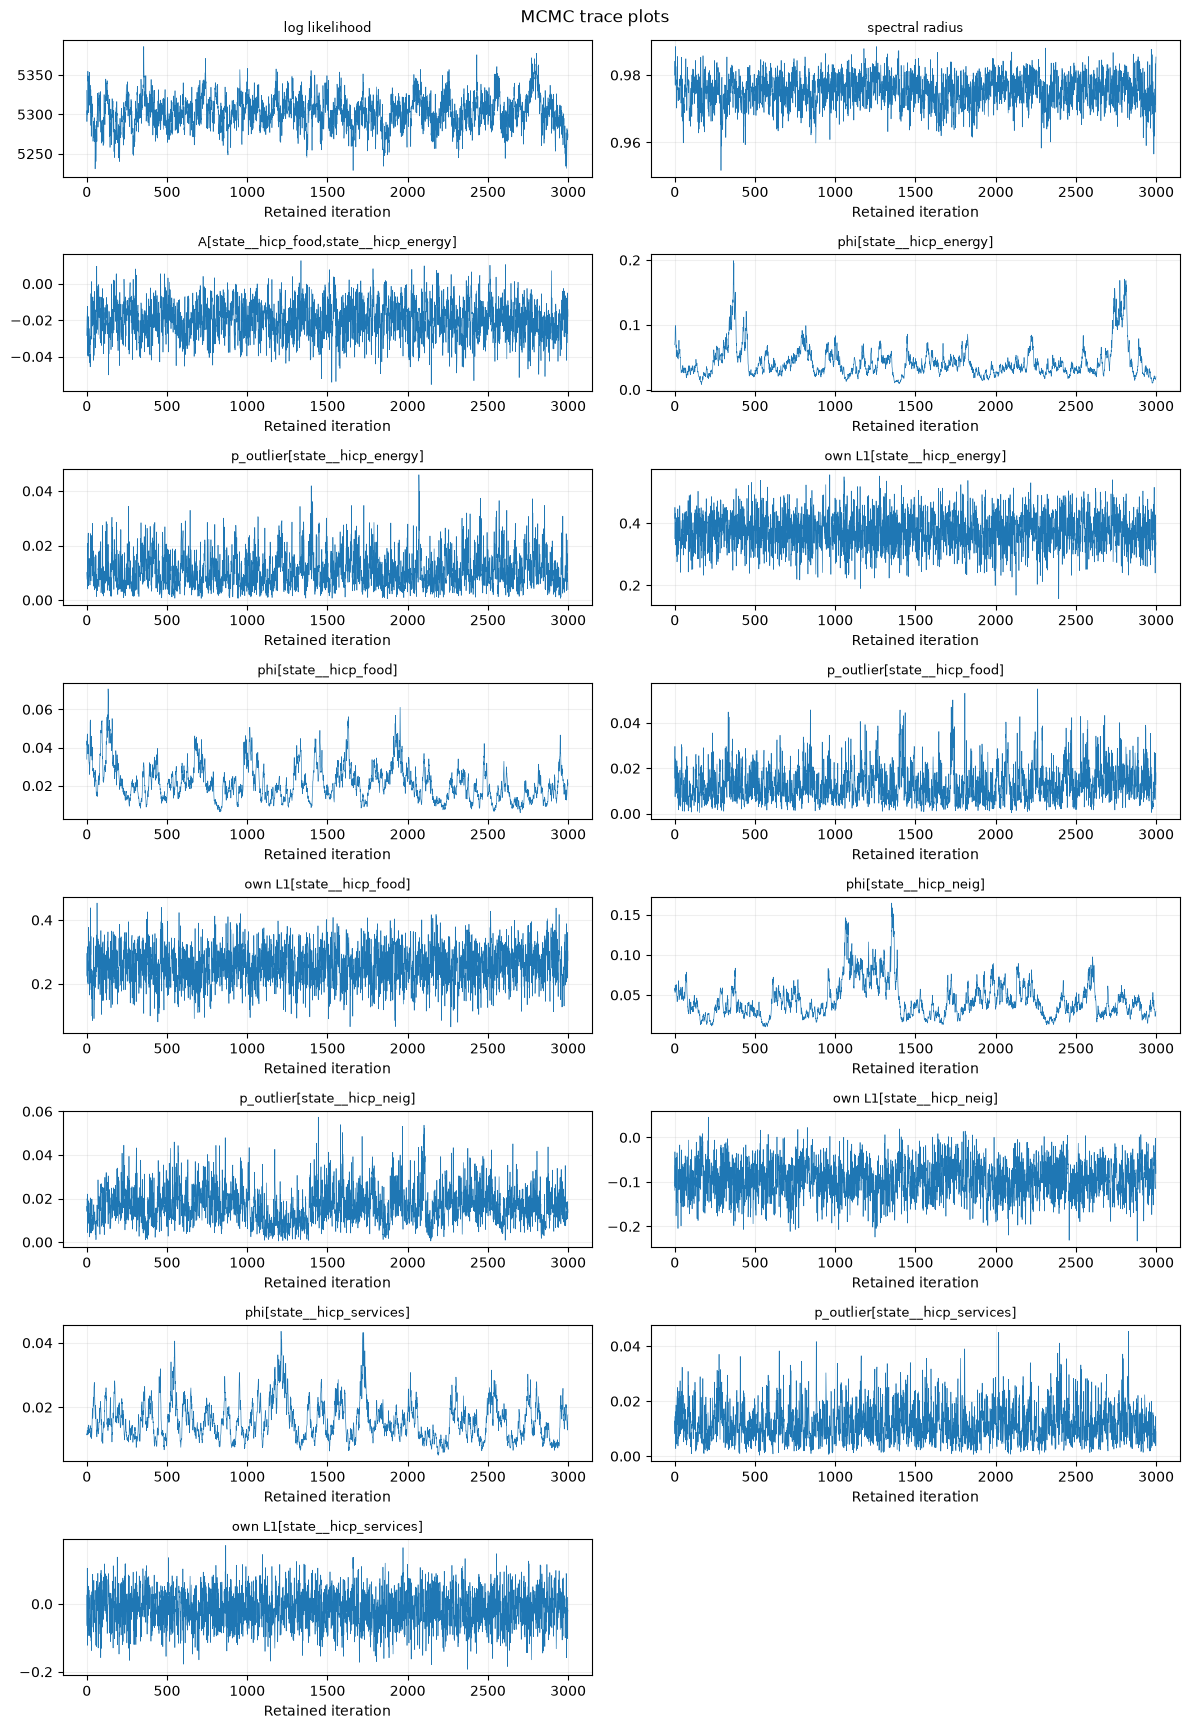

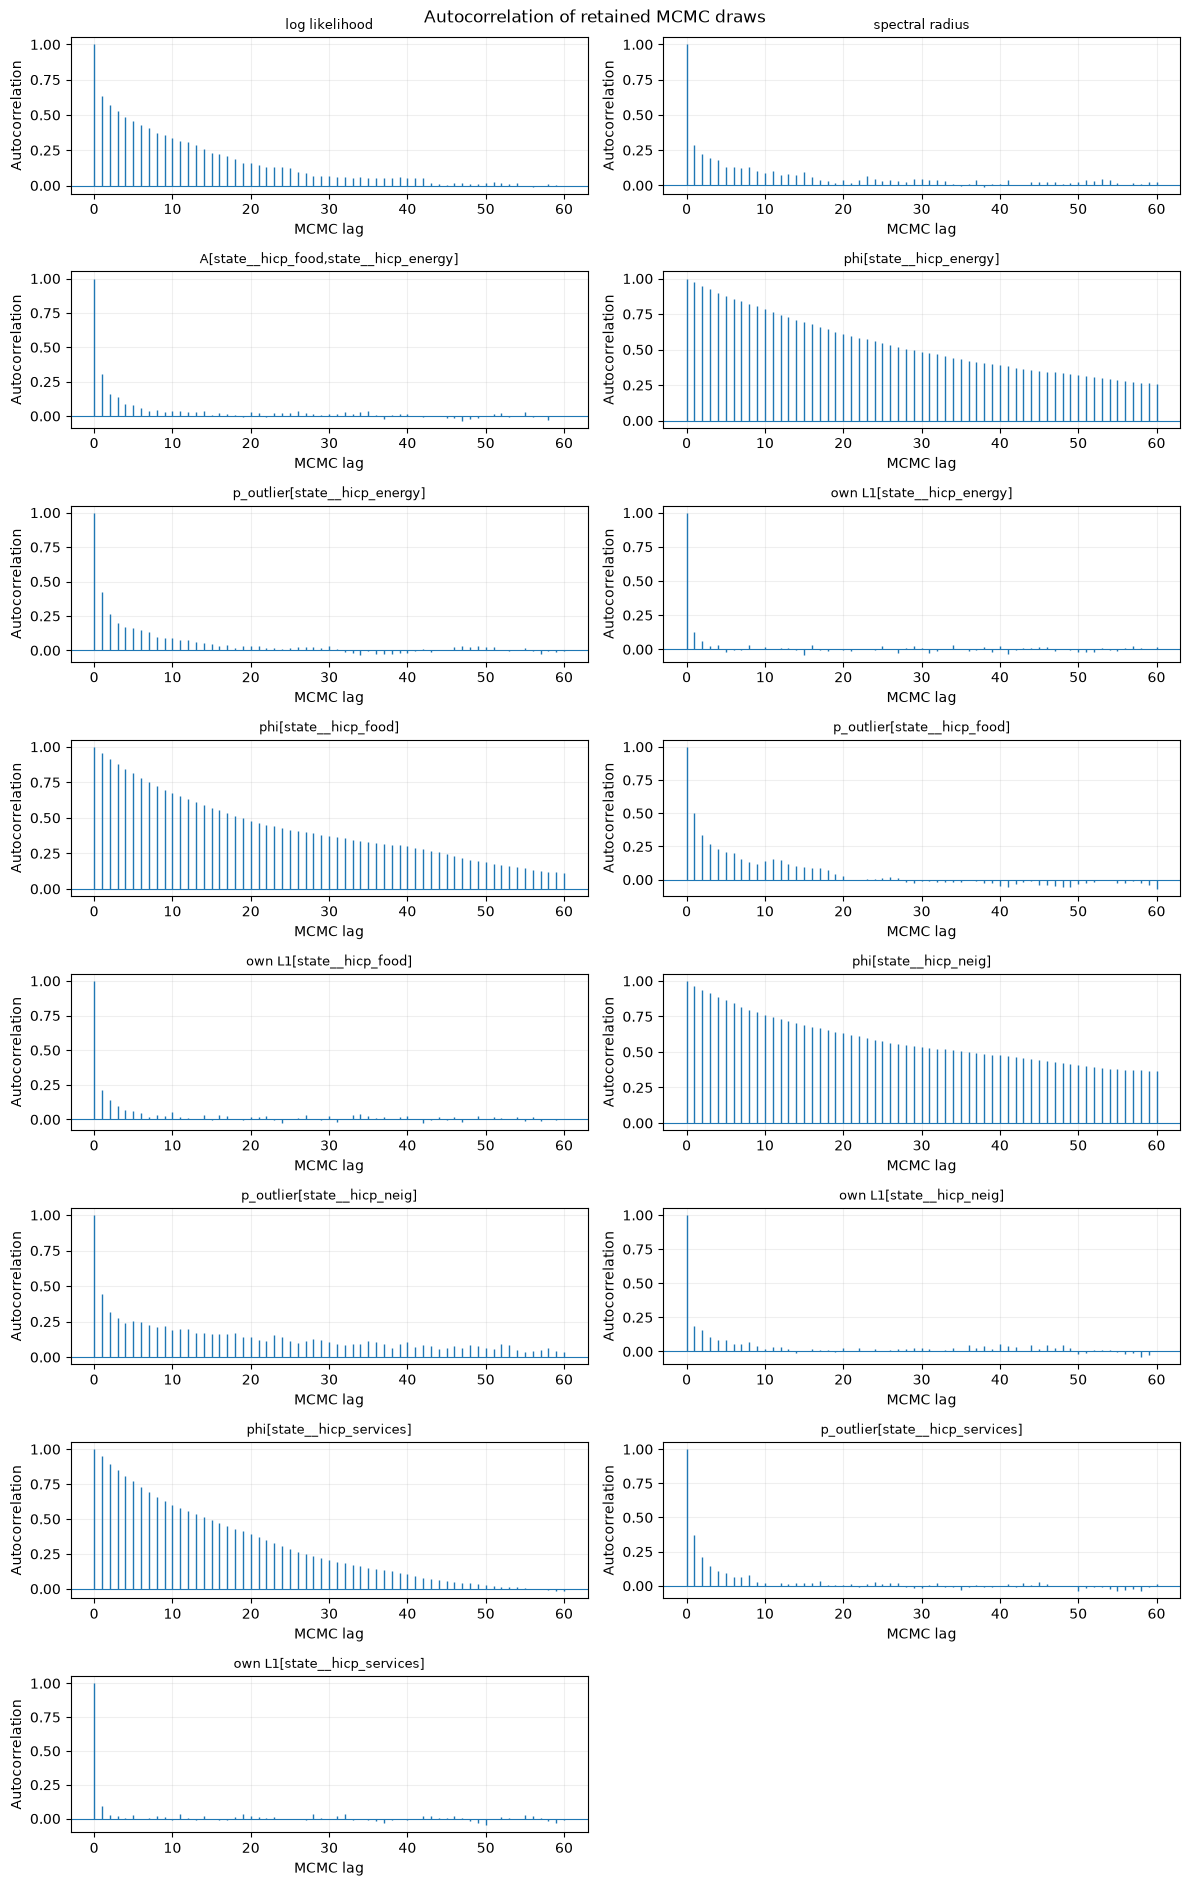

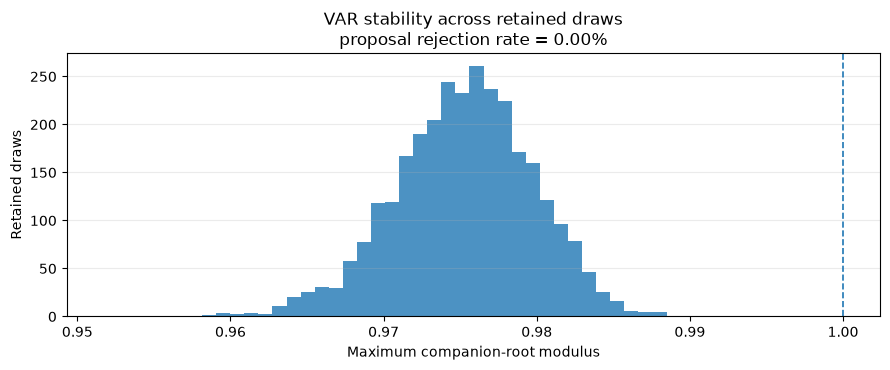

In [23]:
display(style_numeric_table(mcmc_diagnostics(result_12), caption="MCMC diagnostics"))
display(stability_diagnostics(result_12).to_frame("value"))

fig = plot_trace_grid(result_12)
display(fig)
plt.close(fig)

fig = plot_chain_acf_grid(result_12)
display(fig)
plt.close(fig)

fig = plot_spectral_radius(result_12)
display(fig)
plt.close(fig)

## 14. Stationarity diagnostics after deterministic seasonality control

In [24]:
raw_changes = state_levels.diff().dropna()
seasonals_for_changes = seasonal_exog.reindex(raw_changes.index)
X_seasonal = np.column_stack(
    [np.ones(len(raw_changes)), seasonals_for_changes.to_numpy(dtype=float)]
)
residualised = pd.DataFrame(index=raw_changes.index, columns=raw_changes.columns, dtype=float)
for name in raw_changes.columns:
    y = raw_changes[name].to_numpy(dtype=float)
    beta, *_ = np.linalg.lstsq(X_seasonal, y, rcond=None)
    residualised[name] = y - X_seasonal @ beta

display(stationarity_tests(raw_changes))
display(stationarity_tests(residualised))


,ADF statistic,ADF p-value,ADF lags,KPSS statistic,KPSS p-value,KPSS lags,observations
variable,,,,,,,
state__hicp_energy,-13.333360,6.120533e-25,0,0.060494,0.100000,5,318
state__hicp_food,-4.864303,4.090529e-05,17,0.203206,0.100000,9,301
state__hicp_neig,-2.719082,7.079401e-02,11,0.097689,0.100000,43,307
state__hicp_services,-1.801365,3.797844e-01,14,0.455603,0.053188,10,304


,ADF statistic,ADF p-value,ADF lags,KPSS statistic,KPSS p-value,KPSS lags,observations
variable,,,,,,,
state__hicp_energy,-12.938496,3.575723e-24,0,0.057594,0.100000,6,318
state__hicp_food,-4.203067,6.510678e-04,12,0.212581,0.100000,9,306
state__hicp_neig,-3.522260,7.433468e-03,13,0.180618,0.100000,45,305
state__hicp_services,-1.703297,4.294145e-01,13,0.444715,0.057881,7,305


## 14. Posterior seasonal roots

Companion roots are computed draw by draw and grouped by frequency. Deterministic/exogenous rows are excluded by coefficient name, not by row position.


In [25]:
def _B_draws_as_k_by_n(result: Mapping) -> np.ndarray:
    B = np.asarray(result["B"], dtype=float)
    if B.ndim != 3:
        raise ValueError(f"Expected result['B'] to be 3-D, found {B.shape}.")

    n = len(result["variables"])
    p = int(result["p"])
    if B.shape[2] == n and B.shape[1] >= 1 + n * p:
        return B
    if B.shape[1] == n and B.shape[2] >= 1 + n * p:
        return np.swapaxes(B, 1, 2)
    raise ValueError(f"Cannot infer coefficient orientation from {B.shape}.")


def _coefficient_row_names(result: Mapping) -> list[str]:
    B = _B_draws_as_k_by_n(result)
    k = B.shape[1]
    labels = list(result["prior"]["coefficient_labels"])
    first_equation = str(result["variables"][0])
    prefix = f"{first_equation}: "
    if len(labels) != k * len(result["variables"]):
        raise ValueError("Coefficient labels do not match B dimensions.")
    rows = labels[:k]
    if not all(label.startswith(prefix) for label in rows):
        raise ValueError("Cannot recover coefficient-row names from prior labels.")
    return [label[len(prefix):] for label in rows]


def _lag_row_indices(result: Mapping) -> list[list[int]]:
    row_names = _coefficient_row_names(result)
    lookup = {name: i for i, name in enumerate(row_names)}
    variables = list(result["variables"])
    p = int(result["p"])
    return [
        [lookup[f"{variable} L{lag}"] for variable in variables]
        for lag in range(1, p + 1)
    ]


def _companion_from_Bkn(Bkn: np.ndarray, *, result: Mapping) -> np.ndarray:
    n = len(result["variables"])
    p = int(result["p"])
    lag_rows = _lag_row_indices(result)

    lag_matrices = [Bkn[rows, :].T for rows in lag_rows]
    companion = np.zeros((n * p, n * p), dtype=float)
    companion[:n, :] = np.hstack(lag_matrices)
    if p > 1:
        companion[n:, :-n] = np.eye(n * (p - 1))
    return companion


def _root_frequency_summary(
    result: Mapping,
    *,
    n_draws: int,
    angle_tolerance: float,
    thresholds: Sequence[float],
) -> tuple[pd.DataFrame, pd.DataFrame, np.ndarray]:
    B = _B_draws_as_k_by_n(result)
    keep = min(int(n_draws), B.shape[0])
    draw_idx = np.linspace(0, B.shape[0] - 1, keep, dtype=int)

    targets = [
        ("zero", np.inf, 0.0),
        ("12m", 12.0, np.pi / 6.0),
        ("6m", 6.0, np.pi / 3.0),
        ("4m", 4.0, np.pi / 2.0),
        ("3m", 3.0, 2.0 * np.pi / 3.0),
        ("2.4m", 2.4, 5.0 * np.pi / 6.0),
        ("2m", 2.0, np.pi),
    ]

    rows = []
    eig_store = []
    for original_idx in draw_idx:
        eigvals = np.linalg.eigvals(
            _companion_from_Bkn(B[original_idx], result=result)
        )
        eig_store.append(eigvals)
        modulus = np.abs(eigvals)
        angle = np.abs(np.angle(eigvals))

        row = {"draw_index": int(original_idx)}
        for label, _, target_angle in targets:
            mask = np.abs(angle - target_angle) <= float(angle_tolerance)
            row[label] = float(np.max(modulus[mask])) if np.any(mask) else np.nan
        rows.append(row)

    root_by_draw = pd.DataFrame(rows).set_index("draw_index")
    eig_store = np.asarray(eig_store)

    summary = []
    for label, period, _ in targets:
        values = root_by_draw[label].dropna().to_numpy(dtype=float)
        row = {
            "frequency": label,
            "period_months": period,
            "q05": np.quantile(values, 0.05) if len(values) else np.nan,
            "median": np.median(values) if len(values) else np.nan,
            "q95": np.quantile(values, 0.95) if len(values) else np.nan,
        }
        for threshold in thresholds:
            row[f"P(|lambda|>{threshold:.2f})"] = (
                float(np.mean(values > threshold)) if len(values) else np.nan
            )
        summary.append(row)

    return pd.DataFrame(summary).set_index("frequency"), root_by_draw, eig_store


root_frequency_summary, root_modulus_by_draw, posterior_eigenvalues = _root_frequency_summary(
    result_12,
    n_draws=SEASONAL_ROOT_DIAGNOSTIC_DRAWS,
    angle_tolerance=SEASONAL_ROOT_ANGLE_TOLERANCE,
    thresholds=SEASONAL_ROOT_MODULUS_THRESHOLDS,
)
display(style_numeric_table(root_frequency_summary, caption="Posterior roots by frequency"))

used = root_modulus_by_draw.index.to_numpy(dtype=int)
rebuilt_radius = np.max(np.abs(posterior_eigenvalues), axis=1)
stored_radius = np.asarray(result_12["spectral_radius"], dtype=float)[used]
root_radius_max_abs_error = float(np.max(np.abs(rebuilt_radius - stored_radius)))
print("Companion radius max |error|:", root_radius_max_abs_error)
if root_radius_max_abs_error > 1e-10:
    raise AssertionError("Companion reconstruction does not match stored spectral radius.")


,period_months,q05,median,q95,P(|lambda|>0.90),P(|lambda|>0.95),P(|lambda|>0.97)
frequency,,,,,,,
zero,inf,0.77,0.83,0.89,0.02,0.00,0.00
12m,12.00,0.80,0.84,0.88,1.00 × 10⁻³,0.00,0.00
6m,6.00,0.97,0.98,0.98,1.00,1.00,0.83
4m,4.00,0.76,0.79,0.81,0.00,0.00,0.00
3m,3.00,0.96,0.97,0.98,1.00,1.00,0.45
2.4m,2.40,0.74,0.77,0.80,0.00,0.00,0.00
2m,2.00,0.78,0.82,0.85,0.00,0.00,0.00


Companion radius max |error|: 0.0


## 15. Seasonal break tests

Auxiliary OLS tests on monthly log changes. The 11 post-break month interactions are tested jointly for breaks in 2015 and 2020. The BVAR is not re-estimated here.


In [26]:
def _seasonal_break_test(
    series: pd.Series,
    break_date: pd.Timestamp,
) -> tuple[dict[str, object], pd.DataFrame]:
    y = series.dropna().astype(float)
    if (y.index < break_date).sum() < 24 or (y.index >= break_date).sum() < 24:
        raise ValueError(f"Insufficient observations around break {break_date.date()}.")

    months = make_joint_seasonals(y.index).astype(float)
    post = pd.Series((y.index >= break_date).astype(float), index=y.index, name="post")
    interactions = months.mul(post, axis=0)
    interactions.columns = [f"post_x_{name}" for name in months.columns]

    X = pd.concat(
        [
            pd.Series(1.0, index=y.index, name="const"),
            months,
            post,
            interactions,
        ],
        axis=1,
    )
    fit = sm.OLS(y, X).fit()

    interaction_names = list(interactions.columns)
    R = np.zeros((len(interaction_names), X.shape[1]), dtype=float)
    for r, name in enumerate(interaction_names):
        R[r, X.columns.get_loc(name)] = 1.0
    joint = fit.f_test(R)

    summary = {
        "component": series.name,
        "break_date": break_date,
        "n_obs": int(fit.nobs),
        "F": float(np.asarray(joint.fvalue).squeeze()),
        "df_num": float(joint.df_num),
        "df_denom": float(joint.df_denom),
        "p_value": float(np.asarray(joint.pvalue).squeeze()),
    }

    detail = pd.DataFrame(
        {
            "component": series.name,
            "break_date": break_date,
            "month": [name.replace("post_x_", "") for name in interaction_names],
            "effect_pp": fit.params[interaction_names].to_numpy(dtype=float),
            "t_stat": fit.tvalues[interaction_names].to_numpy(dtype=float),
            "p_value": fit.pvalues[interaction_names].to_numpy(dtype=float),
        }
    )
    return summary, detail


break_rows = []
break_details = []
for name in model_changes.columns:
    for break_date in SEASONAL_BREAK_DATES:
        summary, detail = _seasonal_break_test(model_changes[name], break_date)
        break_rows.append(summary)
        break_details.append(detail)

seasonal_break_tests = pd.DataFrame(break_rows)
seasonal_break_tests["reject_5pct"] = seasonal_break_tests["p_value"] < 0.05
seasonal_break_tests = seasonal_break_tests.set_index(["component", "break_date"])
display(style_numeric_table(seasonal_break_tests, caption="Joint F-tests: seasonal pattern breaks"))

seasonal_break_months = pd.concat(break_details, ignore_index=True)
significant_month_shifts = seasonal_break_months.loc[
    seasonal_break_months["p_value"] < 0.05
].sort_values(["component", "break_date", "p_value"])

if significant_month_shifts.empty:
    print("No individual month interaction has p < 0.05.")
else:
    display(significant_month_shifts)


,component,break_date,month,effect_pp,t_stat,p_value
20,state__hicp_energy,2020-01-01,month_10,2.269147,1.978594,4.879168e-02
29,state__hicp_food,2015-01-01,month_08,0.593837,3.290584,1.121132e-03
23,state__hicp_food,2015-01-01,month_02,0.502585,2.819026,5.142863e-03
25,state__hicp_food,2015-01-01,month_04,0.426854,2.394246,1.727880e-02
31,state__hicp_food,2015-01-01,month_10,0.408475,2.263450,2.433444e-02
28,state__hicp_food,2015-01-01,month_07,0.395319,2.217367,2.736007e-02
36,state__hicp_food,2020-01-01,month_04,0.591829,2.940601,3.535055e-03
40,state__hicp_food,2020-01-01,month_08,0.507886,2.453210,1.473735e-02
34,state__hicp_food,2020-01-01,month_02,0.492496,2.447046,1.498655e-02
42,state__hicp_food,2020-01-01,month_10,0.447502,2.161539,3.145790e-02


## 17. Posterior predictive checks

,observed,replicated_median,replicated_q05,replicated_q95
state__hicp_energy: mean,2.97 × 10⁻³,2.42 × 10⁻³,-4.02 × 10⁻⁴,5.62 × 10⁻³
state__hicp_energy: sd,0.02,0.02,0.02,0.03
state__hicp_energy: maximum_absolute,0.11,0.12,0.06,0.37
state__hicp_food: mean,2.32 × 10⁻³,1.87 × 10⁻³,9.24 × 10⁻⁴,2.87 × 10⁻³
state__hicp_food: sd,3.84 × 10⁻³,4.02 × 10⁻³,3.33 × 10⁻³,6.97 × 10⁻³
state__hicp_food: maximum_absolute,0.02,0.03,0.01,0.08
state__hicp_neig: mean,7.30 × 10⁻⁴,4.27 × 10⁻⁴,6.42 × 10⁻⁵,8.18 × 10⁻⁴
state__hicp_neig: sd,0.02,0.02,0.01,0.02
state__hicp_neig: maximum_absolute,0.04,0.04,0.03,0.09
state__hicp_services: mean,1.88 × 10⁻³,1.79 × 10⁻³,1.30 × 10⁻³,2.24 × 10⁻³


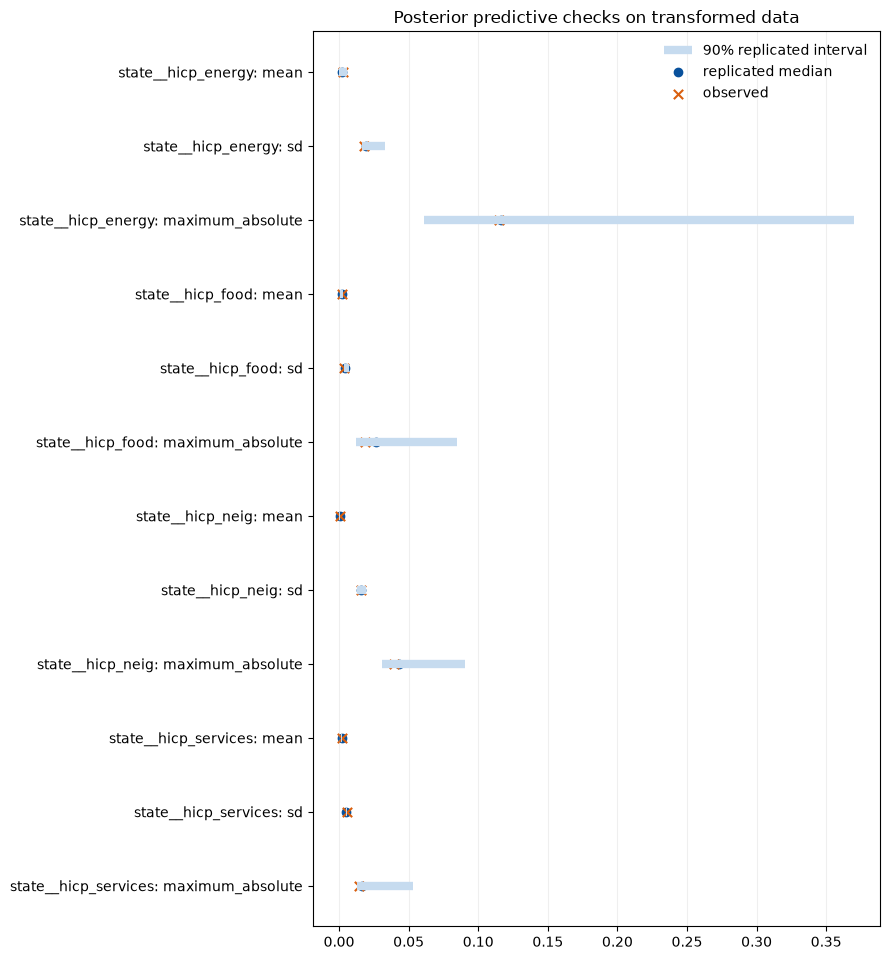

In [27]:
ppc_summary, ppc_draws = posterior_predictive_statistics(
    result_12,
    n_draws=min(300, result_12["n_draws"]),
    seed=321,
)

display(style_numeric_table(ppc_summary, caption="Posterior predictive checks"))

fig = plot_posterior_predictive_check(ppc_summary)
display(fig)
plt.close(fig)

## 18. Structural analysis — recursive IRFs, FEVD and historical decomposition

Recursive Cholesky ordering: Energy → Food → NEIG → Services. Seasonal dummies remain in the deterministic/base part and are not structural shocks.


Structural posterior draws: 1000 / 3000
Identification: recursive
SV reference date: 2026-07-01 00:00:00
Shock ordering: ['Energy', 'Food', 'NEIG', 'Services']


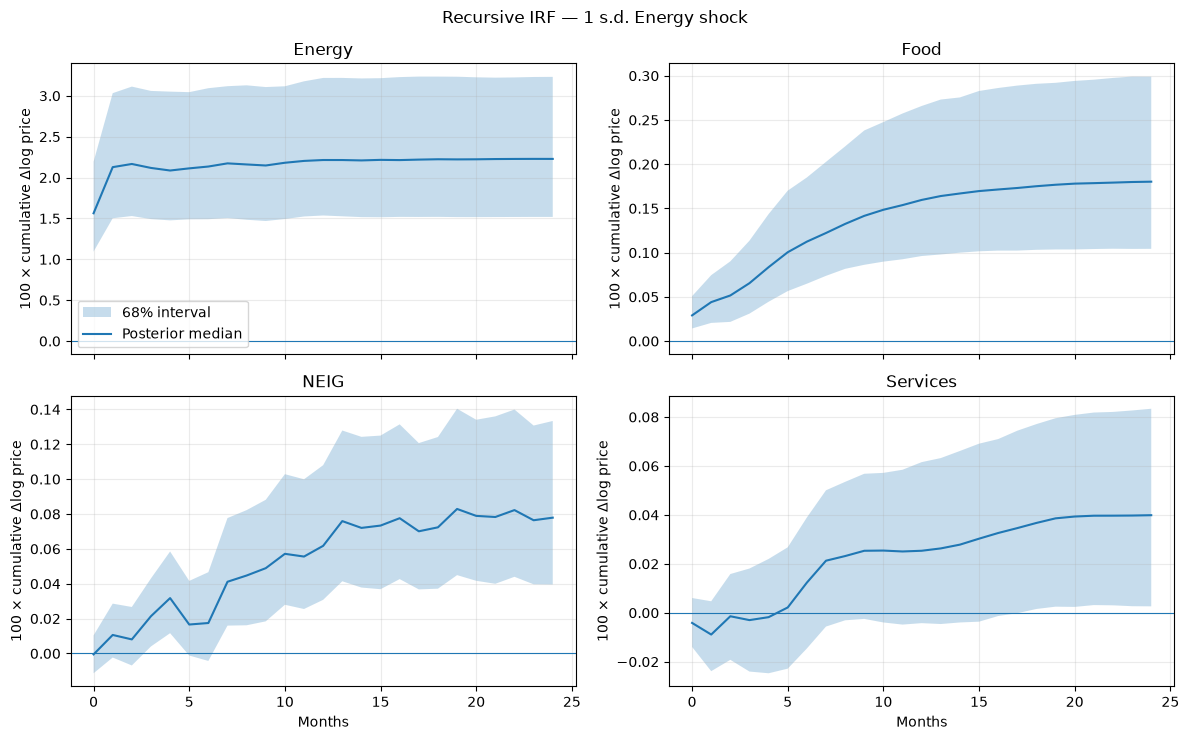

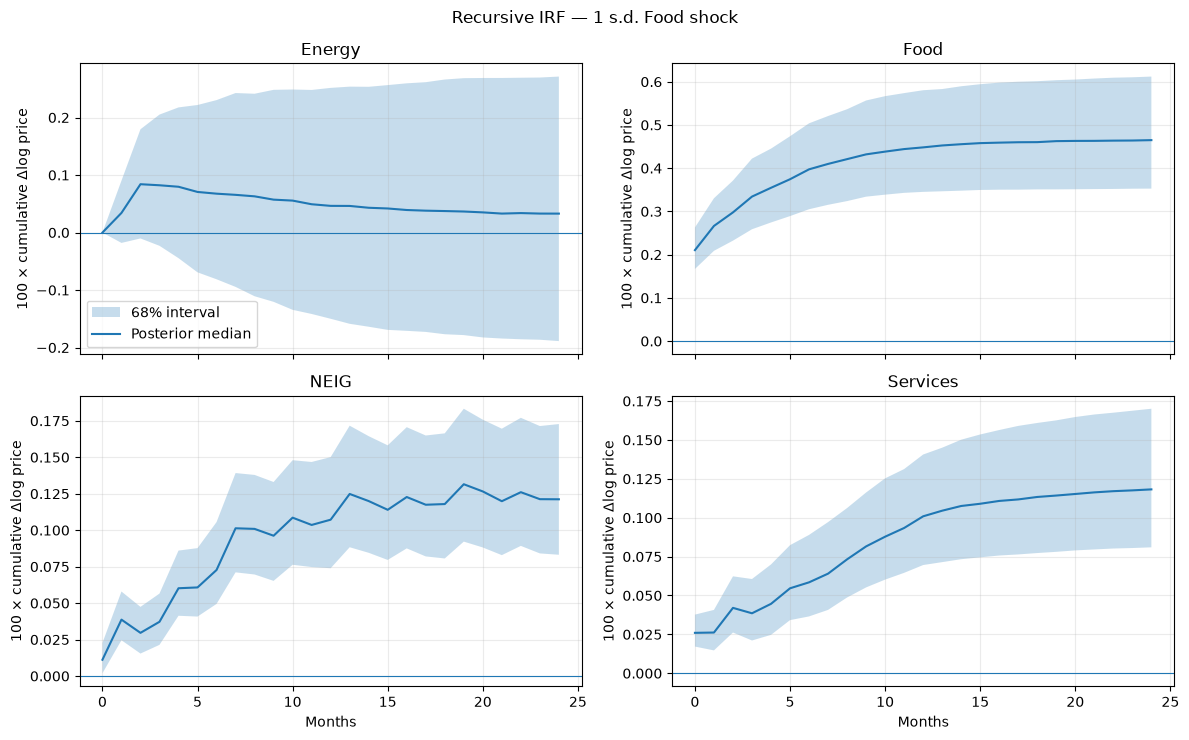

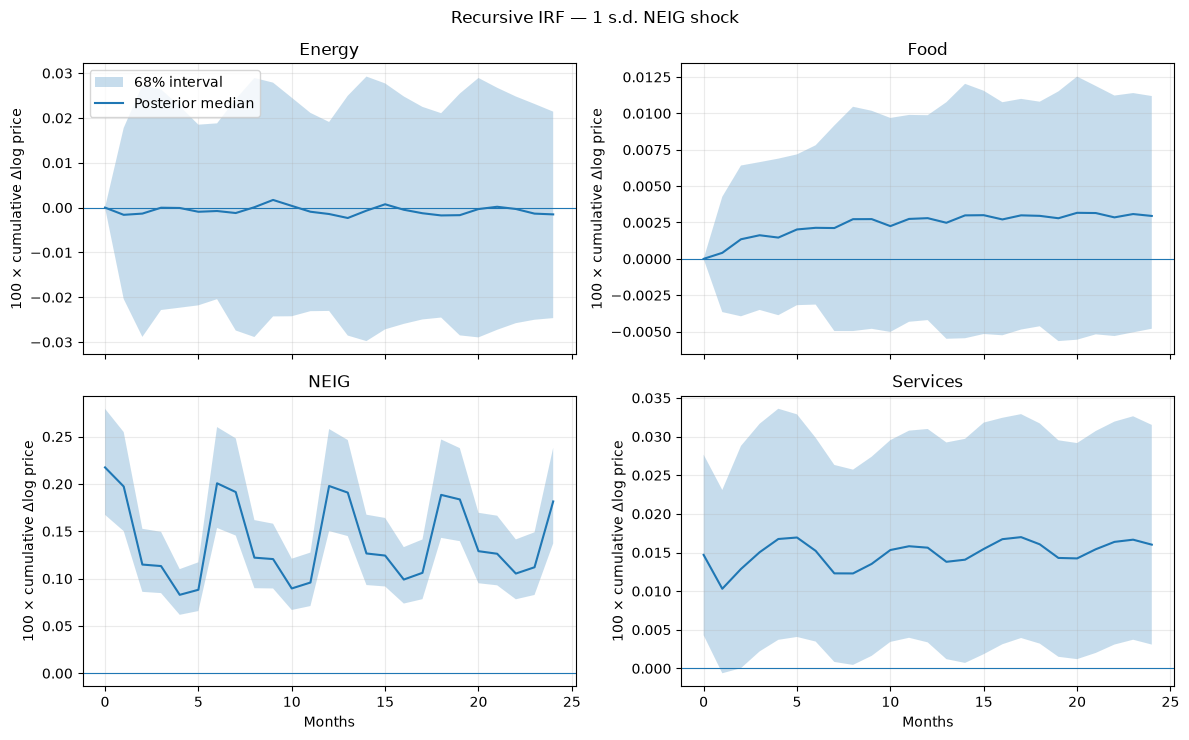

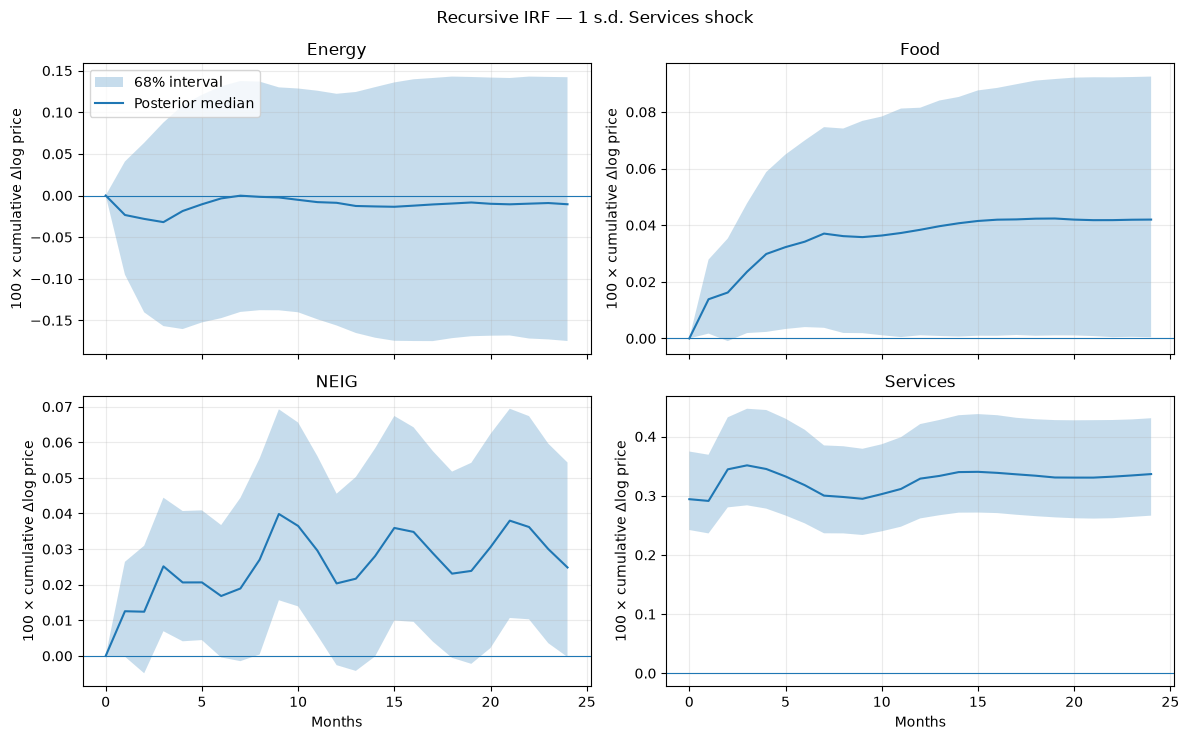

In [28]:
if RUN_STRUCTURAL_ANALYSIS:
    structural_result = posterior_draw_subset(result_12, STRUCTURAL_DRAWS)
    print(
        "Structural posterior draws:", structural_result["n_draws"],
        "/", result_12["n_draws"],
    )

    structural_labels = {
        "state__hicp_energy": "Energy",
        "state__hicp_food": "Food",
        "state__hicp_neig": "NEIG",
        "state__hicp_services": "Services",
    }

    irf = impulse_responses(
        structural_result,
        identification="recursive",
        horizon=STRUCTURAL_HORIZON,
        shock_unit="structural_std",
        shock_size=1.0,
        include_outlier_scale=False,
    )

    print("Identification:", irf["identification"])
    print("SV reference date:", irf["reference_date"])
    print("Shock ordering:", [structural_labels[x] for x in irf["shock_names"]])

    horizons = np.asarray(irf["horizons"], dtype=int)
    cumulative = 100.0 * np.asarray(irf["cumulative_level_irfs"], dtype=float)

    for shock_j, shock_name in enumerate(irf["shock_names"]):
        fig, axes = plt.subplots(2, 2, figsize=(12, 7.5), sharex=True)
        for response_i, (ax, response_name) in enumerate(zip(axes.ravel(), irf["variables"])):
            q16, q50, q84 = np.percentile(
                cumulative[:, :, response_i, shock_j],
                [16, 50, 84],
                axis=0,
            )
            ax.fill_between(horizons, q16, q84, alpha=0.25, label="68% interval")
            ax.plot(horizons, q50, label="Posterior median")
            ax.axhline(0.0, linewidth=0.8)
            ax.set_title(structural_labels[response_name])
            ax.set_ylabel("100 × cumulative Δlog price")
            ax.grid(alpha=0.25)
        axes.ravel()[-1].set_xlabel("Months")
        axes.ravel()[-2].set_xlabel("Months")
        axes.ravel()[0].legend()
        fig.suptitle(
            f"Recursive IRF — 1 s.d. {structural_labels[shock_name]} shock"
        )
        fig.tight_layout()
        display(fig)
        plt.close(fig)
else:
    print("Structural analysis disabled.")


FEVD max adding-up error: 4.440892098500626e-16


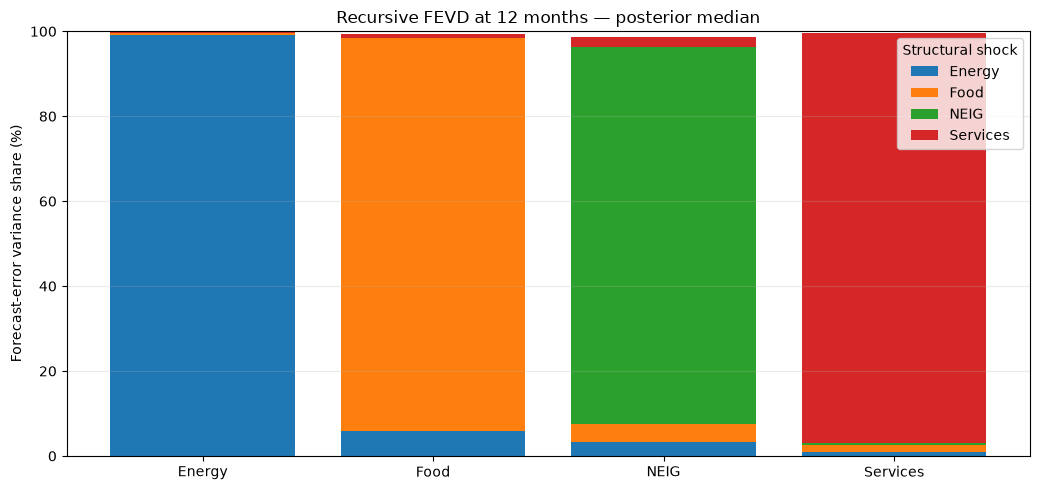

In [29]:
if RUN_STRUCTURAL_ANALYSIS:
    fevd = forecast_error_variance_decomposition(
        structural_result,
        identification="recursive",
        horizon=STRUCTURAL_HORIZON,
        include_outlier_scale=False,
    )
    print("FEVD max adding-up error:", fevd["max_share_sum_error"])

    requested_horizons = [1, 3, 6, 12, 24]
    requested_horizons = [h for h in requested_horizons if h <= STRUCTURAL_HORIZON]
    rows = []
    shares = np.asarray(fevd["fevd_draws"], dtype=float)
    for h in requested_horizons:
        median_share = np.median(shares[:, h - 1, :, :], axis=0)
        for response_i, response_name in enumerate(fevd["variables"]):
            row = {
                "horizon_months": h,
                "response": structural_labels[response_name],
            }
            for shock_j, shock_name in enumerate(fevd["shock_names"]):
                row[f"shock_{structural_labels[shock_name]}"] = 100.0 * median_share[response_i, shock_j]
            rows.append(row)
    fevd_table = pd.DataFrame(rows).set_index(["horizon_months", "response"])
    display(style_numeric_table(fevd_table, caption="Recursive FEVD — posterior median shares (%)"))

    plot_h = 12 if STRUCTURAL_HORIZON >= 12 else STRUCTURAL_HORIZON
    plot_share = np.median(shares[:, plot_h - 1, :, :], axis=0)
    fig, ax = plt.subplots(figsize=(10.5, 5.0))
    x = np.arange(len(fevd["variables"]))
    bottom = np.zeros(len(x))
    for shock_j, shock_name in enumerate(fevd["shock_names"]):
        values = 100.0 * plot_share[:, shock_j]
        ax.bar(x, values, bottom=bottom, label=structural_labels[shock_name])
        bottom += values
    ax.set_xticks(x, [structural_labels[v] for v in fevd["variables"]])
    ax.set_ylabel("Forecast-error variance share (%)")
    ax.set_title(f"Recursive FEVD at {plot_h} months — posterior median")
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="Structural shock")
    fig.tight_layout()
    display(fig)
    plt.close(fig)


HD exact reconstruction max error: 6.245004513516506e-17
HD 12-month log-inflation adding-up max error: 8.526512829121202e-14


c:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


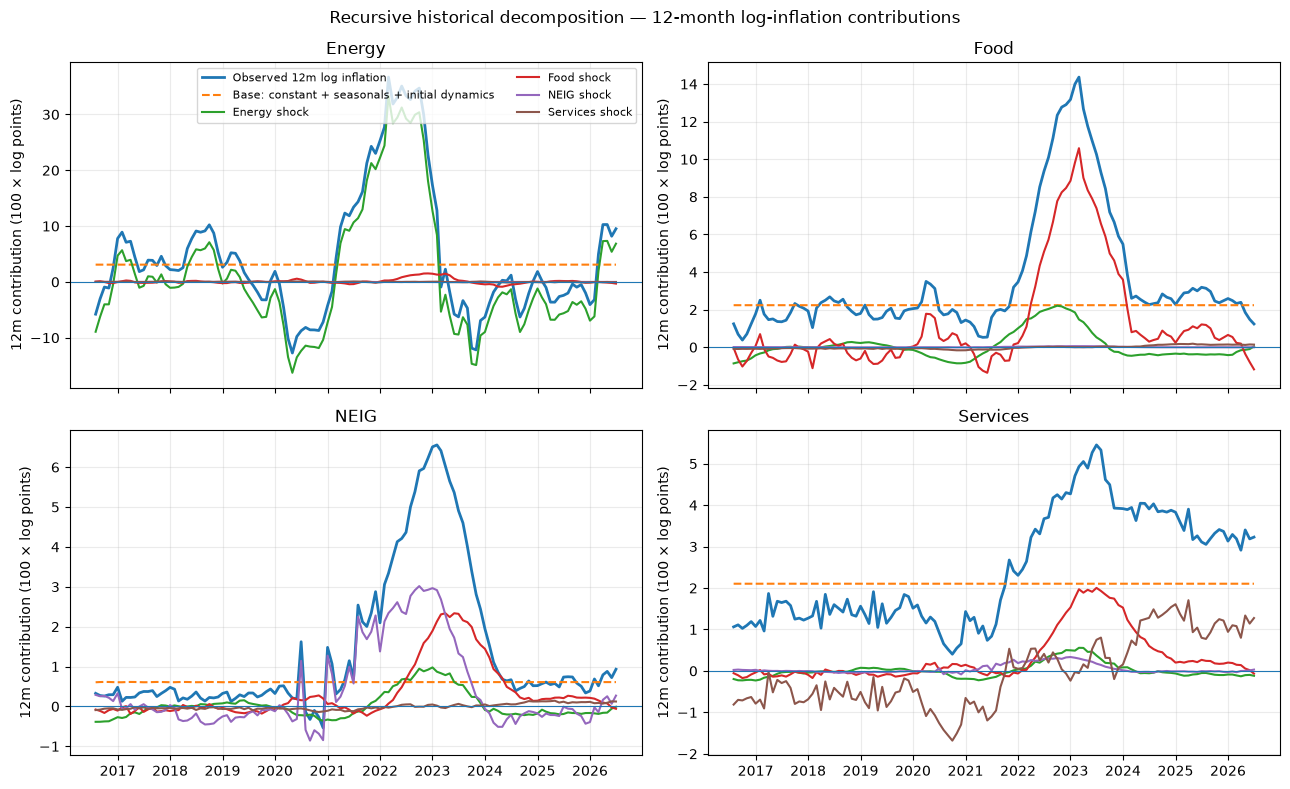

In [30]:
if RUN_STRUCTURAL_ANALYSIS:
    hd = historical_decomposition(
        structural_result,
        identification="recursive",
        split_outlier_amplification=True,
        reconstruction_tol=1e-8,
    )
    print("HD exact reconstruction max error:", hd["max_reconstruction_error"])

    raw_contrib = np.asarray(hd["contributions"], dtype=float)
    n_shocks = len(hd["shock_names"])
    # Aggregate each shock's regular and outlier-amplification pieces back together
    # for a readable four-shock decomposition.
    shock_contrib = np.stack(
        [raw_contrib[..., 2 * j] + raw_contrib[..., 2 * j + 1] for j in range(n_shocks)],
        axis=-1,
    )
    base = np.asarray(hd["base"], dtype=float)
    observed = np.asarray(hd["observed"], dtype=float)
    dates = pd.DatetimeIndex(hd["dates"], name="date")

    def rolling_12_draws(x: np.ndarray) -> np.ndarray:
        # x: draws × time × ... ; exact 12-month sum of monthly log-change contributions.
        out = np.full_like(x, np.nan, dtype=float)
        csum = np.cumsum(x, axis=1)
        out[:, 11:] = csum[:, 11:]
        if x.shape[1] > 12:
            out[:, 12:] -= csum[:, :-12]
        return out

    def rolling_12_observed(x: np.ndarray) -> np.ndarray:
        # x: time × variables
        out = np.full_like(x, np.nan, dtype=float)
        csum = np.cumsum(x, axis=0)
        out[11:] = csum[11:]
        if x.shape[0] > 12:
            out[12:] -= csum[:-12]
        return out

    shock_yoy = 100.0 * rolling_12_draws(shock_contrib)
    base_yoy = 100.0 * rolling_12_draws(base)
    observed_yoy_log = 100.0 * rolling_12_observed(observed)

    # Draw-by-draw adding-up check after 12-month accumulation.
    reconstructed_yoy = base_yoy + np.nansum(shock_yoy, axis=3)
    mask = np.isfinite(reconstructed_yoy) & np.isfinite(observed_yoy_log[None, :, :])
    yoy_add_error = float(
        np.max(np.abs(reconstructed_yoy[mask] - np.broadcast_to(observed_yoy_log, reconstructed_yoy.shape)[mask]))
    )
    print("HD 12-month log-inflation adding-up max error:", yoy_add_error)

    start = max(0, len(dates) - int(HD_LAST_OBS))
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.0), sharex=True)
    for response_i, (ax, response_name) in enumerate(zip(axes.ravel(), hd["variables"])):
        ax.plot(
            dates[start:],
            observed_yoy_log[start:, response_i],
            linewidth=2.0,
            label="Observed 12m log inflation",
        )
        base_median = np.nanmedian(base_yoy[:, :, response_i], axis=0)
        ax.plot(
            dates[start:],
            base_median[start:],
            linestyle="--",
            label="Base: constant + seasonals + initial dynamics",
        )
        for shock_j, shock_name in enumerate(hd["shock_names"]):
            contribution_median = np.nanmedian(
                shock_yoy[:, :, response_i, shock_j],
                axis=0,
            )
            ax.plot(
                dates[start:],
                contribution_median[start:],
                label=f"{structural_labels[shock_name]} shock",
            )
        ax.axhline(0.0, linewidth=0.8)
        ax.set_title(structural_labels[response_name])
        ax.set_ylabel("12m contribution (100 × log points)")
        ax.grid(alpha=0.25)
    axes.ravel()[0].legend(fontsize=8, ncol=2)
    fig.suptitle("Recursive historical decomposition — 12-month log-inflation contributions")
    fig.tight_layout()
    display(fig)
    plt.close(fig)


## 19. Only lag sensitivity: dense BVAR(6) versus dense BVAR(12)

The only lag sensitivity is dense BVAR(6) versus the canonical dense BVAR(12), with the same 11 monthly dummies.


In [31]:
if RUN_BVAR6_SENSITIVITY:
    result_6 = run_headline_joint_bvar(
        native_levels,
        vintage=VINTAGE_USED,
        p=SENSITIVITY_P,
        prior_config=PRIOR_CONFIG,
        sampler_config=SAMPLER_CONFIG,
        code_version="headline-joint-bvar6-seasonal-eurostat-food-sensitivity-v1",
    )

    result_6["headline_joint_context"]["hicp_food_source"] = dict(FOOD_SOURCE_METADATA)
    result_6["metadata"]["hicp_food_source"] = dict(FOOD_SOURCE_METADATA)

    comparison = lag_comparison_table(
        {
            6: result_6,
            12: result_12,
        }
    )
    display(comparison)

    forecast_6 = forecast_headline_joint_bvar(
        result_6,
        native_levels=native_levels,
        H=FORECAST_HORIZON,
        n_draws=min(FORECAST_DRAWS, result_6["n_draws"]),
        simulate_future_outliers=True,
        seed=2026,
    )
    headline_forecast_6 = aggregate_headline_draws(
        forecast_6,
        native_levels=native_levels,
        weights=weights,
        official_total=official_total,
    )

    print("BVAR(6) + monthly dummies — Headline YoY")
    display(headline_forecast_table(headline_forecast_6, kind="yoy"))
else:
    print(
        "BVAR(6) sensitivity disabled. Set RUN_BVAR6_SENSITIVITY=True "
        "only after the canonical seasonal BVAR(12) run is validated."
    )


BVAR(6) sensitivity disabled. Set RUN_BVAR6_SENSITIVITY=True only after the canonical seasonal BVAR(12) run is validated.


## 20. Save canonical seasonal run to the shared registry

In [32]:
if SAVE_RESULTS:
    if save_energy_bvar_result is None:
        raise RuntimeError("energy_bvar_io.save_energy_bvar_result is unavailable.")
    saved = save_energy_bvar_result(result_12, PROJECT_ROOT / "results")
    print("Saved canonical seasonal BVAR(12) run to:", saved["directory"])
else:
    print("SAVE_RESULTS=False — canonical seasonal run is not promoted to the registry.")

SAVE_RESULTS=False — canonical seasonal run is not promoted to the registry.
